In [1]:
# --- Сервісні підключення та команди ---

import pandas as pd
import numpy as np
import os
import re
import openpyxl
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline
from IPython.display import display

# --- Додаткові бібліотеки для моделювання та оптимізації ---
import statsmodels.api as sm
from scipy.optimize import minimize_scalar
import sys

# Встановлює еластичну тему для всіх графіків Matplotlib
sns.set_theme(style="whitegrid")

# --- Визначення датафрейму для запису результатів---
ALL_METHODS_RESULTS = {}

### КРОК 1: Агрегація та консолідація історичних даних

Цей блок коду виконує повний цикл обробки даних для поточного продукту (`{product_name}`), включаючи:
1.  **Визначення та Валідація Шляхів:** Динамічний пошук папок 'Single Pack' та 'Double Pack'.
2.  **Вилучення Констант:** Зчитування фінансових констант (COGS, FBA Fee, Ref Fee Rate) з файлу `Product Cost Info.xlsx`.
3.  **Агрегація:** Збір помісячних даних з усіх CSV-файлів, об'єднання Total та B2B метрик.
4.  **Розрахунок:** Обчислення `Product Costs` та `Net Profit` для обох паків.
5.  **Консолідація:** Створення фінальної зведеної таблиці (`df_comparison_pivot`), яка містить лише спільні місяці для коректного порівняння Single Pack та Double Pack.

**На виході:** Створено DataFrame `df_comparison_pivot`, готовий для розрахунку цільових KPI (c1, c2, c3, DR) на наступному етапі.

In [2]:
# ⚠️ ЗМІННІ ДЛЯ РУЧНОЇ ЗМІНИ
# ----------------------------------------------------------------------------------------------------------------------
product_name = 'Saffron Caps' 
product_dir = '/Users/radyslav/data_analysis/Amazon/prod_perc_dpack/Saffron Caps' # Повний шлях до директорії
# ----------------------------------------------------------------------------------------------------------------------

# Визначаємо кореневу директорію та назву файлу констант
root_dir = os.path.dirname(product_dir)
costs_file_name = 'Product Cost Info.xlsx'
costs_file_path = os.path.join(root_dir, costs_file_name)

# Визначаємо базову назву продукту для фільтрації констант
base_product_name = product_name.replace(' Capsules', '').replace('(Stable Price)', '').strip()


# --- 2. ФУНКЦІЇ ДЛЯ ОБРОБКИ ДАНИХ ---

def get_product_unit_economics(file_path, base_name):
    """Витягує фінансові константи (COGS, FBA Fee, Ref Fee Rate, ASIN)."""
    try:
        df_costs = pd.read_excel(file_path, header=0)
    except FileNotFoundError:
        print(f"Помилка: Файл собівартості не знайдено за шляхом: {file_path}")
        return {}
    
    # Очищення та фільтрація
    df_costs.columns = df_costs.columns.str.strip().str.lower().str.replace(' ', '_')
    df_costs = df_costs.dropna(subset=['short_product_name']).reset_index(drop=True)

    df_product_group = df_costs[df_costs['short_product_name'].str.contains(base_name, case=False, na=False)].copy()

    if df_product_group.empty: return {}

    # Ідентифікація паків за кількістю одиниць
    df_product_group['unit_count'] = df_product_group['short_product_name'].str.extract(r'(\d+)').astype(float)
    df_product_group = df_product_group.dropna(subset=['unit_count'])
    if len(df_product_group) < 2: return {}

    idx_dp = df_product_group['unit_count'].idxmax()
    idx_sp = df_product_group['unit_count'].idxmin()

    results_raw = {'Single Pack': df_product_group.loc[idx_sp], 'Double Pack': df_product_group.loc[idx_dp]}
    unit_economics_final = {}
    
    # Очищення та перетворення констант
    for pack_type, data in results_raw.items():
        costs = {}
        for col in ['cogs', 'fba_fee']:
            raw_value = str(data.get(col, 0))
            cleaned_value = raw_value.strip().replace('$', '').replace(',', '')
            costs[col] = pd.to_numeric(cleaned_value, errors='coerce') 

        raw_ref_fee = str(data.get('ref_fee', '0%'))
        if '%' in raw_ref_fee:
              ref_fee_rate = pd.to_numeric(raw_ref_fee.strip().replace('%', ''), errors='coerce') / 100
        else:
              numeric_val = pd.to_numeric(raw_ref_fee, errors='coerce')
              ref_fee_rate = numeric_val / 100 if numeric_val > 1 else numeric_val

        costs['ref_fee_rate'] = ref_fee_rate
        costs['asin'] = data['asin'] 
        unit_economics_final[pack_type] = costs

    return unit_economics_final

def process_single_csv(file_path, file_name, current_asin):
    """Обробляє один CSV-файл, об'єднує Total/B2B метрики та витягує дату."""
    try:
        df = pd.read_csv(file_path, header=0, encoding='utf-8')
    except Exception as e:
        print(f"Помилка зчитування файлу {file_name}: {e}")
        return None, 0

    cols_mapping = {
        'Sessions': ['Sessions - Total', 'Sessions - Total - B2B'],
        'Units Ordered': ['Units Ordered', 'Units Ordered - B2B'],
        'Ordered Product Sales': ['Ordered Product Sales', 'Ordered Product Sales - B2B']
    }
    
    monthly_data = {'ASIN': current_asin}
    
    for new_col, raw_cols in cols_mapping.items():
        temp_df = df[raw_cols].copy()
        for col in raw_cols:
            if temp_df[col].dtype == object: 
                temp_df[col] = temp_df[col].astype(str).str.replace(r'[\$,\s]', '', regex=True)
            temp_df[col] = pd.to_numeric(temp_df[col], errors='coerce')
        
        total_sum = temp_df.sum().sum() 
        monthly_data[new_col] = total_sum

    date_match = re.search(r'([A-Za-z]+_\d{4})', file_name)
    monthly_data['Month_Year'] = date_match.group(1) if date_match else "Unknown_Date"

    return pd.DataFrame([monthly_data]), len(df)

def create_sort_key(month_year_str):
    """Створює ключ сортування datetime для Month_Year."""
    if '_' in month_year_str:
        date_str = month_year_str.replace('_', ' ')
        try:
            return pd.to_datetime(date_str, format='%B %Y') 
        except ValueError:
            return pd.NaT 
    return pd.NaT


# --- 3. ДИНАМІЧНИЙ ПОШУК ПАКІВ ТА ПІДГОТОВКА ---

if not os.path.isdir(product_dir):
    raise FileNotFoundError(f"Помилка: Директорія продукту '{product_dir}' не знайдена.")

all_items = os.listdir(product_dir)
single_pack_folder = next((item for item in all_items if "single pack" in item.lower() and os.path.isdir(os.path.join(product_dir, item))), None)
double_pack_folder = next((item for item in all_items if "double pack" in item.lower() and os.path.isdir(os.path.join(product_dir, item))), None)

if not single_pack_folder or not double_pack_folder:
      raise FileNotFoundError("Помилка: Не знайдено підпапок 'Single Pack' або 'Double Pack'.")

single_pack_dir = os.path.join(product_dir, single_pack_folder)
double_pack_dir = os.path.join(product_dir, double_pack_folder)

pack_dirs = {'Single Pack': single_pack_dir, 'Double Pack': double_pack_dir}

def count_csv_files(directory):
    if not os.path.isdir(directory): return 0, []
    csv_files = [f for f in os.listdir(directory) if f.endswith('.csv')]
    return len(csv_files), csv_files 
_, single_files_list = count_csv_files(single_pack_dir)
_, double_files_list = count_csv_files(double_pack_dir)
pack_files = {'Single Pack': single_files_list, 'Double Pack': double_files_list}

unit_economics = get_product_unit_economics(costs_file_path, base_product_name)

# Змінні для Сервісної Інформації
total_rows_sp = 0
total_rows_dp = 0


# --- 4. АГРЕГАЦІЯ, KPI ТА ФІНАЛІЗАЦІЯ: SINGLE PACK ---
pack_type = 'Single Pack'
asin_sp = unit_economics.get(pack_type, {}).get('asin', 'ASIN_NOT_FOUND')

single_pack_data = []
for file_name in pack_files[pack_type]:
    df_month, rows_count = process_single_csv(os.path.join(pack_dirs[pack_type], file_name), file_name, asin_sp)
    if df_month is not None: 
        single_pack_data.append(df_month)
        total_rows_sp += rows_count # Додавання оброблених рядків

df_single_raw = pd.concat(single_pack_data, ignore_index=True)
df_single_raw['Date_Sort'] = df_single_raw['Month_Year'].apply(create_sort_key)
df_single_kpi = df_single_raw.sort_values(by='Date_Sort').reset_index(drop=True)

# Розрахунок Фінансових Метрик (Net Profit)
if unit_economics and pack_type in unit_economics:
    cogs = unit_economics[pack_type]['cogs']
    fba_fee = unit_economics[pack_type]['fba_fee']
    ref_fee_rate = unit_economics[pack_type]['ref_fee_rate']
    
    df_single_kpi['Product Costs'] = (df_single_kpi['Units Ordered'] * (cogs + fba_fee)) + \
                                     (df_single_kpi['Ordered Product Sales'] * ref_fee_rate)
    
    df_single_kpi['Net Profit'] = df_single_kpi['Ordered Product Sales'] - df_single_kpi['Product Costs']
else:
    cogs = np.nan 
    fba_fee = np.nan 
    ref_fee_rate = np.nan 
    df_single_kpi['Product Costs'] = np.nan
    df_single_kpi['Net Profit'] = np.nan

# Розрахунок Actual Price
df_single_kpi['Actual Price'] = df_single_kpi['Ordered Product Sales'] / df_single_kpi['Units Ordered']
    
# Змінні для Сервісної Інформації (Single Pack)
sp_consts_info = f"COGS: {cogs:.2f}, FBA Fee: {fba_fee:.2f}, Ref Rate: {ref_fee_rate:.2%}"

# Створення Фінального Датасету для Single Pack
final_cols_sp = ['Month_Year', 'Sessions', 'Units Ordered', 'Ordered Product Sales', 'Product Costs', 'Net Profit', 'Actual Price', 'Date_Sort']
df_single_final = df_single_kpi[final_cols_sp].copy()
months_single_all = set(df_single_final['Month_Year'].unique()) # Всі місяці SP


# --- 5. АГРЕГАЦІЯ, KPI ТА ФІНАЛІЗАЦІЯ: DOUBLE PACK ---
pack_type = 'Double Pack'
asin_dp = unit_economics.get(pack_type, {}).get('asin', 'ASIN_NOT_FOUND')

double_pack_data = []
for file_name in pack_files[pack_type]:
    df_month, rows_count = process_single_csv(os.path.join(pack_dirs[pack_type], file_name), file_name, asin_dp)
    if df_month is not None: 
        double_pack_data.append(df_month)
        total_rows_dp += rows_count # Додавання оброблених рядків

df_double_raw = pd.concat(double_pack_data, ignore_index=True)
df_double_raw['Date_Sort'] = df_double_raw['Month_Year'].apply(create_sort_key)
df_double_kpi = df_double_raw.sort_values(by='Date_Sort').reset_index(drop=True)

# Розрахунок Фінансових Метрик (Net Profit)
if unit_economics and pack_type in unit_economics:
    cogs = unit_economics[pack_type]['cogs']
    fba_fee = unit_economics[pack_type]['fba_fee']
    ref_fee_rate = unit_economics[pack_type]['ref_fee_rate']
    
    df_double_kpi['Product Costs'] = (df_double_kpi['Units Ordered'] * (cogs + fba_fee)) + \
                                     (df_double_kpi['Ordered Product Sales'] * ref_fee_rate)
    
    df_double_kpi['Net Profit'] = df_double_kpi['Ordered Product Sales'] - df_double_kpi['Product Costs']
else:
    cogs = np.nan 
    fba_fee = np.nan 
    ref_fee_rate = np.nan 
    df_double_kpi['Product Costs'] = np.nan
    df_double_kpi['Net Profit'] = np.nan

# Розрахунок Actual Price
df_double_kpi['Actual Price'] = df_double_kpi['Ordered Product Sales'] / df_double_kpi['Units Ordered']

# Змінні для Сервісної Інформації (Double Pack)
dp_consts_info = f"COGS: {cogs:.2f}, FBA Fee: {fba_fee:.2f}, Ref Rate: {ref_fee_rate:.2%}"

# Створення Фінального Датасету для Double Pack
df_double_final = df_double_kpi[final_cols_sp].copy()
months_double_all = set(df_double_final['Month_Year'].unique()) # Всі місяці DP


# --- 6. СЕРВІСНА ІНФОРМАЦІЯ ТА ФІНАЛЬНИЙ ВИВІД ---

# 6.1: КОНСОЛІДАЦІЯ ТА ПІДГОТОВКА ДО ВИВОДУ
months_single = set(df_single_final['Month_Year'].unique())
months_double = set(df_double_final['Month_Year'].unique())
common_months = sorted(list(months_single.intersection(months_double)), key=create_sort_key)
pack_type_order = ['Single Pack', 'Double Pack']

# Визначення не спільних місяців
non_common_months = (months_single_all.difference(common_months)).union(months_double_all.difference(common_months))
non_common_months_list = sorted(list(non_common_months), key=create_sort_key)
non_common_months_output = ', '.join(non_common_months_list) if non_common_months_list else "Всі місяці співпали"


# 6.2: ДРУК СЕРВІСНОЇ ІНФОРМАЦІЇ
print(f"\n--- СЕРВІСНА ІНФОРМАЦІЯ ДЛЯ ЗВІРКИ ---")
print(f"Аналізований Продукт: {product_name}")
print(f"Назва продукту: {base_product_name}")
print(f"Коренева директорія продукту: {root_dir}")
print("-" * 50)

print(f"Шлях Single Pack: {single_pack_dir}")
print(f"ASIN Single Pack: {asin_sp}")
print(f"Кількість файлів Single Pack: {len(pack_files['Single Pack'])}")
print(f"Кількість рядків, оброблених по всім CSV, Single Pack: {total_rows_sp}")
print(f"Показники констант юніт економіки Single Pack: {sp_consts_info}")
print("-" * 50)

print(f"Шлях Double Pack: {double_pack_dir}")
print(f"ASIN Double Pack: {asin_dp}")
print(f"Кількість файлів Double Pack: {len(pack_files['Double Pack'])}")
print(f"Кількість рядків, оброблених по всім CSV, Double Pack: {total_rows_dp}")
print(f"Показники констант юніт економіки Double Pack: {dp_consts_info}")
print("-" * 50)

print(f"Місяці, що не є спільними для Single Pack та Double Pack: {non_common_months_output}")
print("-" * 50)


# 6.3: СТВОРЕННЯ ЄДИНОГО ПОРІВНЯЛЬНОГО ДАТАСЕТУ
if not common_months:
    print("❌ Помилка: Спільних місяців для порівняння не знайдено. Фінальна таблиця порожня.")
    df_comparison_pivot = pd.DataFrame() 
else:
    # Об'єднання та Фільтрація
    df_single_combined = df_single_final.assign(Pack_Type='Single Pack')
    df_double_combined = df_double_final.assign(Pack_Type='Double Pack')
    df_combined = pd.concat([df_single_combined, df_double_combined], ignore_index=True)
    df_combined_filtered = df_combined[df_combined['Month_Year'].isin(common_months)].copy()

    # Трансформація: Melt та Pivot
    df_combined_filtered['Pack_Type'] = pd.Categorical(df_combined_filtered['Pack_Type'], categories=pack_type_order, ordered=True)
    comparison_values = ['Sessions', 'Units Ordered', 'Ordered Product Sales', 'Product Costs', 'Net Profit', 'Actual Price']

    df_for_pivot = df_combined_filtered[['Month_Year', 'Pack_Type'] + comparison_values].melt(
        id_vars=['Month_Year', 'Pack_Type'],
        value_vars=comparison_values,
        var_name='Metric',
        value_name='Value'
    )
    
    # Сортування перед Pivot
    df_for_pivot['Date_Sort'] = df_for_pivot['Month_Year'].apply(create_sort_key)
    df_for_pivot = df_for_pivot.sort_values(by=['Date_Sort', 'Pack_Type']).drop(columns=['Date_Sort'])
    
    # Фінальний Pivot
    df_comparison_pivot = df_for_pivot.pivot_table(
        index='Metric', 
        columns=['Month_Year', 'Pack_Type'], 
        values='Value',
        aggfunc='sum',
        observed=False 
    )

    # Сортування Колонок та Рядків
    sorted_cols = []
    for month in common_months:
        for pack in pack_type_order:
            sorted_cols.append((month, pack))

    df_comparison_pivot = df_comparison_pivot[sorted_cols]
    df_comparison_pivot.columns.names = ['Month_Year', 'Pack_Type']
    
    # Сортування рядків з додаванням 'Actual Price'
    row_order_final = ['Sessions', 'Units Ordered', 'Ordered Product Sales', 'Product Costs', 'Net Profit', 'Actual Price']
    df_comparison_pivot = df_comparison_pivot.reindex(row_order_final)
    
    
    # 6.4: Виведення Результату
    print("\n--- ЗВЕДЕНА ТАБЛИЦЯ: Історичні Показники SP vs DP ---")
    
    # Форматування виводу: {:.2f} (float64 без роздільників розрядів)
    df_comparison_pivot_styled = df_comparison_pivot.style.format('{:.2f}')
    display(df_comparison_pivot_styled)


--- СЕРВІСНА ІНФОРМАЦІЯ ДЛЯ ЗВІРКИ ---
Аналізований Продукт: Saffron Caps
Назва продукту: Saffron Caps
Коренева директорія продукту: /Users/radyslav/data_analysis/Amazon/prod_perc_dpack
--------------------------------------------------
Шлях Single Pack: /Users/radyslav/data_analysis/Amazon/prod_perc_dpack/Saffron Caps/Saffron Caps 90 pcs (Single Pack)
ASIN Single Pack: B0CYTBTCF6
Кількість файлів Single Pack: 5
Кількість рядків, оброблених по всім CSV, Single Pack: 5
Показники констант юніт економіки Single Pack: COGS: 2.68, FBA Fee: 3.68, Ref Rate: 15.00%
--------------------------------------------------
Шлях Double Pack: /Users/radyslav/data_analysis/Amazon/prod_perc_dpack/Saffron Caps/Saffron Caps 180 pcs (Double Pack)
ASIN Double Pack: B0DSJD6PWW
Кількість файлів Double Pack: 5
Кількість рядків, оброблених по всім CSV, Double Pack: 5
Показники констант юніт економіки Double Pack: COGS: 4.40, FBA Fee: 3.90, Ref Rate: 15.00%
--------------------------------------------------
Місяц

### КРОК 2: Розрахунок та аналіз 6 ключових KPI (Маркетинг + Фінанси)

Цей крок розраховує повний набір із шести KPI, необхідних для регресійного аналізу, що зв'язує **Знижку Double Pack (DP_DR)** з ключовими бізнес-показниками.

**Розраховані KPI:**
1.  **DP_DR** (Discount Rate): Фактична знижка DP.
2.  **DP_CR** (Conversion Rate): Конверсія продажів DP (Units DP / Sessions DP).
3.  **DP_TAR** (Traffic Attraction Rate): Коефіцієнт залучення трафіку DP (Sessions DP / Sessions SP).
4.  **DP_CSC** (Cross-Sell Conversion): Крос-продажна конверсія (Units DP / Sessions SP).
5.  **DP_NPS** (Net Profit Share): Частка чистого прибутку DP від загального прибутку (DP / (SP + DP)).
6.  **DP_NPPS** (Net Profit Per Session DP): Чистий прибуток на одну сесію DP.
7.  **DP_CSPPS** (Cross-Sell Profit Per Session SP): Чистий прибуток DP на одну сесію SP.

**Вивід:**
* **Таблиця кореляції:** Зв'язок DP_DR з усіма шістьма KPI.
* **Зведена таблиця:** Помісячні значення всіх 6 KPI.
* **Графік:** Візуалізація динаміки всіх 6 KPI на фактичних значеннях (з подвійними осями для масштабу).


--- СЕРВІСНА ІНФОРМАЦІЯ: Коефіцієнти Кореляції (DP_DR vs KPI) ---
Коефіцієнт DP_DR та DP_CR кореляції: 0.6205
Коефіцієнт DP_DR та DP_TAR кореляції: 0.7609
Коефіцієнт DP_DR та DP_CSC кореляції: 0.7138
Коефіцієнт DP_DR та DP_NPS кореляції: 0.6858
Коефіцієнт DP_DR та DP_NPPS кореляції: 0.6182
Коефіцієнт DP_DR та DP_CSPPS кореляції: 0.7133
--------------------------------------------------

--- ЗВЕДЕНА ТАБЛИЦЯ: Помісячні KPI ---


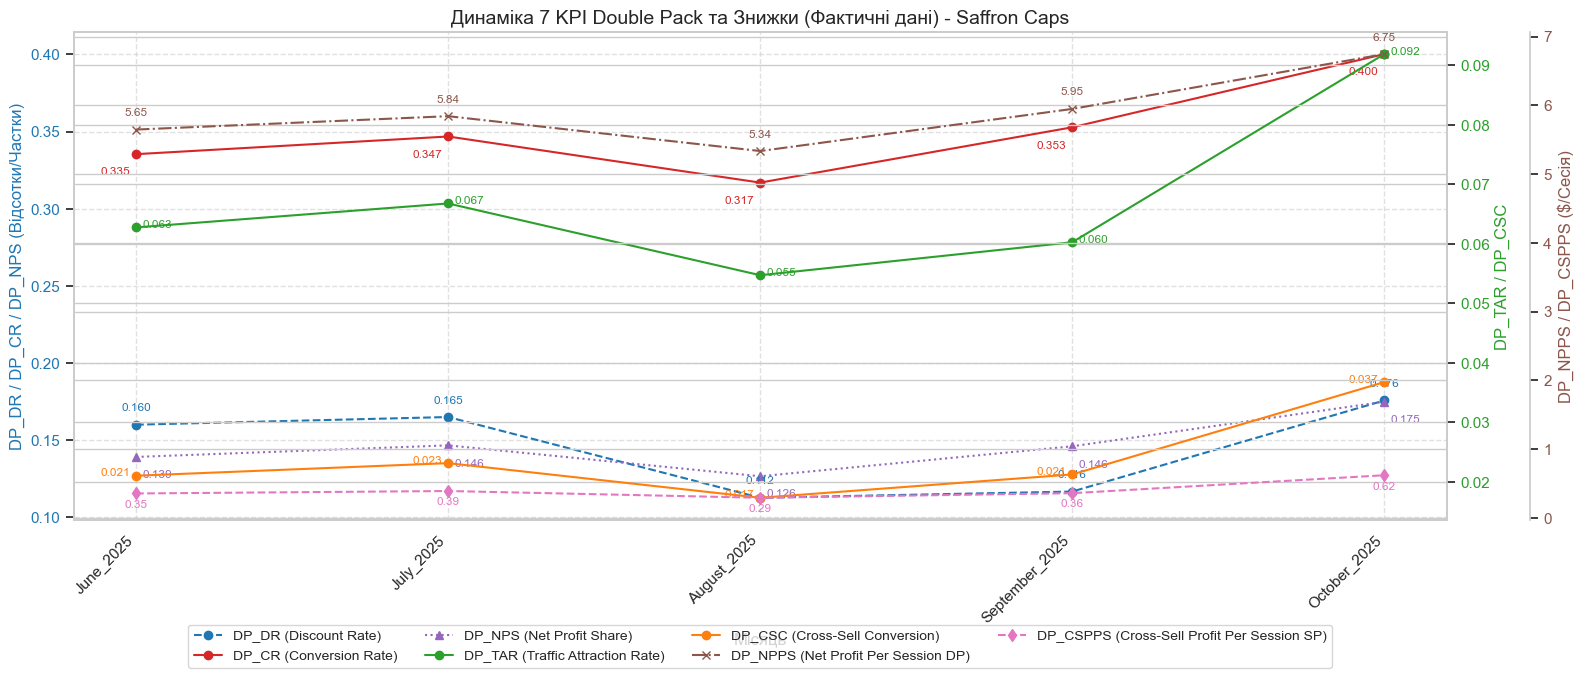


--- ЗВЕДЕНА ТАБЛИЦЯ: Помісячні KPI ---


Month_Year,June_2025,July_2025,August_2025,September_2025,October_2025
Metric,,,,,
DP_DR,0.1598,0.1648,0.1124,0.1164,0.1755
DP_CR,0.3353,0.3468,0.3169,0.3528,0.4002
DP_TAR,0.0628,0.0668,0.0547,0.0603,0.0919
DP_CSC,0.0210,0.0232,0.0173,0.0213,0.0368
DP_NPS,0.1389,0.1464,0.1263,0.1458,0.1747
DP_NPPS,5.6476,5.8422,5.3354,5.9477,6.7451
DP_CSPPS,0.3545,0.3902,0.2920,0.3585,0.6197


In [3]:
# --- Розрахунок 6 KPI, Кореляція та Графік ---

# Примітка: Вважається, що змінні df_comparison_pivot та product_name доступні

# 1. Підготовка даних (використовуємо дані з Net Profit для фінансових KPI)
df_kpi = df_comparison_pivot.copy()

# ВИПРАВЛЕНО! ДОДАНО 'Product Costs'
metrics_for_calc = ['Sessions', 'Units Ordered', 'Actual Price', 'Net Profit', 'Product Costs'] 

# 2. Створення DataFrame для розрахунків KPI (Місяці як індекс)
df_calc = df_kpi.loc[metrics_for_calc].T.copy()
df_calc.index.names = ['Month_Year', 'Pack_Type']

# Розділяємо дані по паках для легшого доступу
df_sp = df_calc[df_calc.index.get_level_values('Pack_Type') == 'Single Pack'].droplevel('Pack_Type')
df_dp = df_calc[df_calc.index.get_level_values('Pack_Type') == 'Double Pack'].droplevel('Pack_Type')

# Об'єднуємо обидва DF за місяцями
df_raw = df_sp.join(df_dp, lsuffix='_SP', rsuffix='_DP')


# 3. РОЗРАХУНОК УСІХ 6 KPI (помісячно)

# МАРКЕТИНГОВІ KPI
df_raw['DP_DR'] = 1 - (df_raw['Actual Price_DP'] / (df_raw['Actual Price_SP'] * 2))
df_raw['DP_CR'] = df_raw['Units Ordered_DP'] / df_raw['Sessions_DP']
df_raw['DP_TAR'] = df_raw['Sessions_DP'] / df_raw['Sessions_SP']
df_raw['DP_CSC'] = df_raw['Units Ordered_DP'] / df_raw['Sessions_SP']

# ФІНАНСОВІ KPI
# DP_NPS (Net Profit Share)
df_raw['DP_NPS'] = df_raw['Net Profit_DP'] / (df_raw['Net Profit_SP'] + df_raw['Net Profit_DP'])
# DP_NPPS (Net Profit Per Session DP)
df_raw['DP_NPPS'] = df_raw['Net Profit_DP'] / df_raw['Sessions_DP']
# DP_CSPPS (Cross-Sell Profit Per Session SP)
df_raw['DP_CSPPS'] = df_raw['Net Profit_DP'] / df_raw['Sessions_SP']


# 4. Створення фінального DataFrame з KPI
kpi_cols = ['DP_DR', 'DP_CR', 'DP_TAR', 'DP_CSC', 'DP_NPS', 'DP_NPPS', 'DP_CSPPS']
df_kpi_calculated = df_raw[kpi_cols].copy()

# Транспонуємо для формату: Метрики (рядки) x Місяці (колонки)
df_kpi_pivot = df_kpi_calculated.T

# Забезпечуємо правильний порядок рядків
kpi_order = kpi_cols
df_kpi_pivot = df_kpi_pivot.reindex(kpi_order)


# --- 5. РОЗРАХУНОК ТА ВИВЕДЕННЯ КОЕФІЦІЄНТІВ КОРЕЛЯЦІЇ ---

print("\n--- СЕРВІСНА ІНФОРМАЦІЯ: Коефіцієнти Кореляції (DP_DR vs KPI) ---")

correlation_results = {}
for kpi in kpi_cols[1:]: # Ітеруємо по всіх KPI, крім DP_DR
    corr = df_kpi_calculated[kpi].corr(df_kpi_calculated['DP_DR'])
    correlation_results[kpi] = corr
    print(f"Коефіцієнт DP_DR та {kpi} кореляції: {corr:.4f}")

print("-" * 50)


# --- 6. ВИВЕДЕННЯ ЗВЕДЕНОЇ ТАБЛИЦІ KPI ---

print("\n--- ЗВЕДЕНА ТАБЛИЦЯ: Помісячні KPI ---")
# df_kpi_styled = df_kpi_pivot.style.format('{:.4f}')
# display(df_kpi_styled) # Видалено display для компактності

# --- 7. БУДУВАННЯ СПІЛЬНОГО ЛІНІЙНОГО ГРАФІКА (З ПОКРАЩЕННЯМИ) ---

# Використовуємо df_kpi_calculated (фактичні значення, Місяці - індекс)
df_plot = df_kpi_calculated.copy()

# Налаштування графіка
fig, ax1 = plt.subplots(figsize=(16, 8))

# Визначення кольорів
colors = {'DP_DR': 'tab:blue', 'DP_CR': 'tab:red', 'DP_TAR': 'tab:green', 'DP_CSC': 'tab:orange', 
          'DP_NPS': 'tab:purple', 'DP_NPPS': 'tab:brown', 'DP_CSPPS': 'tab:pink'}
line_styles = {'DP_DR': '--', 'DP_CR': '-', 'DP_TAR': '-', 'DP_CSC': '-', 
               'DP_NPS': ':', 'DP_NPPS': '-.', 'DP_CSPPS': '--'}
markers = 'o'
font_size_labels = 8.5
label_offset = 15 # Відступ для підписів

# --- ЛІВА ВІСЬ (AX1): DP_DR, DP_CR, DP_NPS (Відсотки/Частки) ---
ax1.set_xlabel('Місяць', fontsize=12)
ax1.set_ylabel('DP_DR / DP_CR / DP_NPS (Відсотки/Частки)', color=colors['DP_DR'], fontsize=12)
ax1.tick_params(axis='y', labelcolor=colors['DP_DR'])
ax1.grid(True, linestyle='--', alpha=0.6)

# Побудова DP_DR (пунктирна лінія)
p1 = ax1.plot(df_plot.index, df_plot['DP_DR'], label='DP_DR (Discount Rate)', color=colors['DP_DR'], 
              linestyle=line_styles['DP_DR'], marker=markers)

# Побудова DP_CR (суцільна лінія)
p2 = ax1.plot(df_plot.index, df_plot['DP_CR'], label='DP_CR (Conversion Rate)', color=colors['DP_CR'], 
              linestyle=line_styles['DP_CR'], marker=markers)

# Побудова DP_NPS (пунктир-крапка)
p3 = ax1.plot(df_plot.index, df_plot['DP_NPS'], label='DP_NPS (Net Profit Share)', color=colors['DP_NPS'], 
              linestyle=line_styles['DP_NPS'], marker='^') # Змінений маркер для розрізнення

# Додавання підписів DP_DR, DP_CR, DP_NPS
for i, month in enumerate(df_plot.index):
    # DP_DR
    ax1.annotate(f"{df_plot['DP_DR'].iloc[i]:.3f}", 
                  (month, df_plot['DP_DR'].iloc[i]), 
                  textcoords="offset points", xytext=(0,10), ha='center', 
                  fontsize=font_size_labels, color=colors['DP_DR'])
    # DP_CR
    ax1.annotate(f"{df_plot['DP_CR'].iloc[i]:.3f}", 
                  (month, df_plot['DP_CR'].iloc[i]), 
                  textcoords="offset points", xytext=(-label_offset, -label_offset), ha='center', 
                  fontsize=font_size_labels, color=colors['DP_CR'])
    # DP_NPS
    ax1.annotate(f"{df_plot['DP_NPS'].iloc[i]:.3f}", 
                  (month, df_plot['DP_NPS'].iloc[i]), 
                  textcoords="offset points", xytext=(label_offset, -label_offset), ha='center', 
                  fontsize=font_size_labels, color=colors['DP_NPS'])


# --- ПРАВА ВІСЬ (AX2): DP_TAR та DP_CSC (Співвідношення/Коефіцієнти) ---
ax2 = ax1.twinx()
ax2.set_ylabel('DP_TAR / DP_CSC', color=colors['DP_TAR'], fontsize=12)
ax2.tick_params(axis='y', labelcolor=colors['DP_TAR'])

# Побудова DP_TAR
p4 = ax2.plot(df_plot.index, df_plot['DP_TAR'], label='DP_TAR (Traffic Attraction Rate)', color=colors['DP_TAR'], 
              linestyle=line_styles['DP_TAR'], marker=markers)

# Побудова DP_CSC
p5 = ax2.plot(df_plot.index, df_plot['DP_CSC'], label='DP_CSC (Cross-Sell Conversion)', color=colors['DP_CSC'], 
              linestyle=line_styles['DP_CSC'], marker=markers)

# Додавання підписів DP_TAR та DP_CSC
for i, month in enumerate(df_plot.index):
    # DP_TAR
    ax2.annotate(f"{df_plot['DP_TAR'].iloc[i]:.3f}", 
                  (month, df_plot['DP_TAR'].iloc[i]), 
                  textcoords="offset points", xytext=(label_offset, 0), ha='center', 
                  fontsize=font_size_labels, color=colors['DP_TAR'])
    # DP_CSC
    ax2.annotate(f"{df_plot['DP_CSC'].iloc[i]:.3f}", 
                  (month, df_plot['DP_CSC'].iloc[i]), 
                  textcoords="offset points", xytext=(-label_offset, 0), ha='center', 
                  fontsize=font_size_labels, color=colors['DP_CSC'])

# --- Додаткова ПРАВА ВІСЬ (AX3): DP_NPPS та DP_CSPPS (Гроші/$ на сесію) ---
ax3 = ax1.twinx()
# Сміщення осі ax3, щоб вона не перекривала ax2
ax3.spines['right'].set_position(('outward', 60)) 
ax3.set_ylabel('DP_NPPS / DP_CSPPS ($/Сесія)', color=colors['DP_NPPS'], fontsize=12)
ax3.tick_params(axis='y', labelcolor=colors['DP_NPPS'])

# Побудова DP_NPPS
p6 = ax3.plot(df_plot.index, df_plot['DP_NPPS'], label='DP_NPPS (Net Profit Per Session DP)', color=colors['DP_NPPS'], 
              linestyle=line_styles['DP_NPPS'], marker='x')

# Побудова DP_CSPPS
p7 = ax3.plot(df_plot.index, df_plot['DP_CSPPS'], label='DP_CSPPS (Cross-Sell Profit Per Session SP)', color=colors['DP_CSPPS'], 
              linestyle=line_styles['DP_CSPPS'], marker='d')

# Додавання підписів DP_NPPS та DP_CSPPS
for i, month in enumerate(df_plot.index):
    # DP_NPPS
    ax3.annotate(f"{df_plot['DP_NPPS'].iloc[i]:.2f}", 
                  (month, df_plot['DP_NPPS'].iloc[i]), 
                  textcoords="offset points", xytext=(0,10), ha='center', 
                  fontsize=font_size_labels, color=colors['DP_NPPS'])
    # DP_CSPPS
    ax3.annotate(f"{df_plot['DP_CSPPS'].iloc[i]:.2f}", 
                  (month, df_plot['DP_CSPPS'].iloc[i]), 
                  textcoords="offset points", xytext=(0,-10), ha='center', 
                  fontsize=font_size_labels, color=colors['DP_CSPPS'])


# --- Фінальні налаштування ---
plt.title(f'Динаміка 7 KPI Double Pack та Знижки (Фактичні дані) - {product_name}', fontsize=14)
ax1.set_xticks(df_plot.index)
ax1.set_xticklabels(df_plot.index, rotation=45, ha='right')

# Об'єднання легенд
lines = p1 + p2 + p3 + p4 + p5 + p6 + p7
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper center', bbox_to_anchor=(0.5, -0.2), 
           ncol=4, frameon=True, facecolor='white', framealpha=0.8, fontsize=10)

fig.tight_layout(rect=[0, 0.1, 1, 1]) # Регулювання області для розміщення легенди
plt.show()

# ВИВЕДЕННЯ ЗВЕДЕНОЇ ТАБЛИЦІ KPI (для перевірки)
print("\n--- ЗВЕДЕНА ТАБЛИЦЯ: Помісячні KPI ---")
df_kpi_styled = df_kpi_pivot.style.format('{:.4f}')
display(df_kpi_styled)

### КРОК 3: Метод-А-DP_CR

#### Таблиця показників та формул

| Змінна/Показник | Розшифровка | Формула |
| :--- | :--- | :--- |
| **$DP\_DR$** | Discount Rate (коефіцієнт знижки) | $\text{DP\_DR} = 1 - (\text{Actual\_Price\_DP} / (\text{Single\_Price} \times 2))$ |
| **$DP\_CR$** | Conversion Rate (коефіцієнт конверсії) | $\text{DP\_CR} = \text{Units\_Ordered\_DP} / \text{Sessions\_DP}$ |
| **$Units\_Ordered\_DP$** | Кількість замовлених одиниць Double Pack | $\text{Units\_Ordered\_DP}$ (Дані звітів) |
| **$Sessions\_DP$** | Кількість сесій (трафік) на сторінці Double Pack | $\text{Sessions\_DP}$ (Дані звітів) |
| **$Product\_Costs\_DP$** | Загальна собівартість проданих Double Pack | $\text{Product\_Costs\_DP}$ (Дані звітів) |
| **$Actual\_Price\_DP$** | Фактична ціна Double Pack | $\text{Actual\_Price\_DP} = \text{Revenue\_DP} / \text{Units\_Ordered\_DP}$ |
| **$Unit\_Costs\_DP$** | Собівартість одиниці Double Pack (по місяцях) | $\text{Unit\_Costs\_DP} = \text{Product\_Costs\_DP} / \text{Units\_Ordered\_DP}$ |
| **$month\_count$** | Кількість місяців у вибірці | $\text{month\_count} = \text{COUNT}(\text{Month\_Year})$ |
| **$Sessions\_DP\_Avg$**| Середнє історичне значення Sessions\_DP | $\text{Sessions\_DP\_Avg} = \text{MEAN}(\text{Sessions\_DP})$ |
| **$Unit\_Costs\_DP\_Avg$**| Середня історична собівартість одиниці Double Pack | $\text{Unit\_Costs\_DP\_Avg} = \sum \text{Product\_Costs\_DP} / \sum \text{Units\_Ordered\_DP}$ |
| **$St\_Dev\_DP\_DR$** | Середньоквадратичне відхилення $DP\_DR$ | $\text{St\_Dev\_DP\_DR} = \text{STDEV}(\text{DP\_DR})$ |
| **$def\_Bound\_DP\_DR$**| Межі визначення знижки для функції прибутковості | $[\max(0; \text{min\_DP\_DR} - \text{St\_Dev\_DP\_DR}); \text{max\_DP\_DR} + \text{St\_Dev\_DP\_DR}]$ |
| **$Net\_Profit\_DP$** | Чистий прибуток Double Pack (функція оптимізації) | $\text{Net\_Profit\_DP} = \text{Sessions} \times \text{DP\_CR} \times (\text{Actual\_Price} - \text{Unit\_Costs\_DP\_Avg})$ |
| **$MAPE$** | Середня абсолютна відсоткова похибка | $\text{MAPE} = \frac{1}{n} \sum \left| \frac{\text{Actual} - \text{Model}}{\text{Actual}} \right|$ |
| **$RMSE$** | Коренева середньоквадратична похибка | $\text{RMSE} = \sqrt{\frac{1}{n} \sum (\text{Actual} - \text{Model})^2}$ |

<details>

<summary><b>Алгоритм виконання розрахунків (Інструкція)</b></summary>
<br>

Алгоритм виконує оптимізацію знижки ($DP\_DR$) для максимізації чистого прибутку ($Net\_Profit\_DP$) на основі поліноміальної регресії 3-го порядку:

1.  **Формування Датасету (Крок 2):**
      * Дані $\text{Sessions, Units Ordered, Product Costs, Net Profit, Actual Price}$ для даблпаку (з Кроку 1) та $\text{DP\_DR, DP\_CR}$ (з Кроку 2) збираються в єдиний датасет.
      * Додається показник $\text{Unit\_Costs\_DP}$ (помісячна собівартість одиниці).
      * Датасет трансформується: місяці — колонки, показники (8 рядків, включаючи $Unit\_Costs\_DP$) — рядки.
2.  **Розрахунок Констант та Меж (Крок 3.1):**
      * Обчислюються константи: $\text{month\_count}$, $\text{Sessions\_DP\_Avg}$, $\text{Unit\_Costs\_DP\_Avg}$, $\text{St\_Dev\_DP\_DR}$, $\text{min\_DP\_DR}$, $\text{max\_DP\_DR}$.
      * Визначаються межі оптимізації $\text{def\_Bound\_DP\_DR}$ шляхом відступу $\pm \text{St\_Dev\_DP\_DR}$ від історичних min/max значень $DP\_DR$, з обмеженням мінімальної межі до $0$.
3.  **Побудова Регресії (Крок 3.2):**
      * Будується поліноміальна регресія **3-го порядку** для $\text{DP\_CR}(\text{DP\_DR})$, $\text{Actual\_Price\_DP}(\text{DP\_DR})$ та $\text{Sessions\_DP}(\text{DP\_DR})$.
      * Розраховується $R^2$ для кожної регресії.
      * **Перевірка трафіку:** Якщо $R^2 \le 0.1$ для $\text{Sessions\_DP}(\text{DP\_DR})$, в кінцевій формулі замість регресії використовується $\text{Sessions\_DP\_Avg}$.
4.  **Оцінка Похибки та Оптимізація (Крок 4):**
      * Визначається функція прибутковості: $\text{Net\_Profit\_DP} = \text{Sessions} \times \text{DP\_CR} \times (\text{Actual\_Price} - \text{Unit\_Costs\_DP\_Avg})$.
      * **Оцінюється якість моделі:** Розраховується **$\text{MAPE}$** та **$\text{RMSE}$** шляхом порівняння значень $\text{Net\_Profit\_DP}$ (отриманих моделлю) з $\text{Net\_Profit\_DP}$ (історичними даними) для всіх історичних точок.
      * За допомогою функції $\text{minimize\_scalar}$ (метод 'bounded') шукається $\text{optimal\_dp\_dr}$, який максимізує $\text{Net\_Profit\_DP}$ у межах $\text{def\_Bound\_DP\_DR}$.
5.  **Візуалізація (Крок 5):**
      * Виводяться 3 графіки регресійних кривих та фінальний графік кривої прибутковості, історичних точок та знайденої оптимальної точки. На графіках пунктиром показані межі $\text{def\_Bound\_DP\_DR}$.
6.  **Звітність (Кроки 6-7):**
      * Знайдений $\text{optimal\_dp\_dr}$ та розрахований $\text{MAPE}$ зберігаються у словник $\text{ALL\_METHODS\_RESULTS}$ під ключами $\text{Product Name - Method-A-DP\_CR - DP\_DR}$ та $\text{Product Name - Method-A-DP\_CR - MAPE}$ відповідно.
      * Вся сервісна інформація (**включаючи $\text{MAPE}$ та $\text{RMSE}$**) виводиться у текстовому форматі.

</details>

--- 1. ДАТАСЕТ ДЛЯ АНАЛІЗУ ---


Month_Year,June_2025,July_2025,August_2025,September_2025,October_2025
Metric,,,,,
Sessions_DP,835.0000,1090.0000,1073.0000,1029.0000,807.0000
Units_Ordered_DP,280.0000,378.0000,340.0000,363.0000,323.0000
Product_Costs_DP,3566.3120,4814.8320,4330.2680,4624.6200,4114.5760
Net_Profit_DP,4715.7680,6368.0480,5724.8520,6120.1800,5443.2640
Actual_Price_DP,29.5789,29.5843,29.5739,29.6000,29.5908
Unit_Costs_DP,12.7368,12.7377,12.7361,12.7400,12.7386
DP_DR,0.1598,0.1648,0.1124,0.1164,0.1755
DP_CR,0.3353,0.3468,0.3169,0.3528,0.4002


----------------------------------------------------------------------
--- 2. СЕРВІСНА ІНФОРМАЦІЯ: РОЗРАХУНОК КОНСТАНТ ТА МЕЖ ---
month_count: 5
Sessions_DP_Avg: 966.8000
Unit_Costs_DP_Avg: 12.7379
St_Dev_DP_DR: 0.0146
min_DP_DR: 0.1124
max_DP_DR: 0.1755
def_Bound_DP_DR: [0.0977; 0.1901]
----------------------------------------------------------------------
--- 3. СЕРВІСНА ІНФОРМАЦІЯ: РЕГРЕСІЯ 3-ГО ПОРЯДКУ ---
Регресійний поліном DP_CR(DP_DR) = 4099.8741x^3-1778.8378x^2+254.4943x-11.6358. Детермінація R_2 = 0.9947
Регресійний поліном Actual_Price_DP(DP_DR) = 2315.3702x^3-1030.4272x^2+150.6857x+22.3684. Детермінація R_2 = 0.8806
Регресійний поліном Sessions_DP(DP_DR) = -10692776.2537x^3+4719951.4903x^2-687710.8970x+33953.9328. Детермінація R_2 = 0.4973

Заміна Sessions_DP(DP_DR) на Sessions_DP_Avg: ні
Формула прибутковості Net_Profit_DP = Sessions_DP(DP_DR) * DP_CR(DP_DR) * (Actual_Price_DP(DP_DR) - Unit_Costs_DP_Avg)
---------------------------------------------------------------------

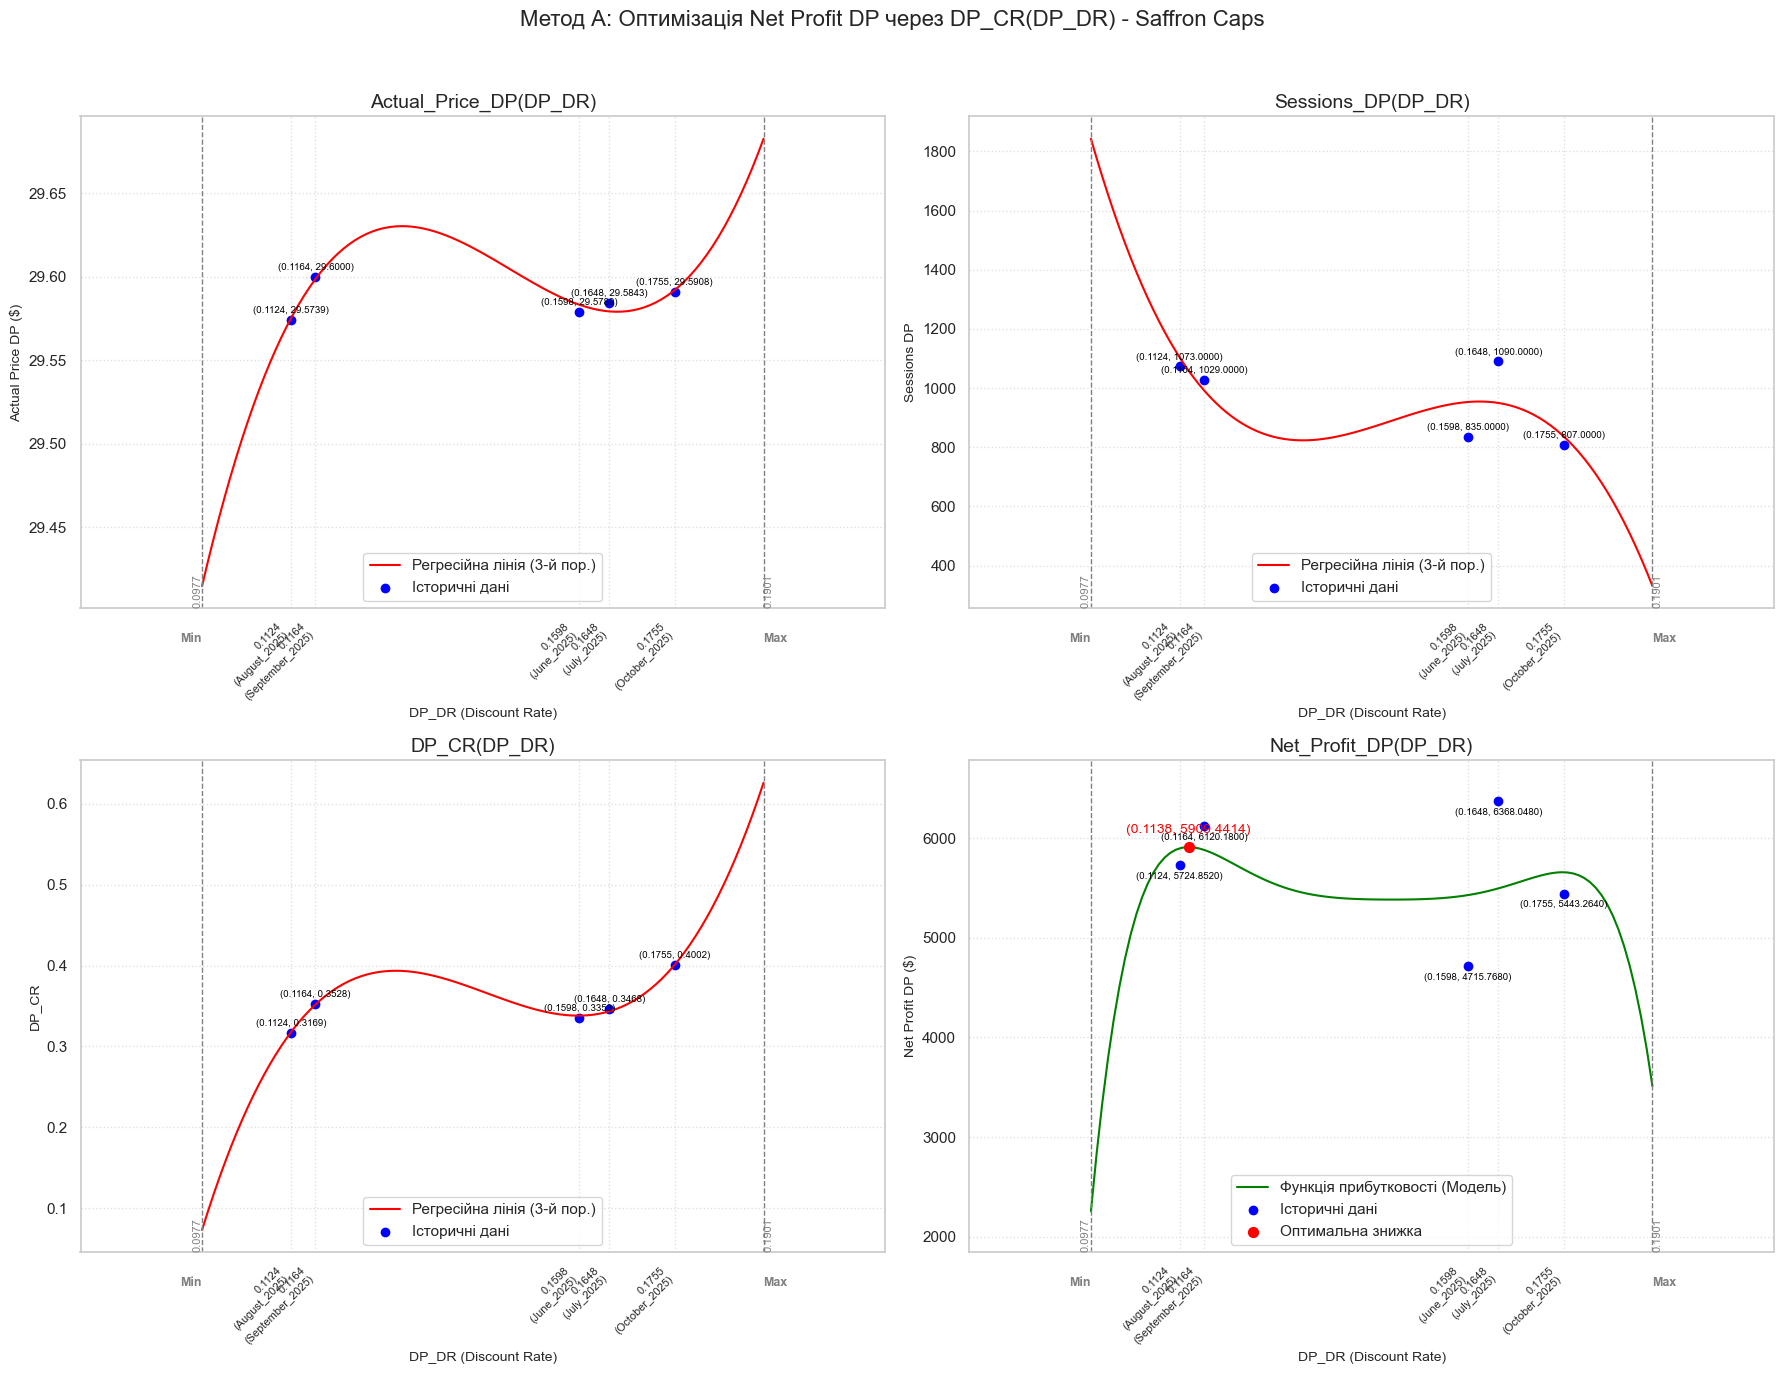

--- 6. СЕРВІСНА ІНФОРМАЦІЯ: РЕЗУЛЬТАТ ОПТИМІЗАЦІЇ ---
Оптимальна координата: (0.1138, 5909.4414)
Рекомендована знижка: 0.1138
Прогнозований профіт: 5909.4414
Похибка методу (MAPE): 0.0793
Похибка методу (RMSE): 529.6657
----------------------------------------------------------------------
--- 7. СЕРВІСНА ІНФОРМАЦІЯ: ЗБЕРЕЖЕННЯ ---
Успішний запис даних в ALL_METHODS_RESULTS:
- Saffron Caps - Method-A-DP_CR - DP_DR: 0.1138
- Saffron Caps - Method-A-DP_CR - MAPE: 0.0793
----------------------------------------------------------------------


In [4]:
# Встановлення глобальних налаштувань для форматування чисел (4 знаки після коми)
pd.options.display.float_format = '{:.4f}'.format
np.set_printoptions(formatter={'float': '{:.4f}'.format})


# --- 1. ДОПОМІЖНІ ФУНКЦІЇ (ОНОВЛЕНО: ДОДАНО MAPE ТА RMSE) ---

def calculate_r_squared(y_true, y_pred):
    """Розрахунок коефіцієнта детермінації R^2."""
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot) if ss_tot != 0 else 0

def format_poly_str(coefs):
    """Форматування коефіцієнтів полінома 3-го порядку у вигляд рядка."""
    power = len(coefs) - 1
    terms = []
    for c in coefs:
        c_fmt = f"{c:.4f}"
        
        if power == 3:
            term = f"{c_fmt}x^3"
        elif power == 2:
            term = f"{c_fmt}x^2"
        elif power == 1:
            term = f"{c_fmt}x"
        elif power == 0:
            term = f"{c_fmt}"
        else:
            term = ""
        
        if c > 0 and terms:
            terms.append("+" + term)
        elif c < 0:
            terms.append(term)
        elif c > 0 and not terms:
             terms.append(term)
        
        power -= 1
    
    return "".join(terms).lstrip('+').replace('+-', ' - ')

def calculate_mape(y_true, y_pred):
    """Розрахунок Середньої абсолютної відсоткової похибки (MAPE).
    Для коректного розрахунку враховуються лише позитивні історичні значення (y_true > 0).
    """
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    
    # Визначаємо індекси, де історичний профіт > 0.
    non_zero_indices = y_true > 0 
    
    if np.sum(non_zero_indices) == 0:
        return np.nan 

    mape = np.mean(np.abs((y_true[non_zero_indices] - y_pred[non_zero_indices]) / y_true[non_zero_indices]))
    return mape

def calculate_rmse(y_true, y_pred):
    """Розрахунок Кореневої середньоквадратичної похибки (RMSE)."""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

# --- 2. ПІДГОТОВКА ДАНИХ ТА РОЗРАХУНОК КОНСТАНТ ---

metrics_to_use = ['Sessions_DP', 'Net Profit_DP', 'Actual Price_DP', 'Units Ordered_DP', 'Product Costs_DP', 'DP_DR', 'DP_CR']
df_method_A_temp = df_raw.loc[:, [col for col in metrics_to_use if col in df_raw.columns]].T.copy() 

# Створення рядка Unit_Costs_DP (помісячні юніт-кости)
df_method_A_temp.loc['Unit_Costs_DP'] = np.where(
    df_method_A_temp.loc['Units Ordered_DP'] > 0,
    df_method_A_temp.loc['Product Costs_DP'] / df_method_A_temp.loc['Units Ordered_DP'], 
    0.0
)

# Перейменування рядків для узгодженості
df_method_A = df_method_A_temp.rename(index={
    'Sessions_DP': 'Sessions_DP', 
    'Units Ordered_DP': 'Units_Ordered_DP',
    'Product Costs_DP': 'Product_Costs_DP', 
    'Net Profit_DP': 'Net_Profit_DP',
    'Actual Price_DP': 'Actual_Price_DP', 
    'DP_DR': 'DP_DR', 
    'DP_CR': 'DP_CR'
}).reindex(index=['Sessions_DP', 'Units_Ordered_DP', 'Product_Costs_DP', 'Net_Profit_DP',
                  'Actual_Price_DP', 'Unit_Costs_DP', 'DP_DR', 'DP_CR'])


# 2.1. Розрахунок Констант та Меж
dp_dr_series = df_method_A.loc['DP_DR']
month_count = len(df_method_A.columns)
Sessions_DP_Avg = df_method_A.loc['Sessions_DP'].mean()

# Розрахунок Unit_Costs_DP_Avg (на основі загальних сум за період)
total_product_costs = df_method_A.loc['Product_Costs_DP'].sum()
total_units_ordered = df_method_A.loc['Units_Ordered_DP'].sum()
Unit_Costs_DP_Avg = total_product_costs / total_units_ordered if total_units_ordered > 0 else 0

# Межі для DP_DR (Min/Max +/- StDev)
St_Dev_DP_DR = 0.5 * dp_dr_series.std()
min_DP_DR = dp_dr_series.min()
max_DP_DR = dp_dr_series.max()

lower_bound = max(0.0, min_DP_DR - St_Dev_DP_DR)
upper_bound = max_DP_DR + St_Dev_DP_DR
def_Bound_DP_DR = [lower_bound, upper_bound]


# 2.2. ВИВІД ДАТАСЕТУ ТА СЕРВІСНОЇ ІНФОРМАЦІЇ
print(f"--- 1. ДАТАСЕТ ДЛЯ АНАЛІЗУ ---")
display(df_method_A.style.format('{:.4f}'))
print("-" * 70)

print("--- 2. СЕРВІСНА ІНФОРМАЦІЯ: РОЗРАХУНОК КОНСТАНТ ТА МЕЖ ---")
print(f"month_count: {month_count}")
print(f"Sessions_DP_Avg: {Sessions_DP_Avg:.4f}")
print(f"Unit_Costs_DP_Avg: {Unit_Costs_DP_Avg:.4f}")
print(f"St_Dev_DP_DR: {St_Dev_DP_DR:.4f}")
print(f"min_DP_DR: {min_DP_DR:.4f}")
print(f"max_DP_DR: {max_DP_DR:.4f}")
print(f"def_Bound_DP_DR: [{def_Bound_DP_DR[0]:.4f}; {def_Bound_DP_DR[1]:.4f}]")
print("-" * 70)


# --- 3. ПОБУДОВА РЕГРЕСІЇ ---
X = df_method_A.loc['DP_DR'].values
X_month_labels = df_method_A.columns.values
Y_DP_CR = df_method_A.loc['DP_CR'].values
Y_Actual_Price_DP = df_method_A.loc['Actual_Price_DP'].values
Y_Sessions_DP = df_method_A.loc['Sessions_DP'].values
Y_Net_Profit_DP_Actual = df_method_A.loc['Net_Profit_DP'].values # Історичний профіт
poly_order = 3 

# 3.1. DP_CR(DP_DR)
coefs_cr = np.polyfit(X, Y_DP_CR, poly_order); poly_cr = np.poly1d(coefs_cr)
r2_cr = calculate_r_squared(Y_DP_CR, poly_cr(X)); poly_cr_str = format_poly_str(coefs_cr)

# 3.2. Actual_Price_DP(DP_DR)
coefs_price = np.polyfit(X, Y_Actual_Price_DP, poly_order); poly_price = np.poly1d(coefs_price)
r2_price = calculate_r_squared(Y_Actual_Price_DP, poly_price(X)); poly_price_str = format_poly_str(coefs_price)

# 3.3. Sessions_DP(DP_DR)
coefs_sessions = np.polyfit(X, Y_Sessions_DP, poly_order); poly_sessions = np.poly1d(coefs_sessions)
r2_sessions = calculate_r_squared(Y_Sessions_DP, poly_sessions(X)); poly_sessions_str = format_poly_str(coefs_sessions)

# Визначення функції Sessions (Sessions_DP(DP_DR) або Sessions_DP_Avg)
use_avg_sessions = r2_sessions <= 0.1
sessions_info = 'так' if use_avg_sessions else 'ні'

if use_avg_sessions:
    final_sessions_func = lambda dp_dr: Sessions_DP_Avg
    sessions_text = "Sessions_DP_Avg"
else:
    final_sessions_func = poly_sessions
    sessions_text = "Sessions_DP(DP_DR)"

# 3.4. ВИВІД СЕРВІСНОЇ ІНФОРМАЦІЇ: РЕГРЕСІЯ ТА ФОРМУЛА
print("--- 3. СЕРВІСНА ІНФОРМАЦІЯ: РЕГРЕСІЯ 3-ГО ПОРЯДКУ ---")
print(f"Регресійний поліном DP_CR(DP_DR) = {poly_cr_str}. Детермінація R_2 = {r2_cr:.4f}")
print(f"Регресійний поліном Actual_Price_DP(DP_DR) = {poly_price_str}. Детермінація R_2 = {r2_price:.4f}")
print(f"Регресійний поліном Sessions_DP(DP_DR) = {poly_sessions_str}. Детермінація R_2 = {r2_sessions:.4f}")
print(f"\nЗаміна Sessions_DP(DP_DR) на Sessions_DP_Avg: {sessions_info}")
print(f"Формула прибутковості Net_Profit_DP = {sessions_text} * DP_CR(DP_DR) * (Actual_Price_DP(DP_DR) - Unit_Costs_DP_Avg)")
print("-" * 70)


# --- 4. ОПТИМІЗАЦІЯ ТА ОЦІНКА ПОХИБКИ ---

# 4.1. Визначення функції прибутковості (СКЛАДЕНА МОДЕЛЬ)
def net_profit_dp_func(dp_dr):
    # Units Ordered DP = DP_CR(DP_DR) * Sessions_DP
    units_ordered_pred = poly_cr(dp_dr) * final_sessions_func(dp_dr)
    
    margin_per_unit = poly_price(dp_dr) - Unit_Costs_DP_Avg
    return units_ordered_pred * margin_per_unit

# 4.2. Оцінка похибки (порівняння прогнозу зі складеної моделі з історичним профітом)
Y_Net_Profit_DP_Predicted = net_profit_dp_func(X)
mape_error = calculate_mape(Y_Net_Profit_DP_Actual, Y_Net_Profit_DP_Predicted)
rmse_error = calculate_rmse(Y_Net_Profit_DP_Actual, Y_Net_Profit_DP_Predicted)


# 4.3. Оптимізація
optimization_result = minimize_scalar(
    lambda x: -net_profit_dp_func(x),
    bounds=def_Bound_DP_DR,
    method='bounded'
)

optimal_dp_dr = optimization_result.x
max_net_profit = -optimization_result.fun 


# --- 5. ГРАФІКИ ---

X_plot = np.linspace(def_Bound_DP_DR[0], def_Bound_DP_DR[1], 100)
Y_historical_np = Y_Net_Profit_DP_Actual
Y_function_np = net_profit_dp_func(X_plot)

# Створення сітки 2x2
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle(f'Метод А: Оптимізація Net Profit DP через DP_CR(DP_DR) - {product_name}', fontsize=16)
axes_flat = axes.flatten()

plots_data = [
    {'ax': axes_flat[0], 'Y_data': Y_Actual_Price_DP, 'poly': poly_price, 'title': 'Actual_Price_DP(DP_DR)', 'y_label': 'Actual Price DP ($)'},
    {'ax': axes_flat[1], 'Y_data': Y_Sessions_DP, 'poly': poly_sessions, 'title': 'Sessions_DP(DP_DR)', 'y_label': 'Sessions DP'},
    {'ax': axes_flat[2], 'Y_data': Y_DP_CR, 'poly': poly_cr, 'title': 'DP_CR(DP_DR)', 'y_label': 'DP_CR'},
]

min_bound, max_bound = def_Bound_DP_DR
x_padding = 0.02 

# ІТЕРАЦІЯ ТА ПОБУДОВА ТРЬОХ РЕГРЕСІЙНИХ ГРАФІКІВ
for i, plot_info in enumerate(plots_data):
    ax = plot_info['ax']
    Y_data = plot_info['Y_data']
    poly_func = plot_info['poly']
    
    # 1. Побудова лінії регресії
    ax.plot(X_plot, poly_func(X_plot), color='red', label='Регресійна лінія (3-й пор.)')
    # 2. Побудова історичних точок
    ax.scatter(X, Y_data, color='blue', marker='o', label='Історичні дані')
    
    # 3. Підпис історичних точок та координат
    for x_val, y_val in zip(X, Y_data):
        ax.annotate(f'({x_val:.4f}, {y_val:.4f})', (x_val, y_val), textcoords="offset points", 
                    xytext=(0, 5), ha='center', fontsize=7, color='black')

    # 4. Встановлення міток осі X
    ax.set_xticks(X)
    ax.set_xticklabels([f'{x:.4f}\n({m})' for x, m in zip(X, X_month_labels)], rotation=45, ha='right', fontsize=8)

    # *** Візуалізація меж def_Bound_DP_DR ***
    ax.axvline(x=min_bound, color='gray', linestyle='--', linewidth=1)
    ax.axvline(x=max_bound, color='gray', linestyle='--', linewidth=1)
    ax.set_xlim(min_bound - x_padding, max_bound + x_padding)
    
    y_min, y_max = ax.get_ylim()
    y_range = y_max - y_min
    
    # Числові значення меж
    ax.text(min_bound, y_min, f'{min_bound:.4f}', rotation=90, va='bottom', ha='right', fontsize=8, color='gray')
    ax.text(max_bound, y_min, f'{max_bound:.4f}', rotation=90, va='bottom', ha='left', fontsize=8, color='gray')
    ax.text(min_bound, y_min - y_range * 0.05, 'Min', va='top', ha='right', fontsize=9, color='gray', weight='bold')
    ax.text(max_bound, y_min - y_range * 0.05, 'Max', va='top', ha='left', fontsize=9, color='gray', weight='bold')

    ax.set_title(plot_info['title'], fontsize=14)
    ax.set_xlabel('DP_DR (Discount Rate)', fontsize=10)
    ax.set_ylabel(plot_info['y_label'], fontsize=10)
    ax.legend(loc='best')
    ax.grid(True, linestyle=':', alpha=0.6)


# 4.4. Графік функції прибутковості (Останній графік в сітці 2x2)
ax_profit = axes_flat[3]

# Крива функції прибутковості
ax_profit.plot(X_plot, Y_function_np, color='green', label='Функція прибутковості (Модель)')
# Історичні точки
ax_profit.scatter(X, Y_historical_np, color='blue', marker='o', label='Історичні дані') 
# Точка максимального прибутку
ax_profit.scatter(optimal_dp_dr, max_net_profit, color='red', s=50, zorder=5, label='Оптимальна знижка')

# Підпис оптимальної точки
optimal_coords = (optimal_dp_dr, max_net_profit)
ax_profit.annotate(f'({optimal_dp_dr:.4f}, {max_net_profit:.4f})', 
            optimal_coords, textcoords="offset points", xytext=(0, 10), ha='center', fontsize=10, color='red')

# Підписи історичних точок
for x_val, y_val in zip(X, Y_historical_np):
    ax_profit.annotate(f'({x_val:.4f}, {y_val:.4f})', (x_val, y_val), textcoords="offset points", 
                 xytext=(0, -10), ha='center', fontsize=7, color='black')

# Підпис меж оптимізації
ax_profit.axvline(x=min_bound, color='gray', linestyle='--', linewidth=1)
ax_profit.axvline(x=max_bound, color='gray', linestyle='--', linewidth=1)

# Встановлення меж Y для графіка профіту
y_min_hist = Y_historical_np.min()
y_max_hist = Y_historical_np.max()
y_min_func = Y_function_np.min()
y_max_func = Y_function_np.max()
y_min_plot = min(y_min_hist, y_min_func)
y_max_plot = max(y_max_hist, y_max_func)
y_range_plot = y_max_plot - y_min_plot
ax_profit.set_ylim(y_min_plot - y_range_plot * 0.1, y_max_plot + y_range_plot * 0.1)

# Підписи числових значень меж
y_min_profit, y_max_profit = ax_profit.get_ylim()
y_range_profit = y_max_profit - y_min_profit

ax_profit.text(min_bound, y_min_profit, f'{min_bound:.4f}', rotation=90, va='bottom', ha='right', fontsize=8, color='gray')
ax_profit.text(max_bound, y_min_profit, f'{max_bound:.4f}', rotation=90, va='bottom', ha='left', fontsize=8, color='gray')

ax_profit.text(min_bound, y_min_profit - y_range_profit * 0.05, 'Min', va='top', ha='right', fontsize=9, color='gray', weight='bold')
ax_profit.text(max_bound, y_min_profit - y_range_profit * 0.05, 'Max', va='top', ha='left', fontsize=9, color='gray', weight='bold')

# Встановлення міток осі X та меж
ax_profit.set_xticks(X)
ax_profit.set_xticklabels([f'{x:.4f}\n({m})' for x, m in zip(X, X_month_labels)], rotation=45, ha='right', fontsize=8)
ax_profit.set_xlim(min_bound - x_padding, max_bound + x_padding) 

ax_profit.set_title('Net_Profit_DP(DP_DR)', fontsize=14)
ax_profit.set_xlabel('DP_DR (Discount Rate)', fontsize=10)
ax_profit.set_ylabel('Net Profit DP ($)', fontsize=10)
ax_profit.legend(loc='best')
ax_profit.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


# --- 6. ФІНАЛЬНИЙ ВИВІД ТА ЗБЕРЕЖЕННЯ ---
print("--- 6. СЕРВІСНА ІНФОРМАЦІЯ: РЕЗУЛЬТАТ ОПТИМІЗАЦІЇ ---")
print(f"Оптимальна координата: ({optimal_dp_dr:.4f}, {max_net_profit:.4f})")
print(f"Рекомендована знижка: {optimal_dp_dr:.4f}")
print(f"Прогнозований профіт: {max_net_profit:.4f}")
# НОВОВВЕДЕННЯ: Додано вивід похибок
print(f"Похибка методу (MAPE): {mape_error:.4f}")
print(f"Похибка методу (RMSE): {rmse_error:.4f}")
print("-" * 70)

# Збереження результату
method_key = "Method-A-DP_CR" 
save_success = False

if 'ALL_METHODS_RESULTS' in globals():
    # НОВОВВЕДЕННЯ: Збереження DP_DR та MAPE
    ALL_METHODS_RESULTS[f"{product_name} - {method_key} - DP_DR"] = optimal_dp_dr
    ALL_METHODS_RESULTS[f"{product_name} - {method_key} - MAPE"] = mape_error
    save_success = True
    
print("--- 7. СЕРВІСНА ІНФОРМАЦІЯ: ЗБЕРЕЖЕННЯ ---")
if save_success:
    print(f"Успішний запис даних в ALL_METHODS_RESULTS:")
    print(f"- {product_name} - {method_key} - DP_DR: {optimal_dp_dr:.4f}")
    print(f"- {product_name} - {method_key} - MAPE: {mape_error:.4f}")
else:
    print(f"Помилка: Словник ALL_METHODS_RESULTS не визначено. Будь ласка, визначте його на початку ноутбука (ALL_METHODS_RESULTS = {{}}) для збереження результатів.")
print("-" * 70)

### КРОК 4: Метод-B-DP_TAR

#### Таблиця показників та формул

| Змінна/Показник | Розшифровка | Формула |
| :--- | :--- | :--- |
| **$DP\_DR$** | Discount Rate (коефіцієнт знижки) | $\text{DP\_DR} = 1 - (\text{Actual\_Price\_DP} / (\text{Single\_Price} \times 2))$ |
| **$DP\_TAR$** | Traffic Allocation Rate (частка трафіку DP) | $\text{DP\_TAR} = \text{Sessions\_DP} / \text{Sessions\_SP}$ |
| **$DP\_CR$** | Conversion Rate (коефіцієнт конверсії) | $\text{DP\_CR} = \text{Units\_Ordered\_DP} / \text{Sessions\_DP}$ |
| **$Sessions\_SP$** | Кількість сесій (трафік) на сторінці Single Pack | $\text{Sessions\_SP}$ (Дані звітів) |
| **$Product\_Costs\_DP$** | Загальна собівартість проданих Double Pack | $\text{Product\_Costs\_DP}$ (Дані звітів) |
| **$Actual\_Price\_DP$** | Фактична ціна Double Pack | $\text{Actual\_Price\_DP} = \text{Revenue\_DP} / \text{Units\_Ordered\_DP}$ |
| **$Unit\_Costs\_DP$** | Собівартість одиниці Double Pack (по місяцях) | $\text{Unit\_Costs\_DP} = \text{Product\_Costs\_DP} / \text{Units\_Ordered\_DP}$ |
| **$month\_count$** | Кількість місяців у вибірці | $\text{month\_count} = \text{COUNT}(\text{Month\_Year})$ |
| **$Sessions\_SP\_Avg$**| Середнє історичне значення Sessions\_SP | $\text{Sessions\_SP\_Avg} = \text{MEAN}(\text{Sessions\_SP})$ |
| **$Unit\_Costs\_DP\_Avg$**| Середня історична собівартість одиниці Double Pack | $\text{Unit\_Costs\_DP\_Avg} = \sum \text{Product\_Costs\_DP} / \sum \text{Units\_Ordered\_DP}$ |
| **$St\_Dev\_DP\_DR$** | Середньоквадратичне відхилення $DP\_DR$ | $\text{St\_Dev\_DP\_DR} = \text{STDEV}(\text{DP\_DR})$ |
| **$def\_Bound\_DP\_DR$**| Межі визначення знижки для функції прибутковості | $[\max(0; \text{min\_DP\_DR} - \text{St\_Dev\_DP\_DR}); \text{max\_DP\_DR} + \text{St\_Dev\_DP\_DR}]$ |
| **$Net\_Profit\_DP$** | Чистий прибуток Double Pack (функція оптимізації) | $\text{Net\_Profit\_DP} = \text{Sessions\_SP\_Avg} \times \text{DP\_TAR} \times \text{DP\_CR} \times (\text{Actual\_Price} - \text{Unit\_Costs\_DP\_Avg})$ |
| **$MAPE$** | Середня абсолютна відсоткова похибка | $\text{MAPE} = \frac{1}{n} \sum \left| \frac{\text{Actual} - \text{Model}}{\text{Actual}} \right|$ |
| **$RMSE$** | Коренева середньоквадратична похибка | $\text{RMSE} = \sqrt{\frac{1}{n} \sum (\text{Actual} - \text{Model})^2}$ |

<details>
<summary><b>Алгоритм виконання розрахунків (Інструкція)</b></summary>
<br>

Алгоритм виконує оптимізацію знижки ($DP\_DR$) для максимізації чистого прибутку ($Net\_Profit\_DP$) на основі поліноміальної регресії 3-го порядку:

1.  **Формування Датасету (Крок 2):**
      * Дані $\text{Sessions\_SP, Units Ordered\_DP, Product Costs\_DP, Net Profit\_DP, Actual Price\_DP}$ (з Кроку 1) та $\text{DP\_DR, DP\_CR, DP\_TAR}$ (з Кроку 2) збираються в єдиний датасет.
      * Додається показник $\text{Unit\_Costs\_DP}$ (помісячна собівартість одиниці).
      * Датасет трансформується: місяці — колонки, показники (9 рядків) — рядки.
2.  **Розрахунок Констант та Меж (Крок 4.1):**
      * Обчислюються константи: $\text{month\_count}$, $\text{Sessions\_SP\_Avg}$ (ключова константа), $\text{Unit\_Costs\_DP\_Avg}$, $\text{St\_Dev\_DP\_DR}$, $\text{min\_DP\_DR}$, $\text{max\_DP\_DR}$.
      * Визначаються межі оптимізації $\text{def\_Bound\_DP\_DR}$ шляхом відступу $\pm \text{St\_Dev\_DP\_DR}$ від історичних min/max значень $DP\_DR$, з обмеженням мінімальної межі до $0$.
3.  **Побудова Регресії (Крок 4.2):**
      * Будується поліноміальна регресія **3-го порядку** для $\text{DP\_TAR}(\text{DP\_DR})$, $\text{DP\_CR}(\text{DP\_DR})$ та $\text{Actual\_Price\_DP}(\text{DP\_DR})$.
      * Розраховується $R^2$ для кожної регресії.
4.  **Оцінка Похибки та Оптимізація (Крок 4.3):**
      * Визначається складена функція прибутковості: $\text{Net\_Profit\_DP} = \text{Sessions\_SP\_Avg} \times \text{DP\_TAR}(\text{DP\_DR}) \times \text{DP\_CR}(\text{DP\_DR}) \times (\text{Actual\_Price\_DP}(\text{DP\_DR}) - \text{Unit\_Costs\_DP\_Avg})$.
      * **Оцінюється якість моделі:** Розраховується **$\text{MAPE}$** та **$\text{RMSE}$** шляхом порівняння значень $\text{Net\_Profit\_DP}$ (отриманих моделлю) з $\text{Net\_Profit\_DP}$ (історичними даними) для всіх історичних точок.
      * За допомогою функції $\text{minimize\_scalar}$ (метод 'bounded') шукається $\text{optimal\_dp\_dr}$, який максимізує $\text{Net\_Profit\_DP}$ у межах $\text{def\_Bound\_DP\_DR}$.
5.  **Візуалізація (Крок 4.4):**
      * Виводяться 3 графіки регресійних кривих та фінальний графік кривої прибутковості, історичних точок та знайденої оптимальної точки. На графіках пунктиром показані межі $\text{def\_Bound\_DP\_DR}$.
6.  **Звітність (Кроки 6-7):**
      * Знайдений $\text{optimal\_dp\_dr}$ та розрахований $\text{MAPE}$ зберігаються у словник $\text{ALL\_METHODS\_RESULTS}$ під ключами $\text{Product Name - Method-B-DP\_TAR - DP\_DR}$ та $\text{Product Name - Method-B-DP\_TAR - MAPE}$ відповідно.
      * Вся сервісна інформація (**включаючи $\text{MAPE}$ та $\text{RMSE}$**) виводиться у текстовому форматі.

</details>

--- 1. ДАТАСЕТ ДЛЯ АНАЛІЗУ ---


Month_Year,June_2025,July_2025,August_2025,September_2025,October_2025
Metric,,,,,
Sessions_SP,13303.0000,16320.0000,19604.0000,17071.0000,8783.0000
Units_Ordered_DP,280.0000,378.0000,340.0000,363.0000,323.0000
Product_Costs_DP,3566.3120,4814.8320,4330.2680,4624.6200,4114.5760
Net_Profit_DP,4715.7680,6368.0480,5724.8520,6120.1800,5443.2640
Actual_Price_DP,29.5789,29.5843,29.5739,29.6000,29.5908
Unit_Costs_DP,12.7368,12.7377,12.7361,12.7400,12.7386
DP_CR,0.3353,0.3468,0.3169,0.3528,0.4002
DP_TAR,0.0628,0.0668,0.0547,0.0603,0.0919
DP_DR,0.1598,0.1648,0.1124,0.1164,0.1755


----------------------------------------------------------------------
--- 2. СЕРВІСНА ІНФОРМАЦІЯ: РОЗРАХУНОК КОНСТАНТ ТА МЕЖ ---
month_count: 5
Sessions_SP_Avg: 15016.2000
Unit_Costs_DP_Avg: 12.7379
St_Dev_DP_DR: 0.0146
min_DP_DR: 0.1124
max_DP_DR: 0.1755
def_Bound_DP_DR: [0.0977; 0.1901]
----------------------------------------------------------------------
--- 3. СЕРВІСНА ІНФОРМАЦІЯ: РЕГРЕСІЯ 3-ГО ПОРЯДКУ ---
Регресійний поліном DP_TAR(DP_DR) = 962.3886x^3-403.6232x^2+56.0061x-2.5078. Детермінація R_2 = 0.9991
Регресійний поліном DP_CR(DP_DR) = 4099.8741x^3-1778.8378x^2+254.4943x-11.6358. Детермінація R_2 = 0.9947
Регресійний поліном Actual_Price_DP(DP_DR) = 2315.3702x^3-1030.4272x^2+150.6857x+22.3684. Детермінація R_2 = 0.8806

Формула прибутковості Net_Profit_DP = Sessions_SP_Avg * DP_TAR(DP_DR) * DP_CR(DP_DR) * (Actual_Price_DP(DP_DR) - Unit_Costs_DP_Avg)
----------------------------------------------------------------------


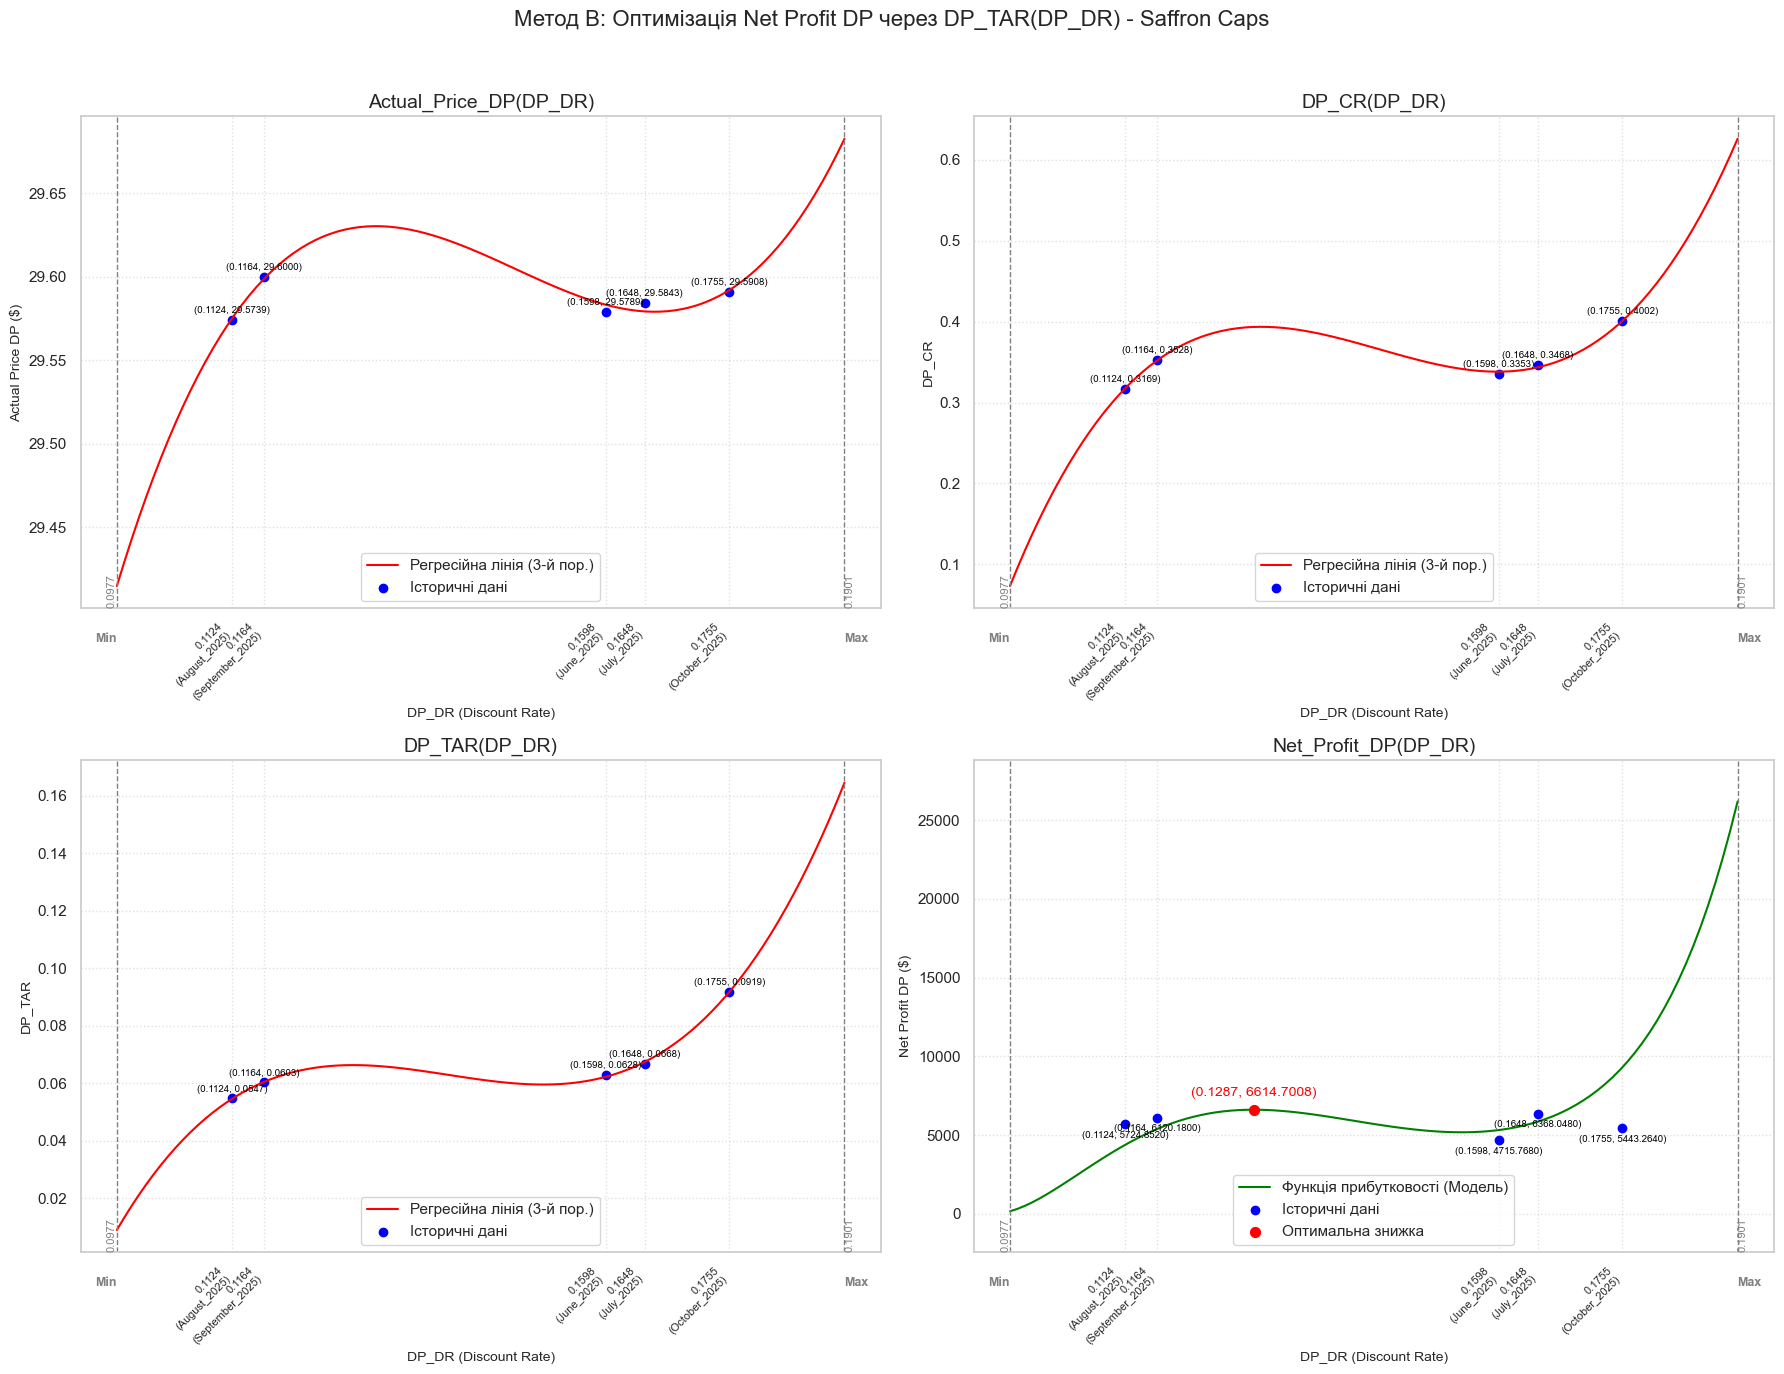

--- 6. СЕРВІСНА ІНФОРМАЦІЯ: РЕЗУЛЬТАТ ОПТИМІЗАЦІЇ ---
Оптимальна координата: (0.1287, 6614.7008)
Рекомендована знижка: 0.1287
Прогнозований профіт: 6614.7008
Похибка методу (MAPE): 0.2547
Похибка методу (RMSE): 1893.0610
----------------------------------------------------------------------
--- 7. СЕРВІСНА ІНФОРМАЦІЯ: ЗБЕРЕЖЕННЯ ---
Успішний запис даних в ALL_METHODS_RESULTS:
- Saffron Caps - Method-B-DP_TAR - DP_DR: 0.1287
- Saffron Caps - Method-B-DP_TAR - MAPE: 0.2547
----------------------------------------------------------------------


In [5]:
# Встановлення глобальних налаштувань для форматування чисел (4 знаки після коми)
pd.options.display.float_format = '{:.4f}'.format
np.set_printoptions(formatter={'float': '{:.4f}'.format})


# --- 1. ДОПОМІЖНІ ФУНКЦІЇ ---

def calculate_r_squared(y_true, y_pred):
    """Розрахунок коефіцієнта детермінації R^2."""
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot) if ss_tot != 0 else 0

def format_poly_str(coefs):
    """Форматування коефіцієнтів полінома 3-го порядку у вигляд рядка."""
    power = len(coefs) - 1
    terms = []
    for c in coefs:
        c_fmt = f"{c:.4f}"
        
        if power == 3:
            term = f"{c_fmt}x^3"
        elif power == 2:
            term = f"{c_fmt}x^2"
        elif power == 1:
            term = f"{c_fmt}x"
        elif power == 0:
            term = f"{c_fmt}"
        else:
            term = ""
        
        if c > 0 and terms:
            terms.append("+" + term)
        elif c < 0:
            terms.append(term)
        elif c > 0 and not terms:
             terms.append(term)
        
        power -= 1
    
    return "".join(terms).lstrip('+').replace('+-', ' - ')

def calculate_mape(y_true, y_pred):
    """Розрахунок Середньої абсолютної відсоткової похибки (MAPE).
    Уникає ділення на нуль, якщо y_true == 0, і повертає 0, якщо y_true < 0 (або NAN)
    для спрощення, оскільки Net Profit має бути позитивним.
    """
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    
    # Визначаємо індекси, де історичний профіт > 0.
    # Для Net Profit < 0 (збитки) або Net Profit = 0 MAPE не має сенсу.
    non_zero_indices = y_true > 0 
    
    if np.sum(non_zero_indices) == 0:
        return np.nan # Повертаємо NAN, якщо всі історичні профіти не позитивні

    mape = np.mean(np.abs((y_true[non_zero_indices] - y_pred[non_zero_indices]) / y_true[non_zero_indices]))
    return mape

def calculate_rmse(y_true, y_pred):
    """Розрахунок Кореневої середньоквадратичної похибки (RMSE)."""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

# --- 2. ПІДГОТОВКА ДАНИХ ТА РОЗРАХУНОК КОНСТАНТ ---

# Вибираємо метрики для Методу B.
metrics_to_use_B = ['Sessions_SP', 'Units Ordered_DP', 'Product Costs_DP', 
                    'Net Profit_DP', 'Actual Price_DP', 'DP_CR', 'DP_TAR', 'DP_DR']
df_method_B_temp = df_raw.loc[:, [col for col in metrics_to_use_B if col in df_raw.columns]].T.copy() 

# Створення рядка Unit_Costs_DP (помісячні юніт-кости)
df_method_B_temp.loc['Unit_Costs_DP'] = np.where(
    df_method_B_temp.loc['Units Ordered_DP'] > 0,
    df_method_B_temp.loc['Product Costs_DP'] / df_method_B_temp.loc['Units Ordered_DP'],
    0.0
)

# Перейменування рядків для узгодженості
df_method_B = df_method_B_temp.rename(index={
    'Sessions_SP': 'Sessions_SP', 
    'Units Ordered_DP': 'Units_Ordered_DP',
    'Product Costs_DP': 'Product_Costs_DP', 
    'Net Profit_DP': 'Net_Profit_DP',
    'Actual Price_DP': 'Actual_Price_DP', 
    'DP_CR': 'DP_CR', 
    'DP_TAR': 'DP_TAR',
    'DP_DR': 'DP_DR'
}).reindex(index=['Sessions_SP', 'Units_Ordered_DP', 'Product_Costs_DP', 'Net_Profit_DP',
                  'Actual_Price_DP', 'Unit_Costs_DP', 'DP_CR', 'DP_TAR', 'DP_DR'])


# 2.1. Розрахунок Констант та Меж
dp_dr_series = df_method_B.loc['DP_DR'] # Незалежна змінна для меж
month_count = len(df_method_B.columns)

# Головна константа: Середня кількість сесій SP
Sessions_SP_Avg = df_method_B.loc['Sessions_SP'].mean()

# Головна константа: Середні юніт-кости DP
total_product_costs = df_method_B.loc['Product_Costs_DP'].sum()
total_units_ordered = df_method_B.loc['Units_Ordered_DP'].sum()
Unit_Costs_DP_Avg = total_product_costs / total_units_ordered if total_units_ordered > 0 else 0

# Межі для DP_DR (Min/Max +/- StDev)
St_Dev_DP_DR = 0.5 * dp_dr_series.std()
min_DP_DR = dp_dr_series.min()
max_DP_DR = dp_dr_series.max()

lower_bound_dr = max(0.0, min_DP_DR - St_Dev_DP_DR)
upper_bound_dr = max_DP_DR + St_Dev_DP_DR
def_Bound_DP_DR = [lower_bound_dr, upper_bound_dr]


# 2.2. ВИВІД ДАТАСЕТУ ТА СЕРВІСНОЇ ІНФОРМАЦІЇ
print(f"--- 1. ДАТАСЕТ ДЛЯ АНАЛІЗУ ---")
display(df_method_B.style.format('{:.4f}'))
print("-" * 70)

print("--- 2. СЕРВІСНА ІНФОРМАЦІЯ: РОЗРАХУНОК КОНСТАНТ ТА МЕЖ ---")
print(f"month_count: {month_count}")
print(f"Sessions_SP_Avg: {Sessions_SP_Avg:.4f}")
print(f"Unit_Costs_DP_Avg: {Unit_Costs_DP_Avg:.4f}")
print(f"St_Dev_DP_DR: {St_Dev_DP_DR:.4f}")
print(f"min_DP_DR: {min_DP_DR:.4f}")
print(f"max_DP_DR: {max_DP_DR:.4f}")
print(f"def_Bound_DP_DR: [{def_Bound_DP_DR[0]:.4f}; {def_Bound_DP_DR[1]:.4f}]")
print("-" * 70)


# --- 3. ПОБУДОВА РЕГРЕСІЇ ---
X = df_method_B.loc['DP_DR'].values # Незалежна змінна - DP_DR
X_month_labels = df_method_B.columns.values
Y_DP_CR = df_method_B.loc['DP_CR'].values
Y_Actual_Price_DP = df_method_B.loc['Actual_Price_DP'].values
Y_DP_TAR = df_method_B.loc['DP_TAR'].values # Залежна змінна - DP_TAR
Y_Net_Profit_DP_Actual = df_method_B.loc['Net_Profit_DP'].values # Історичний профіт
poly_order = 3 

# 3.1. DP_CR(DP_DR)
coefs_cr = np.polyfit(X, Y_DP_CR, poly_order); poly_cr = np.poly1d(coefs_cr)
r2_cr = calculate_r_squared(Y_DP_CR, poly_cr(X)); poly_cr_str = format_poly_str(coefs_cr)

# 3.2. Actual_Price_DP(DP_DR)
coefs_price = np.polyfit(X, Y_Actual_Price_DP, poly_order); poly_price = np.poly1d(coefs_price)
r2_price = calculate_r_squared(Y_Actual_Price_DP, poly_price(X)); poly_price_str = format_poly_str(coefs_price)

# 3.3. DP_TAR(DP_DR)
coefs_tar = np.polyfit(X, Y_DP_TAR, poly_order); poly_tar = np.poly1d(coefs_tar)
r2_tar = calculate_r_squared(Y_DP_TAR, poly_tar(X)); poly_tar_str = format_poly_str(coefs_tar)

# Визначення функції Sessions (логіка DP_TAR(DP_DR))
final_tar_func = poly_tar
tar_text = "DP_TAR(DP_DR)"

# 3.4. ВИВІД СЕРВІСНОЇ ІНФОРМАЦІЇ: РЕГРЕСІЯ ТА ФОРМУЛА
print("--- 3. СЕРВІСНА ІНФОРМАЦІЯ: РЕГРЕСІЯ 3-ГО ПОРЯДКУ ---")
print(f"Регресійний поліном DP_TAR(DP_DR) = {poly_tar_str}. Детермінація R_2 = {r2_tar:.4f}")
print(f"Регресійний поліном DP_CR(DP_DR) = {poly_cr_str}. Детермінація R_2 = {r2_cr:.4f}")
print(f"Регресійний поліном Actual_Price_DP(DP_DR) = {poly_price_str}. Детермінація R_2 = {r2_price:.4f}")
print(f"\nФормула прибутковості Net_Profit_DP = Sessions_SP_Avg * {tar_text} * DP_CR(DP_DR) * (Actual_Price_DP(DP_DR) - Unit_Costs_DP_Avg)")
print("-" * 70)


# --- 4. ОПТИМІЗАЦІЯ ТА ОЦІНКА ПОХИБКИ ---

# 4.1. Визначення функції прибутковості (СКЛАДЕНА МОДЕЛЬ)
def net_profit_dp_func_B(dp_dr):
    # Sessions_DP = Sessions_SP_Avg * DP_TAR(DP_DR)
    sessions_dp_pred = Sessions_SP_Avg * final_tar_func(dp_dr)
    
    # Units Ordered DP = Sessions_DP * DP_CR(DP_DR)
    units_ordered_pred = sessions_dp_pred * poly_cr(dp_dr)
    
    margin_per_unit = poly_price(dp_dr) - Unit_Costs_DP_Avg
    return units_ordered_pred * margin_per_unit

# 4.2. Оцінка похибки (порівняння прогнозу зі складеної моделі з історичним профітом)
Y_Net_Profit_DP_Predicted = net_profit_dp_func_B(X)
mape_error = calculate_mape(Y_Net_Profit_DP_Actual, Y_Net_Profit_DP_Predicted)
rmse_error = calculate_rmse(Y_Net_Profit_DP_Actual, Y_Net_Profit_DP_Predicted)


# 4.3. Оптимізація
optimization_result_B = minimize_scalar(
    lambda x: -net_profit_dp_func_B(x),
    bounds=def_Bound_DP_DR,
    method='bounded'
)

optimal_dp_dr = optimization_result_B.x
max_net_profit = -optimization_result_B.fun 


# --- 5. ГРАФІКИ ---

X_plot = np.linspace(def_Bound_DP_DR[0], def_Bound_DP_DR[1], 100)
Y_historical_np = Y_Net_Profit_DP_Actual
Y_function_np = net_profit_dp_func_B(X_plot) # СКЛАДЕНА МОДЕЛЬ

# Створення сітки 2x2
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle(f'Метод B: Оптимізація Net Profit DP через DP_TAR(DP_DR) - {product_name}', fontsize=16)
axes_flat = axes.flatten()

# ВИПРАВЛЕНО: Змінено порядок графіків
plots_data = [
    {'ax_index': 0, 'Y_data': Y_Actual_Price_DP, 'poly': poly_price, 'title': 'Actual_Price_DP(DP_DR)', 'y_label': 'Actual Price DP ($)'},
    {'ax_index': 1, 'Y_data': Y_DP_CR, 'poly': poly_cr, 'title': 'DP_CR(DP_DR)', 'y_label': 'DP_CR'},
    {'ax_index': 2, 'Y_data': Y_DP_TAR, 'poly': poly_tar, 'title': 'DP_TAR(DP_DR)', 'y_label': 'DP_TAR'},
]

min_bound, max_bound = def_Bound_DP_DR
x_padding = 0.05 * (max_bound - min_bound) 

# ІТЕРАЦІЯ ТА ПОБУДОВА ТРЬОХ РЕГРЕСІЙНИХ ГРАФІКІВ
for i, plot_info in enumerate(plots_data):
    ax = axes_flat[plot_info['ax_index']]
    Y_data = plot_info['Y_data']
    poly_func = plot_info['poly']
    
    # 1. Побудова лінії регресії
    ax.plot(X_plot, poly_func(X_plot), color='red', label='Регресійна лінія (3-й пор.)')
    # 2. Побудова історичних точок
    ax.scatter(X, Y_data, color='blue', marker='o', label='Історичні дані')
    
    # 3. Підпис історичних точок та координат
    for x_val, y_val in zip(X, Y_data):
        ax.annotate(f'({x_val:.4f}, {y_val:.4f})', (x_val, y_val), textcoords="offset points", 
                    xytext=(0, 5), ha='center', fontsize=7, color='black')

    # 4. Встановлення міток осі X
    ax.set_xticks(X)
    ax.set_xticklabels([f'{x:.4f}\n({m})' for x, m in zip(X, X_month_labels)], rotation=45, ha='right', fontsize=8)

    # *** Візуалізація меж def_Bound_DP_DR ***
    ax.axvline(x=min_bound, color='gray', linestyle='--', linewidth=1)
    ax.axvline(x=max_bound, color='gray', linestyle='--', linewidth=1)
    ax.set_xlim(min_bound - x_padding, max_bound + x_padding)
    
    y_min, y_max = ax.get_ylim()
    y_range = y_max - y_min
    
    # Числові значення меж
    ax.text(min_bound, y_min, f'{min_bound:.4f}', rotation=90, va='bottom', ha='right', fontsize=8, color='gray')
    ax.text(max_bound, y_min, f'{max_bound:.4f}', rotation=90, va='bottom', ha='left', fontsize=8, color='gray')
    ax.text(min_bound, y_min - y_range * 0.05, 'Min', va='top', ha='right', fontsize=9, color='gray', weight='bold')
    ax.text(max_bound, y_min - y_range * 0.05, 'Max', va='top', ha='left', fontsize=9, color='gray', weight='bold')

    ax.set_title(plot_info['title'], fontsize=14)
    ax.set_xlabel('DP_DR (Discount Rate)', fontsize=10)
    ax.set_ylabel(plot_info['y_label'], fontsize=10)
    ax.legend(loc='best')
    ax.grid(True, linestyle=':', alpha=0.6)


# 4.4. Графік функції прибутковості (Останній графік в сітці 2x2)
ax_profit = axes_flat[3]

# Крива функції прибутковості (СКЛАДЕНА МОДЕЛЬ)
ax_profit.plot(X_plot, Y_function_np, color='green', label='Функція прибутковості (Модель)')
# Історичні точки
ax_profit.scatter(X, Y_historical_np, color='blue', marker='o', label='Історичні дані') 
# Точка максимального прибутку
ax_profit.scatter(optimal_dp_dr, max_net_profit, color='red', s=50, zorder=5, label='Оптимальна знижка')

# Підпис оптимальної точки
optimal_coords = (optimal_dp_dr, max_net_profit)
ax_profit.annotate(f'({optimal_dp_dr:.4f}, {max_net_profit:.4f})', 
            optimal_coords, textcoords="offset points", xytext=(0, 10), ha='center', fontsize=10, color='red')

# Підписи історичних точок
for x_val, y_val in zip(X, Y_historical_np):
    ax_profit.annotate(f'({x_val:.4f}, {y_val:.4f})', (x_val, y_val), textcoords="offset points", 
                 xytext=(0, -10), ha='center', fontsize=7, color='black')

# Підпис меж оптимізації
ax_profit.axvline(x=min_bound, color='gray', linestyle='--', linewidth=1)
ax_profit.axvline(x=max_bound, color='gray', linestyle='--', linewidth=1)

# Встановлення меж Y для графіка профіту
y_min_hist = Y_historical_np.min()
y_max_hist = Y_historical_np.max()

y_min_func = Y_function_np.min()
y_max_func = Y_function_np.max()
y_min_plot = min(y_min_hist, y_min_func)
y_max_plot = max(y_max_hist, y_max_func)
y_range_plot = y_max_plot - y_min_plot

ax_profit.set_ylim(y_min_plot - y_range_plot * 0.1, y_max_plot + y_range_plot * 0.1)

# Підписи числових значень меж
y_min_profit, y_max_profit = ax_profit.get_ylim()
y_range_profit = y_max_profit - y_min_profit

ax_profit.text(min_bound, y_min_profit, f'{min_bound:.4f}', rotation=90, va='bottom', ha='right', fontsize=8, color='gray')
ax_profit.text(max_bound, y_min_profit, f'{max_bound:.4f}', rotation=90, va='bottom', ha='left', fontsize=8, color='gray')

ax_profit.text(min_bound, y_min_profit - y_range_profit * 0.05, 'Min', va='top', ha='right', fontsize=9, color='gray', weight='bold')
ax_profit.text(max_bound, y_min_profit - y_range_profit * 0.05, 'Max', va='top', ha='left', fontsize=9, color='gray', weight='bold')

# Встановлення міток осі X та меж
ax_profit.set_xticks(X)
ax_profit.set_xticklabels([f'{x:.4f}\n({m})' for x, m in zip(X, X_month_labels)], rotation=45, ha='right', fontsize=8)
ax_profit.set_xlim(min_bound - x_padding, max_bound + x_padding) 

ax_profit.set_title('Net_Profit_DP(DP_DR)', fontsize=14)
ax_profit.set_xlabel('DP_DR (Discount Rate)', fontsize=10)
ax_profit.set_ylabel('Net Profit DP ($)', fontsize=10)
ax_profit.legend(loc='best')
ax_profit.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


# --- 6. ФІНАЛЬНИЙ ВИВІД ТА ЗБЕРЕЖЕННЯ ---
print("--- 6. СЕРВІСНА ІНФОРМАЦІЯ: РЕЗУЛЬТАТ ОПТИМІЗАЦІЇ ---")
print(f"Оптимальна координата: ({optimal_dp_dr:.4f}, {max_net_profit:.4f})")
print(f"Рекомендована знижка: {optimal_dp_dr:.4f}")
print(f"Прогнозований профіт: {max_net_profit:.4f}")
# ВИПРАВЛЕНО: Додано вивід похибок
print(f"Похибка методу (MAPE): {mape_error:.4f}")
print(f"Похибка методу (RMSE): {rmse_error:.4f}")
print("-" * 70)

# Збереження результату
method_key = "Method-B-DP_TAR" 
save_success = False

if 'ALL_METHODS_RESULTS' in globals():
    # ВИПРАВЛЕНО: Збереження DP_DR та MAPE
    ALL_METHODS_RESULTS[f"{product_name} - {method_key} - DP_DR"] = optimal_dp_dr
    ALL_METHODS_RESULTS[f"{product_name} - {method_key} - MAPE"] = mape_error
    save_success = True
    
print("--- 7. СЕРВІСНА ІНФОРМАЦІЯ: ЗБЕРЕЖЕННЯ ---")
if save_success:
    print(f"Успішний запис даних в ALL_METHODS_RESULTS:")
    print(f"- {product_name} - {method_key} - DP_DR: {optimal_dp_dr:.4f}")
    print(f"- {product_name} - {method_key} - MAPE: {mape_error:.4f}")
else:
    print(f"Помилка: Словник ALL_METHODS_RESULTS не визначено. Будь ласка, визначте його на початку ноутбука (ALL_METHODS_RESULTS = {{}}) для збереження результатів.")
print("-" * 70)

### КРОК 5: Метод-C-DP_CSC

#### Ключовий показник та формула прибутковості

| Змінна/Показник | Розшифровка | Регресійна модель / Формула розрахунку прибутковості |
| :--- | :--- | :--- |
| **$DP\_CSC$** | Cross-Sell Conversion (крос-конверсія) | $\text{DP\_CSC}(\text{DP\_DR})$ **(Поліноміальна регресія 3-го порядку)** |
| **$Actual\_Price\_DP$** | Фактична ціна Double Pack | $\text{Actual\_Price\_DP}(\text{DP\_DR})$ **(Поліноміальна регресія 3-го порядку)** |
| **$Net\_Profit\_DP$** | Чистий прибуток Double Pack (функція оптимізації) | $$\text{Net\_Profit\_DP} = \text{Sessions\_SP\_Avg} \times \mathbf{DP\_CSC(DP\_DR)} \times (\mathbf{Actual\_Price\_DP(DP\_DR)} - \text{Unit\_Costs\_DP\_Avg})$$ |

<details>
<summary><b>Алгоритм виконання розрахунків</b></summary>
<br>

Алгоритм виконує оптимізацію знижки ($DP\_DR$) для максимізації чистого прибутку ($Net\_Profit\_DP$) на основі складеної функції, що використовує поліноміальну регресію 3-го порядку для моделювання ключових показників:

1.  **Побудова Регресії:** Будуються моделі $\text{DP\_CSC}(\text{DP\_DR})$ та $\text{Actual\_Price\_DP}(\text{DP\_DR})$.
2.  **Складена Функція Профіту:** Використовується наведена вище формула, де $\mathbf{DP\_CSC(DP\_DR)}$ та $\mathbf{Actual\_Price\_DP(DP\_DR)}$ є регресійними функціями, а $\text{Sessions\_SP\_Avg}$ та $\text{Unit\_Costs\_DP\_Avg}$ — константи.
3.  **Оптимізація:** За допомогою функції $\text{minimize\_scalar}$ шукається $\text{optimal\_dp\_dr}$, який максимізує $\text{Net\_Profit\_DP}$ у визначених межах $\text{def\_Bound\_DP\_DR}$.
4.  **Оцінка Якості:** Розраховується **$\text{MAPE}$** та **$\text{RMSE}$** шляхом порівняння значень $\text{Net\_Profit\_DP}$ моделі з історичними даними.
5.  **Візуалізація та Звітність:** Виводяться графіки та кінцевий результат ($\text{optimal\_dp\_dr}$) та метрики якості моделі ($\text{MAPE}, \text{RMSE}$).

</details>

--- 1. ДАТАСЕТ ДЛЯ АНАЛІЗУ ---


Month_Year,June_2025,July_2025,August_2025,September_2025,October_2025
Metric,,,,,
Sessions_SP,13303.0000,16320.0000,19604.0000,17071.0000,8783.0000
Units_Ordered_DP,280.0000,378.0000,340.0000,363.0000,323.0000
Product_Costs_DP,3566.3120,4814.8320,4330.2680,4624.6200,4114.5760
Net_Profit_DP,4715.7680,6368.0480,5724.8520,6120.1800,5443.2640
Actual_Price_DP,29.5789,29.5843,29.5739,29.6000,29.5908
Unit_Costs_DP,12.7368,12.7377,12.7361,12.7400,12.7386
DP_CSC,0.0210,0.0232,0.0173,0.0213,0.0368
DP_DR,0.1598,0.1648,0.1124,0.1164,0.1755


----------------------------------------------------------------------
--- 2. СЕРВІСНА ІНФОРМАЦІЯ: РОЗРАХУНОК КОНСТАНТ ТА МЕЖ ---
month_count: 5
Sessions_SP_Avg: 15016.2000
Unit_Costs_DP_Avg: 12.7379
St_Dev_DP_DR: 0.0146
min_DP_DR: 0.1124
max_DP_DR: 0.1755
def_Bound_DP_DR: [0.0977; 0.1901]
----------------------------------------------------------------------
--- 3. СЕРВІСНА ІНФОРМАЦІЯ: РЕГРЕСІЯ 3-ГО ПОРЯДКУ ---
Регресійний поліном DP_CSC(DP_DR) = 610.0727x^3-258.3013x^2+36.1399x-1.6478. Детермінація R_2 = 0.9996
Регресійний поліном Actual_Price_DP(DP_DR) = 2315.3702x^3-1030.4272x^2+150.6857x+22.3684. Детермінація R_2 = 0.8806

Формула прибутковості Net_Profit_DP = Sessions_SP_Avg * DP_CSC(DP_DR) * (Actual_Price_DP(DP_DR) - Unit_Costs_DP_Avg)
----------------------------------------------------------------------


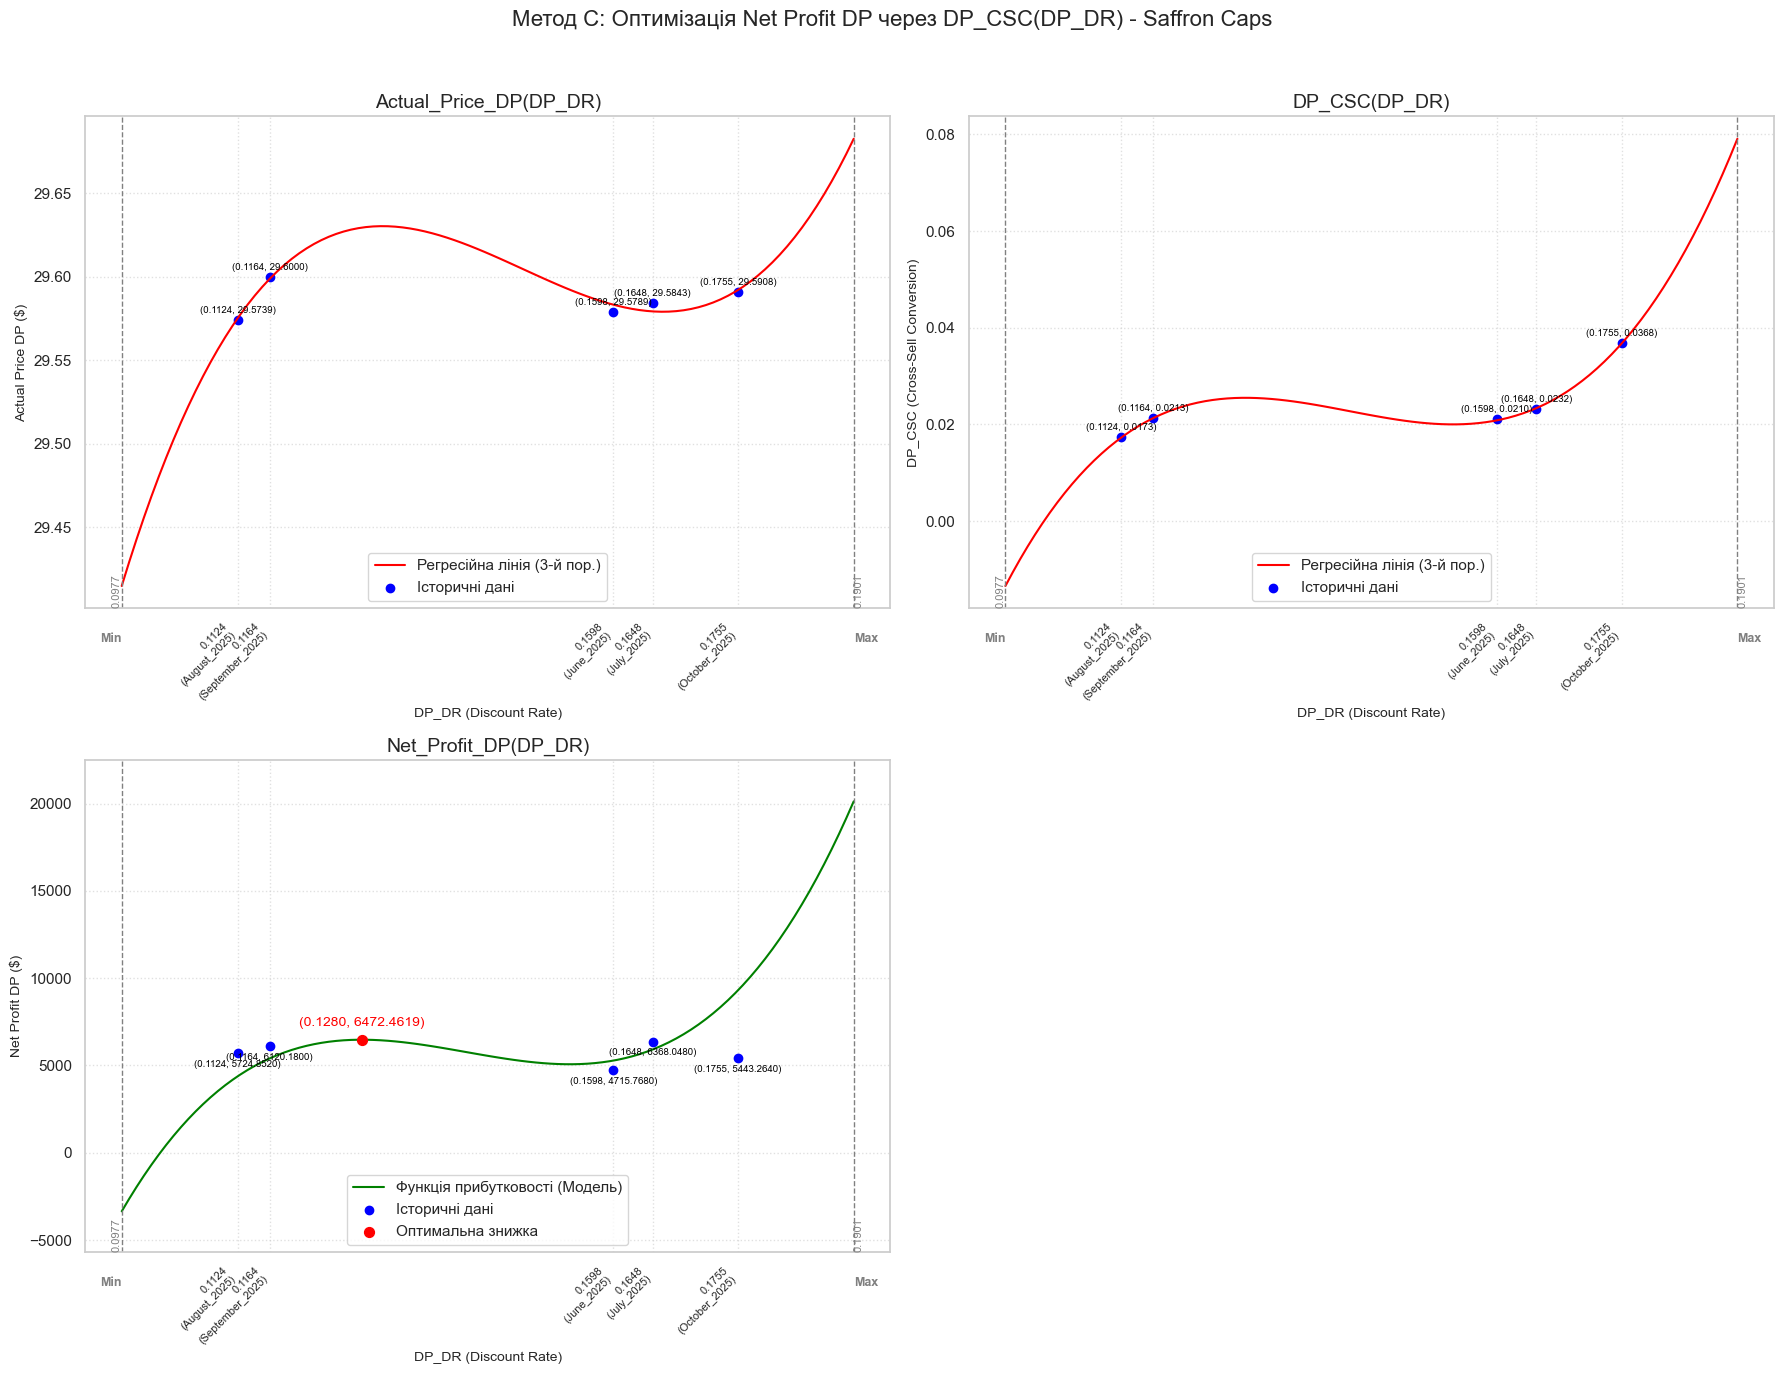

--- 6. СЕРВІСНА ІНФОРМАЦІЯ: РЕЗУЛЬТАТ ОПТИМІЗАЦІЇ ---
Оптимальна координата: (0.1280, 6472.4619)
Рекомендована знижка: 0.1280
Прогнозований профіт: 6472.4619
Похибка методу (MAPE): 0.2504
Похибка методу (RMSE): 1881.8708
----------------------------------------------------------------------
--- 7. СЕРВІСНА ІНФОРМАЦІЯ: ЗБЕРЕЖЕННЯ ---
Успішний запис даних в ALL_METHODS_RESULTS:
- Saffron Caps - Method-C-DP_CSC - DP_DR: 0.1280
- Saffron Caps - Method-C-DP_CSC - MAPE: 0.2504
----------------------------------------------------------------------


In [6]:
# Встановлення глобальних налаштувань для форматування чисел (4 знаки після коми)
pd.options.display.float_format = '{:.4f}'.format
np.set_printoptions(formatter={'float': '{:.4f}'.format})


# --- 1. ДОПОМІЖНІ ФУНКЦІЇ (ПЕРЕВИКОРИСТАННЯ) ---

def calculate_r_squared(y_true, y_pred):
    """Розрахунок коефіцієнта детермінації R^2."""
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot) if ss_tot != 0 else 0

def format_poly_str(coefs):
    """Форматування коефіцієнтів полінома 3-го порядку у вигляд рядка."""
    power = len(coefs) - 1
    terms = []
    for c in coefs:
        c_fmt = f"{c:.4f}"
        
        if power == 3:
            term = f"{c_fmt}x^3"
        elif power == 2:
            term = f"{c_fmt}x^2"
        elif power == 1:
            term = f"{c_fmt}x"
        elif power == 0:
            term = f"{c_fmt}"
        else:
            term = ""
        
        if c > 0 and terms:
            terms.append("+" + term)
        elif c < 0:
            terms.append(term)
        elif c > 0 and not terms:
             terms.append(term)
        
        power -= 1
    
    return "".join(terms).lstrip('+').replace('+-', ' - ')

def calculate_mape(y_true, y_pred):
    """Розрахунок Середньої абсолютної відсоткової похибки (MAPE).
    Для коректного розрахунку враховуються лише позитивні історичні значення (y_true > 0).
    """
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    non_zero_indices = y_true > 0 
    
    if np.sum(non_zero_indices) == 0:
        return np.nan 

    mape = np.mean(np.abs((y_true[non_zero_indices] - y_pred[non_zero_indices]) / y_true[non_zero_indices]))
    return mape

def calculate_rmse(y_true, y_pred):
    """Розрахунок Кореневої середньоквадратичної похибки (RMSE)."""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

# --- 2. ПІДГОТОВКА ДАНИХ ТА РОЗРАХУНОК КОНСТАНТ ---

metrics_to_use_C = ['Sessions_SP', 'Units Ordered_DP', 'Product Costs_DP', 
                    'Net Profit_DP', 'Actual Price_DP', 'DP_DR']
df_method_C_temp = df_raw.loc[:, [col for col in metrics_to_use_C if col in df_raw.columns]].T.copy() 

# Створення рядка Unit_Costs_DP (помісячні юніт-кости)
df_method_C_temp.loc['Unit_Costs_DP'] = np.where(
    df_method_C_temp.loc['Units Ordered_DP'] > 0,
    df_method_C_temp.loc['Product Costs_DP'] / df_method_C_temp.loc['Units Ordered_DP'],
    0.0
)

# Створення рядка DP_CSC (Cross-Sell Conversion)
df_method_C_temp.loc['DP_CSC'] = np.where(
    df_method_C_temp.loc['Sessions_SP'] > 0,
    df_method_C_temp.loc['Units Ordered_DP'] / df_method_C_temp.loc['Sessions_SP'],
    0.0
)

# Перейменування рядків для узгодженості та реіндексація
df_method_C = df_method_C_temp.rename(index={
    'Sessions_SP': 'Sessions_SP', 
    'Units Ordered_DP': 'Units_Ordered_DP',
    'Product Costs_DP': 'Product_Costs_DP', 
    'Net Profit_DP': 'Net_Profit_DP',
    'Actual Price_DP': 'Actual_Price_DP', 
    'DP_DR': 'DP_DR'
}).reindex(index=['Sessions_SP', 'Units_Ordered_DP', 'Product_Costs_DP', 'Net_Profit_DP',
                  'Actual_Price_DP', 'Unit_Costs_DP', 'DP_CSC', 'DP_DR'])


# 2.1. Розрахунок Констант та Меж
dp_dr_series = df_method_C.loc['DP_DR'] # Незалежна змінна для меж
month_count = len(df_method_C.columns)

# Головна константа: Середня кількість сесій SP
Sessions_SP_Avg = df_method_C.loc['Sessions_SP'].mean()

# Головна константа: Середні юніт-кости DP
total_product_costs = df_method_C.loc['Product_Costs_DP'].sum()
total_units_ordered = df_method_C.loc['Units_Ordered_DP'].sum()
Unit_Costs_DP_Avg = total_product_costs / total_units_ordered if total_units_ordered > 0 else 0

# Межі для DP_DR (Min/Max +/- StDev)
St_Dev_DP_DR = 0.5 * dp_dr_series.std()
min_DP_DR = dp_dr_series.min()
max_DP_DR = dp_dr_series.max()

lower_bound_dr = max(0.0, min_DP_DR - St_Dev_DP_DR)
upper_bound_dr = max_DP_DR + St_Dev_DP_DR
def_Bound_DP_DR = [lower_bound_dr, upper_bound_dr]


# 2.2. ВИВІД ДАТАСЕТУ ТА СЕРВІСНОЇ ІНФОРМАЦІЇ
print(f"--- 1. ДАТАСЕТ ДЛЯ АНАЛІЗУ ---")
display(df_method_C.style.format('{:.4f}'))
print("-" * 70)

print("--- 2. СЕРВІСНА ІНФОРМАЦІЯ: РОЗРАХУНОК КОНСТАНТ ТА МЕЖ ---")
print(f"month_count: {month_count}")
print(f"Sessions_SP_Avg: {Sessions_SP_Avg:.4f}")
print(f"Unit_Costs_DP_Avg: {Unit_Costs_DP_Avg:.4f}")
print(f"St_Dev_DP_DR: {St_Dev_DP_DR:.4f}")
print(f"min_DP_DR: {min_DP_DR:.4f}")
print(f"max_DP_DR: {max_DP_DR:.4f}")
print(f"def_Bound_DP_DR: [{def_Bound_DP_DR[0]:.4f}; {def_Bound_DP_DR[1]:.4f}]")
print("-" * 70)


# --- 3. ПОБУДОВА РЕГРЕСІЇ ---
X = df_method_C.loc['DP_DR'].values # Незалежна змінна - DP_DR
X_month_labels = df_method_C.columns.values
Y_DP_CSC = df_method_C.loc['DP_CSC'].values # Залежна змінна - DP_CSC
Y_Actual_Price_DP = df_method_C.loc['Actual_Price_DP'].values
Y_Net_Profit_DP_Actual = df_method_C.loc['Net_Profit_DP'].values # Історичний профіт
poly_order = 3 

# 3.1. DP_CSC(DP_DR)
coefs_csc = np.polyfit(X, Y_DP_CSC, poly_order); poly_csc = np.poly1d(coefs_csc)
r2_csc = calculate_r_squared(Y_DP_CSC, poly_csc(X)); poly_csc_str = format_poly_str(coefs_csc)
final_csc_func = poly_csc
csc_text = "DP_CSC(DP_DR)"

# 3.2. Actual_Price_DP(DP_DR)
coefs_price = np.polyfit(X, Y_Actual_Price_DP, poly_order); poly_price = np.poly1d(coefs_price)
r2_price = calculate_r_squared(Y_Actual_Price_DP, poly_price(X)); poly_price_str = format_poly_str(coefs_price)


# 3.3. ВИВІД СЕРВІСНОЇ ІНФОРМАЦІЇ: РЕГРЕСІЯ ТА ФОРМУЛА
print("--- 3. СЕРВІСНА ІНФОРМАЦІЯ: РЕГРЕСІЯ 3-ГО ПОРЯДКУ ---")
print(f"Регресійний поліном DP_CSC(DP_DR) = {poly_csc_str}. Детермінація R_2 = {r2_csc:.4f}")
print(f"Регресійний поліном Actual_Price_DP(DP_DR) = {poly_price_str}. Детермінація R_2 = {r2_price:.4f}")
print(f"\nФормула прибутковості Net_Profit_DP = Sessions_SP_Avg * {csc_text} * (Actual_Price_DP(DP_DR) - Unit_Costs_DP_Avg)")
print("-" * 70)


# --- 4. ОПТИМІЗАЦІЯ ТА ОЦІНКА ПОХИБКИ ---

# 4.1. Визначення функції прибутковості (СКЛАДЕНА МОДЕЛЬ)
def net_profit_dp_func_C(dp_dr):
    # Units Ordered DP = Sessions_SP_Avg * DP_CSC(DP_DR)
    units_ordered_pred = Sessions_SP_Avg * final_csc_func(dp_dr)
    
    margin_per_unit = poly_price(dp_dr) - Unit_Costs_DP_Avg
    return units_ordered_pred * margin_per_unit

# 4.2. Оцінка похибки (порівняння прогнозу зі складеної моделі з історичним профітом)
Y_Net_Profit_DP_Predicted = net_profit_dp_func_C(X)
mape_error = calculate_mape(Y_Net_Profit_DP_Actual, Y_Net_Profit_DP_Predicted)
rmse_error = calculate_rmse(Y_Net_Profit_DP_Actual, Y_Net_Profit_DP_Predicted)


# 4.3. Оптимізація
optimization_result_C = minimize_scalar(
    lambda x: -net_profit_dp_func_C(x),
    bounds=def_Bound_DP_DR,
    method='bounded'
)

optimal_dp_dr = optimization_result_C.x
max_net_profit = -optimization_result_C.fun 


# --- 5. ГРАФІКИ ---

X_plot = np.linspace(def_Bound_DP_DR[0], def_Bound_DP_DR[1], 100)
Y_historical_np = Y_Net_Profit_DP_Actual
Y_function_np = net_profit_dp_func_C(X_plot) # СКЛАДЕНА МОДЕЛЬ

# Створення сітки 2x2
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle(f'Метод C: Оптимізація Net Profit DP через DP_CSC(DP_DR) - {product_name}', fontsize=16)
axes_flat = axes.flatten()

# Графіки регресії
plots_data = [
    {'ax_index': 0, 'Y_data': Y_Actual_Price_DP, 'poly': poly_price, 'title': 'Actual_Price_DP(DP_DR)', 'y_label': 'Actual Price DP ($)'},
    {'ax_index': 1, 'Y_data': Y_DP_CSC, 'poly': poly_csc, 'title': 'DP_CSC(DP_DR)', 'y_label': 'DP_CSC (Cross-Sell Conversion)'},
]

min_bound, max_bound = def_Bound_DP_DR
x_padding = 0.05 * (max_bound - min_bound) 

# ІТЕРАЦІЯ ТА ПОБУДОВА ДВОХ РЕГРЕСІЙНИХ ГРАФІКІВ (0 та 1)
for i, plot_info in enumerate(plots_data):
    ax = axes_flat[plot_info['ax_index']]
    Y_data = plot_info['Y_data']
    poly_func = plot_info['poly']
    
    # 1. Побудова лінії регресії
    ax.plot(X_plot, poly_func(X_plot), color='red', label='Регресійна лінія (3-й пор.)')
    # 2. Побудова історичних точок
    ax.scatter(X, Y_data, color='blue', marker='o', label='Історичні дані')
    
    # 3. Підпис історичних точок та координат
    for x_val, y_val in zip(X, Y_data):
        ax.annotate(f'({x_val:.4f}, {y_val:.4f})', (x_val, y_val), textcoords="offset points", 
                    xytext=(0, 5), ha='center', fontsize=7, color='black')

    # 4. Встановлення міток осі X
    ax.set_xticks(X)
    ax.set_xticklabels([f'{x:.4f}\n({m})' for x, m in zip(X, X_month_labels)], rotation=45, ha='right', fontsize=8)

    # *** Візуалізація меж def_Bound_DP_DR ***
    ax.axvline(x=min_bound, color='gray', linestyle='--', linewidth=1)
    ax.axvline(x=max_bound, color='gray', linestyle='--', linewidth=1)
    ax.set_xlim(min_bound - x_padding, max_bound + x_padding)
    
    y_min, y_max = ax.get_ylim()
    y_range = y_max - y_min
    
    # Числові значення меж
    ax.text(min_bound, y_min, f'{min_bound:.4f}', rotation=90, va='bottom', ha='right', fontsize=8, color='gray')
    ax.text(max_bound, y_min, f'{max_bound:.4f}', rotation=90, va='bottom', ha='left', fontsize=8, color='gray')
    ax.text(min_bound, y_min - y_range * 0.05, 'Min', va='top', ha='right', fontsize=9, color='gray', weight='bold')
    ax.text(max_bound, y_min - y_range * 0.05, 'Max', va='top', ha='left', fontsize=9, color='gray', weight='bold')

    ax.set_title(plot_info['title'], fontsize=14)
    ax.set_xlabel('DP_DR (Discount Rate)', fontsize=10)
    ax.set_ylabel(plot_info['y_label'], fontsize=10)
    ax.legend(loc='best')
    ax.grid(True, linestyle=':', alpha=0.6)

# Графіки 2 та 3 залишаємо порожніми або використовуємо для додаткової візуалізації, 
# але для цього методу нам достатньо 3-х: 2 регресії та 1 профіт.
# Замість третього регресійного графіка (як у попередніх методах) ми відразу переходимо до профіту на 4-му місці.
# Для візуальної узгодженості можна поставити фінальний графік на ax_flat[2].
# Тут ми залишаємо сітку 2x2, але використовуємо ax_flat[2] та ax_flat[3].

# 4.4. Графік функції прибутковості
ax_profit = axes_flat[2] # Розміщуємо на 3-му місці (нижній лівий)

# Крива функції прибутковості (СКЛАДЕНА МОДЕЛЬ)
ax_profit.plot(X_plot, Y_function_np, color='green', label='Функція прибутковості (Модель)')
# Історичні точки
ax_profit.scatter(X, Y_historical_np, color='blue', marker='o', label='Історичні дані') 
# Точка максимального прибутку
ax_profit.scatter(optimal_dp_dr, max_net_profit, color='red', s=50, zorder=5, label='Оптимальна знижка')

# Підпис оптимальної точки
optimal_coords = (optimal_dp_dr, max_net_profit)
ax_profit.annotate(f'({optimal_dp_dr:.4f}, {max_net_profit:.4f})', 
            optimal_coords, textcoords="offset points", xytext=(0, 10), ha='center', fontsize=10, color='red')

# Підписи історичних точок
for x_val, y_val in zip(X, Y_historical_np):
    ax_profit.annotate(f'({x_val:.4f}, {y_val:.4f})', (x_val, y_val), textcoords="offset points", 
                 xytext=(0, -10), ha='center', fontsize=7, color='black')

# Підпис меж оптимізації
ax_profit.axvline(x=min_bound, color='gray', linestyle='--', linewidth=1)
ax_profit.axvline(x=max_bound, color='gray', linestyle='--', linewidth=1)

# Встановлення меж Y для графіка профіту
y_min_hist = Y_historical_np.min()
y_max_hist = Y_historical_np.max()
y_min_func = Y_function_np.min()
y_max_func = Y_function_np.max()
y_min_plot = min(y_min_hist, y_min_func)
y_max_plot = max(y_max_hist, y_max_func)
y_range_plot = y_max_plot - y_min_plot

ax_profit.set_ylim(y_min_plot - y_range_plot * 0.1, y_max_plot + y_range_plot * 0.1)

# Підписи числових значень меж
y_min_profit, y_max_profit = ax_profit.get_ylim()
y_range_profit = y_max_profit - y_min_profit

ax_profit.text(min_bound, y_min_profit, f'{min_bound:.4f}', rotation=90, va='bottom', ha='right', fontsize=8, color='gray')
ax_profit.text(max_bound, y_min_profit, f'{max_bound:.4f}', rotation=90, va='bottom', ha='left', fontsize=8, color='gray')

ax_profit.text(min_bound, y_min_profit - y_range_profit * 0.05, 'Min', va='top', ha='right', fontsize=9, color='gray', weight='bold')
ax_profit.text(max_bound, y_min_profit - y_range_profit * 0.05, 'Max', va='top', ha='left', fontsize=9, color='gray', weight='bold')

# Встановлення міток осі X та меж
ax_profit.set_xticks(X)
ax_profit.set_xticklabels([f'{x:.4f}\n({m})' for x, m in zip(X, X_month_labels)], rotation=45, ha='right', fontsize=8)
ax_profit.set_xlim(min_bound - x_padding, max_bound + x_padding) 

ax_profit.set_title('Net_Profit_DP(DP_DR)', fontsize=14)
ax_profit.set_xlabel('DP_DR (Discount Rate)', fontsize=10)
ax_profit.set_ylabel('Net Profit DP ($)', fontsize=10)
ax_profit.legend(loc='best')
ax_profit.grid(True, linestyle=':', alpha=0.6)

# Очищуємо четвертий (нижній правий) графік, оскільки для цього методу потрібно лише 3
axes_flat[3].axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


# --- 6. ФІНАЛЬНИЙ ВИВІД ТА ЗБЕРЕЖЕННЯ ---
print("--- 6. СЕРВІСНА ІНФОРМАЦІЯ: РЕЗУЛЬТАТ ОПТИМІЗАЦІЇ ---")
print(f"Оптимальна координата: ({optimal_dp_dr:.4f}, {max_net_profit:.4f})")
print(f"Рекомендована знижка: {optimal_dp_dr:.4f}")
print(f"Прогнозований профіт: {max_net_profit:.4f}")
# НОВОВВЕДЕННЯ: Додано вивід похибок
print(f"Похибка методу (MAPE): {mape_error:.4f}")
print(f"Похибка методу (RMSE): {rmse_error:.4f}")
print("-" * 70)

# Збереження результату
method_key = "Method-C-DP_CSC" 
save_success = False

if 'ALL_METHODS_RESULTS' in globals():
    # НОВОВВЕДЕННЯ: Збереження DP_DR та MAPE
    ALL_METHODS_RESULTS[f"{product_name} - {method_key} - DP_DR"] = optimal_dp_dr
    ALL_METHODS_RESULTS[f"{product_name} - {method_key} - MAPE"] = mape_error
    save_success = True
    
print("--- 7. СЕРВІСНА ІНФОРМАЦІЯ: ЗБЕРЕЖЕННЯ ---")
if save_success:
    print(f"Успішний запис даних в ALL_METHODS_RESULTS:")
    print(f"- {product_name} - {method_key} - DP_DR: {optimal_dp_dr:.4f}")
    print(f"- {product_name} - {method_key} - MAPE: {mape_error:.4f}")
else:
    print(f"Помилка: Словник ALL_METHODS_RESULTS не визначено. Будь ласка, визначте його на початку ноутбука (ALL_METHODS_RESULTS = {{}}) для збереження результатів.")
print("-" * 70)

### КРОК 6: Метод-D-DP_NPS

#### Ключові показники та Формула прибутковості

| Змінна/Показник | Розшифровка | Формула / Модель |
| :--- | :--- | :--- |
| **$DP\_NPS$** | Net Profit Share (Частка прибутку DP від загального) | $\text{DP\_NPS} = \frac{\text{Net\_Profit\_DP}}{\text{Net\_Profit\_SP} + \text{Net\_Profit\_DP}}$ |
| **$DP\_DR$** | Discount Rate (Коефіцієнт знижки) | $\text{DP\_DR}$ **(Незалежна змінна)** |
| **$Net\_Profit\_Total\_Avg$** | Середній історичний чистий прибуток (SP + DP) | $\text{Net\_Profit\_Total\_Avg} = \text{MEAN}(\text{Net\_Profit\_Total})$ |
| **$Net\_Profit\_DP$** | Чистий прибуток Double Pack (функція оптимізації) | $$\text{Net\_Profit\_DP} = \mathbf{Net\_Profit\_Total\_Avg} \times \mathbf{DP\_NPS}(\text{DP\_DR})$$ |

<details>
<summary><b>Алгоритм виконання розрахунків</b></summary>
<br>

Алгоритм виконує оптимізацію знижки ($DP\_DR$) для максимізації чистого прибутку ($Net\_Profit\_DP$) на основі моделювання частки прибутковості (DP\_NPS):

1.  **Розрахунок Констант:** Обчислюється ключова константа $\text{Net\_Profit\_Total\_Avg}$ та межі оптимізації $\text{def\_Bound\_DP\_DR}$.
2.  **Побудова Регресії:** Будується поліноміальна регресія **3-го порядку** для $\mathbf{DP\_NPS}(\text{DP\_DR})$.
3.  **Складена Функція Профіту:** Використовується наведена вище формула, де $\mathbf{DP\_NPS}(\text{DP\_DR})$ є регресійною функцією, а $\text{Net\_Profit\_Total\_Avg}$ — константа.
4.  **Оптимізація:** За допомогою функції $\text{minimize\_scalar}$ шукається $\text{optimal\_dp\_dr}$, який максимізує $\text{Net\_Profit\_DP}$ у межах $\text{def\_Bound\_DP\_DR}$.
5.  **Оцінка Якості:** Розраховується **$\text{MAPE}$** та **$\text{RMSE}$** шляхом порівняння значень $\text{Net\_Profit\_DP}$ моделі з історичними даними.
6.  **Звітність:** Виводяться графіки та кінцевий результат ($\text{optimal\_dp\_dr}$) та метрики якості моделі ($\text{MAPE}, \text{RMSE}$).

</details>

--- 1. ДАТАСЕТ ДЛЯ АНАЛІЗУ ---


Month_Year,June_2025,July_2025,August_2025,September_2025,October_2025
Metric,,,,,
Net_Profit_SP,29245.7800,37138.8785,39592.8185,35865.3565,25718.6925
Net_Profit_DP,4715.7680,6368.0480,5724.8520,6120.1800,5443.2640
Net_Profit_Total,33961.5480,43506.9265,45317.6705,41985.5365,31161.9565
DP_DR,0.1598,0.1648,0.1124,0.1164,0.1755
DP_NPS,0.1389,0.1464,0.1263,0.1458,0.1747


----------------------------------------------------------------------
--- 2. СЕРВІСНА ІНФОРМАЦІЯ: РОЗРАХУНОК КОНСТАНТ ТА МЕЖ ---
month_count: 5
Net_Profit_Total_Avg: 39186.7276
St_Dev_DP_DR: 0.0146
min_DP_DR: 0.1124
max_DP_DR: 0.1755
def_Bound_DP_DR: [0.0977; 0.1901]
----------------------------------------------------------------------
--- 3. СЕРВІСНА ІНФОРМАЦІЯ: РЕГРЕСІЯ 3-ГО ПОРЯДКУ ---
Регресійний поліном DP_NPS(DP_DR) = 2160.4074x^3-937.1591x^2+134.1196x-6.1760. Детермінація R_2 = 0.9919

Формула прибутковості Net_Profit_DP = Net_Profit_Total_Avg * DP_NPS(DP_DR)
----------------------------------------------------------------------


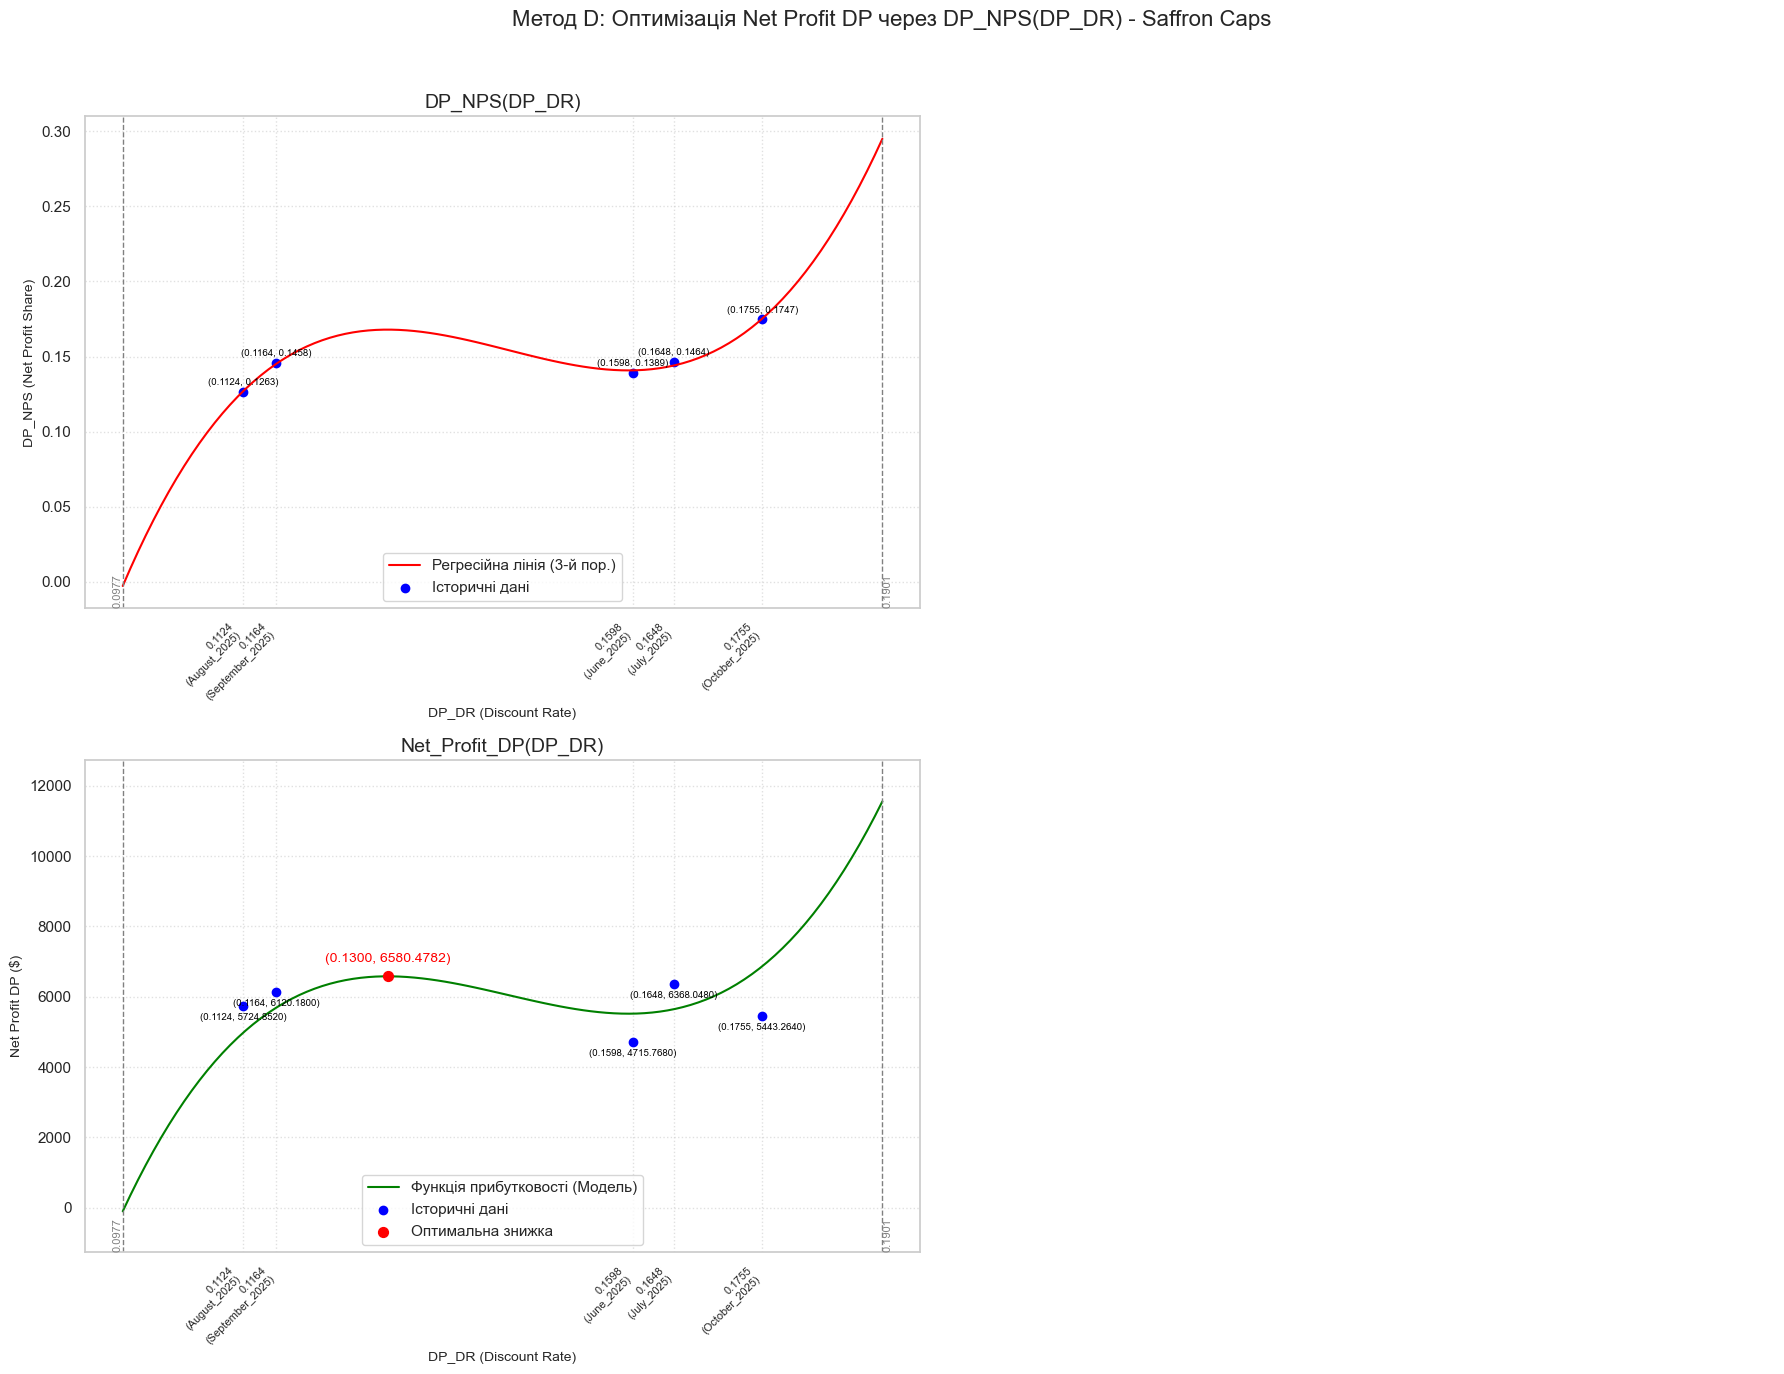

--- 6. СЕРВІСНА ІНФОРМАЦІЯ: РЕЗУЛЬТАТ ОПТИМІЗАЦІЇ ---
Оптимальна координата: (0.1300, 6580.4782)
Рекомендована знижка: 0.1300
Прогнозований профіт: 6580.4782
Похибка методу (MAPE): 0.1495
Похибка методу (RMSE): 888.2220
----------------------------------------------------------------------
--- 7. СЕРВІСНА ІНФОРМАЦІЯ: ЗБЕРЕЖЕННЯ ---
Успішний запис даних в ALL_METHODS_RESULTS:
- Saffron Caps - Method-D-DP_NPS - DP_DR: 0.1300
- Saffron Caps - Method-D-DP_NPS - MAPE: 0.1495
----------------------------------------------------------------------


In [7]:
# Встановлення глобальних налаштувань для форматування чисел (4 знаки після коми)
pd.options.display.float_format = '{:.4f}'.format
np.set_printoptions(formatter={'float': '{:.4f}'.format})


# --- 1. ДОПОМІЖНІ ФУНКЦІЇ (ПЕРЕВИКОРИСТАННЯ) ---

def calculate_r_squared(y_true, y_pred):
    """Розрахунок коефіцієнта детермінації R^2."""
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot) if ss_tot != 0 else 0

def format_poly_str(coefs):
    """Форматування коефіцієнтів полінома 3-го порядку у вигляд рядка."""
    power = len(coefs) - 1
    terms = []
    for c in coefs:
        c_fmt = f"{c:.4f}"
        
        if power == 3:
            term = f"{c_fmt}x^3"
        elif power == 2:
            term = f"{c_fmt}x^2"
        elif power == 1:
            term = f"{c_fmt}x"
        elif power == 0:
            term = f"{c_fmt}"
        else:
            term = ""
        
        if c > 0 and terms:
            terms.append("+" + term)
        elif c < 0:
            terms.append(term)
        elif c > 0 and not terms:
             terms.append(term)
        
        power -= 1
    
    return "".join(terms).lstrip('+').replace('+-', ' - ')

def calculate_mape(y_true, y_pred):
    """Розрахунок Середньої абсолютної відсоткової похибки (MAPE).
    Для коректного розрахунку враховуються лише позитивні історичні значення (y_true > 0).
    """
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    non_zero_indices = y_true > 0 
    
    if np.sum(non_zero_indices) == 0:
        return np.nan 

    mape = np.mean(np.abs((y_true[non_zero_indices] - y_pred[non_zero_indices]) / y_true[non_zero_indices]))
    return mape

def calculate_rmse(y_true, y_pred):
    """Розрахунок Кореневої середньоквадратичної похибки (RMSE)."""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

# --- 2. ПІДГОТОВКА ДАНИХ ТА РОЗРАХУНОК КОНСТАНТ ---

metrics_to_use_D = ['Net Profit_SP', 'Net Profit_DP', 'DP_DR'] # Дані з Кроку 1 та 2
df_method_D_temp = df_raw.loc[:, [col for col in metrics_to_use_D if col in df_raw.columns]].T.copy() 

# 2.1. Розрахунок Net_Profit_Total
df_method_D_temp.loc['Net_Profit_Total'] = df_method_D_temp.loc['Net Profit_SP'] + df_method_D_temp.loc['Net Profit_DP']

# 2.2. Розрахунок DP_NPS (Net Profit Share)
df_method_D_temp.loc['DP_NPS'] = np.where(
    df_method_D_temp.loc['Net_Profit_Total'] > 0,
    df_method_D_temp.loc['Net Profit_DP'] / df_method_D_temp.loc['Net_Profit_Total'],
    0.0
)

# Перейменування рядків та реіндексація
df_method_D = df_method_D_temp.rename(index={
    'Net Profit_SP': 'Net_Profit_SP', 
    'Net Profit_DP': 'Net_Profit_DP',
    'DP_DR': 'DP_DR'
}).reindex(index=['Net_Profit_SP', 'Net_Profit_DP', 'Net_Profit_Total', 'DP_DR', 'DP_NPS'])


# 2.3. Розрахунок Констант та Меж
dp_dr_series = df_method_D.loc['DP_DR'] # Незалежна змінна для меж
month_count = len(df_method_D.columns)

# Головна константа: Середній загальний прибуток (SP + DP)
Net_Profit_Total_Avg = df_method_D.loc['Net_Profit_Total'].mean()

# Межі для DP_DR (Min/Max +/- StDev)
St_Dev_DP_DR = 0.5 * dp_dr_series.std()
min_DP_DR = dp_dr_series.min()
max_DP_DR = dp_dr_series.max()

lower_bound_dr = max(0.0, min_DP_DR - St_Dev_DP_DR)
upper_bound_dr = max_DP_DR + St_Dev_DP_DR
def_Bound_DP_DR = [lower_bound_dr, upper_bound_dr]


# 2.4. ВИВІД ДАТАСЕТУ ТА СЕРВІСНОЇ ІНФОРМАЦІЇ
print(f"--- 1. ДАТАСЕТ ДЛЯ АНАЛІЗУ ---")
display(df_method_D.style.format('{:.4f}'))
print("-" * 70)

print("--- 2. СЕРВІСНА ІНФОРМАЦІЯ: РОЗРАХУНОК КОНСТАНТ ТА МЕЖ ---")
print(f"month_count: {month_count}")
# ОНОВЛЕНО: Тепер використовуємо Net_Profit_Total_Avg
print(f"Net_Profit_Total_Avg: {Net_Profit_Total_Avg:.4f}") 
print(f"St_Dev_DP_DR: {St_Dev_DP_DR:.4f}")
print(f"min_DP_DR: {min_DP_DR:.4f}")
print(f"max_DP_DR: {max_DP_DR:.4f}")
print(f"def_Bound_DP_DR: [{def_Bound_DP_DR[0]:.4f}; {def_Bound_DP_DR[1]:.4f}]")
print("-" * 70)


# --- 3. ПОБУДОВА РЕГРЕСІЇ ---
X = df_method_D.loc['DP_DR'].values # Незалежна змінна - DP_DR
X_month_labels = df_method_D.columns.values
Y_DP_NPS = df_method_D.loc['DP_NPS'].values # Залежна змінна - DP_NPS
Y_Net_Profit_DP_Actual = df_method_D.loc['Net_Profit_DP'].values # Історичний профіт
poly_order = 3 

# 3.1. DP_NPS(DP_DR)
coefs_nps = np.polyfit(X, Y_DP_NPS, poly_order); poly_nps = np.poly1d(coefs_nps)
r2_nps = calculate_r_squared(Y_DP_NPS, poly_nps(X)); poly_nps_str = format_poly_str(coefs_nps)
final_nps_func = poly_nps
nps_text = "DP_NPS(DP_DR)"

# 3.2. ВИВІД СЕРВІСНОЇ ІНФОРМАЦІЇ: РЕГРЕСІЯ ТА ФОРМУЛА
print("--- 3. СЕРВІСНА ІНФОРМАЦІЯ: РЕГРЕСІЯ 3-ГО ПОРЯДКУ ---")
print(f"Регресійний поліном DP_NPS(DP_DR) = {poly_nps_str}. Детермінація R_2 = {r2_nps:.4f}")
# ОНОВЛЕНО: Формула профітності
print(f"\nФормула прибутковості Net_Profit_DP = Net_Profit_Total_Avg * {nps_text}")
print("-" * 70)


# --- 4. ОПТИМІЗАЦІЯ ТА ОЦІНКА ПОХИБКИ ---

# 4.1. Визначення функції прибутковості (МОДЕЛЬ DP_NPS)
def net_profit_dp_func_D(dp_dr):
    # Net_Profit_DP = Net_Profit_Total_Avg * DP_NPS(DP_DR)
    return Net_Profit_Total_Avg * final_nps_func(dp_dr)

# 4.2. Оцінка похибки (порівняння прогнозу зі складеної моделі з історичним профітом)
Y_Net_Profit_DP_Predicted = net_profit_dp_func_D(X)
mape_error = calculate_mape(Y_Net_Profit_DP_Actual, Y_Net_Profit_DP_Predicted)
rmse_error = calculate_rmse(Y_Net_Profit_DP_Actual, Y_Net_Profit_DP_Predicted)


# 4.3. Оптимізація
optimization_result_D = minimize_scalar(
    lambda x: -net_profit_dp_func_D(x),
    bounds=def_Bound_DP_DR,
    method='bounded'
)

optimal_dp_dr = optimization_result_D.x
max_net_profit = -optimization_result_D.fun 


# --- 5. ГРАФІКИ ---

X_plot = np.linspace(def_Bound_DP_DR[0], def_Bound_DP_DR[1], 100)
Y_historical_np = Y_Net_Profit_DP_Actual
Y_function_np = net_profit_dp_func_D(X_plot) # МОДЕЛЬ DP_NPS

# Створення сітки 2x2
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle(f'Метод D: Оптимізація Net Profit DP через DP_NPS(DP_DR) - {product_name}', fontsize=16)
axes_flat = axes.flatten()

# Графіки регресії
plots_data = [
    # Перший графік: DP_NPS(DP_DR)
    {'ax_index': 0, 'Y_data': Y_DP_NPS, 'poly': poly_nps, 'title': 'DP_NPS(DP_DR)', 'y_label': 'DP_NPS (Net Profit Share)'},
    # Другий графік: Залишаємо порожнім або використовуємо для Net_Profit_Total
    # Для цього кроку, оскільки у нас лише одна регресія, розмістимо її у верхньому лівому куті (0)
]

min_bound, max_bound = def_Bound_DP_DR
x_padding = 0.05 * (max_bound - min_bound) 

# ІТЕРАЦІЯ ТА ПОБУДОВА ГРАФІКА DP_NPS(DP_DR) (0)
for i, plot_info in enumerate([plots_data[0]]): # Тільки перший графік (DP_NPS)
    ax = axes_flat[plot_info['ax_index']]
    Y_data = plot_info['Y_data']
    poly_func = plot_info['poly']
    
    # 1. Побудова лінії регресії
    ax.plot(X_plot, poly_func(X_plot), color='red', label='Регресійна лінія (3-й пор.)')
    # 2. Побудова історичних точок
    ax.scatter(X, Y_data, color='blue', marker='o', label='Історичні дані')
    
    # 3. Підпис історичних точок та координат
    for x_val, y_val in zip(X, Y_data):
        ax.annotate(f'({x_val:.4f}, {y_val:.4f})', (x_val, y_val), textcoords="offset points", 
                    xytext=(0, 5), ha='center', fontsize=7, color='black')

    # 4. Встановлення міток осі X
    ax.set_xticks(X)
    ax.set_xticklabels([f'{x:.4f}\n({m})' for x, m in zip(X, X_month_labels)], rotation=45, ha='right', fontsize=8)

    # *** Візуалізація меж def_Bound_DP_DR ***
    ax.axvline(x=min_bound, color='gray', linestyle='--', linewidth=1)
    ax.axvline(x=max_bound, color='gray', linestyle='--', linewidth=1)
    ax.set_xlim(min_bound - x_padding, max_bound + x_padding)
    
    y_min, y_max = ax.get_ylim()
    y_range = y_max - y_min
    
    # Числові значення меж
    ax.text(min_bound, y_min, f'{min_bound:.4f}', rotation=90, va='bottom', ha='right', fontsize=8, color='gray')
    ax.text(max_bound, y_min, f'{max_bound:.4f}', rotation=90, va='bottom', ha='left', fontsize=8, color='gray')
    
    ax.set_title(plot_info['title'], fontsize=14)
    ax.set_xlabel('DP_DR (Discount Rate)', fontsize=10)
    ax.set_ylabel(plot_info['y_label'], fontsize=10)
    ax.legend(loc='best')
    ax.grid(True, linestyle=':', alpha=0.6)

# Очищуємо другий (верхній правий) графік, він не потрібен
axes_flat[1].axis('off')

# 4.4. Графік функції прибутковості
ax_profit = axes_flat[2] # Розміщуємо на 3-му місці (нижній лівий)

# Крива функції прибутковості (МОДЕЛЬ DP_NPS)
ax_profit.plot(X_plot, Y_function_np, color='green', label='Функція прибутковості (Модель)')
# Історичні точки
ax_profit.scatter(X, Y_historical_np, color='blue', marker='o', label='Історичні дані') 
# Точка максимального прибутку
ax_profit.scatter(optimal_dp_dr, max_net_profit, color='red', s=50, zorder=5, label='Оптимальна знижка')

# Підпис оптимальної точки
optimal_coords = (optimal_dp_dr, max_net_profit)
ax_profit.annotate(f'({optimal_dp_dr:.4f}, {max_net_profit:.4f})', 
            optimal_coords, textcoords="offset points", xytext=(0, 10), ha='center', fontsize=10, color='red')

# Підписи історичних точок
for x_val, y_val in zip(X, Y_historical_np):
    ax_profit.annotate(f'({x_val:.4f}, {y_val:.4f})', (x_val, y_val), textcoords="offset points", 
                 xytext=(0, -10), ha='center', fontsize=7, color='black')

# Підпис меж оптимізації
ax_profit.axvline(x=min_bound, color='gray', linestyle='--', linewidth=1)
ax_profit.axvline(x=max_bound, color='gray', linestyle='--', linewidth=1)

# Встановлення меж Y для графіка профіту
y_min_hist = Y_historical_np.min()
y_max_hist = Y_historical_np.max()
y_min_func = Y_function_np.min()
y_max_func = Y_function_np.max()
y_min_plot = min(y_min_hist, y_min_func)
y_max_plot = max(y_max_hist, y_max_func)
y_range_plot = y_max_plot - y_min_plot

ax_profit.set_ylim(y_min_plot - y_range_plot * 0.1, y_max_plot + y_range_plot * 0.1)

# Підписи числових значень меж
y_min_profit, y_max_profit = ax_profit.get_ylim()
y_range_profit = y_max_profit - y_min_profit

ax_profit.text(min_bound, y_min_profit, f'{min_bound:.4f}', rotation=90, va='bottom', ha='right', fontsize=8, color='gray')
ax_profit.text(max_bound, y_min_profit, f'{max_bound:.4f}', rotation=90, va='bottom', ha='left', fontsize=8, color='gray')

# Встановлення міток осі X та меж
ax_profit.set_xticks(X)
ax_profit.set_xticklabels([f'{x:.4f}\n({m})' for x, m in zip(X, X_month_labels)], rotation=45, ha='right', fontsize=8)
ax_profit.set_xlim(min_bound - x_padding, max_bound + x_padding) 

ax_profit.set_title('Net_Profit_DP(DP_DR)', fontsize=14)
ax_profit.set_xlabel('DP_DR (Discount Rate)', fontsize=10)
ax_profit.set_ylabel('Net Profit DP ($)', fontsize=10)
ax_profit.legend(loc='best')
ax_profit.grid(True, linestyle=':', alpha=0.6)

# Очищуємо четвертий (нижній правий) графік
axes_flat[3].axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


# --- 6. ФІНАЛЬНИЙ ВИВІД ТА ЗБЕРЕЖЕННЯ ---
print("--- 6. СЕРВІСНА ІНФОРМАЦІЯ: РЕЗУЛЬТАТ ОПТИМІЗАЦІЇ ---")
print(f"Оптимальна координата: ({optimal_dp_dr:.4f}, {max_net_profit:.4f})")
print(f"Рекомендована знижка: {optimal_dp_dr:.4f}")
print(f"Прогнозований профіт: {max_net_profit:.4f}")
# НОВОВВЕДЕННЯ: Додано вивід похибок
print(f"Похибка методу (MAPE): {mape_error:.4f}")
print(f"Похибка методу (RMSE): {rmse_error:.4f}")
print("-" * 70)

# Збереження результату
method_key = "Method-D-DP_NPS" 
save_success = False

if 'ALL_METHODS_RESULTS' in globals():
    # НОВОВВЕДЕННЯ: Збереження DP_DR та MAPE
    ALL_METHODS_RESULTS[f"{product_name} - {method_key} - DP_DR"] = optimal_dp_dr
    ALL_METHODS_RESULTS[f"{product_name} - {method_key} - MAPE"] = mape_error
    save_success = True
    
print("--- 7. СЕРВІСНА ІНФОРМАЦІЯ: ЗБЕРЕЖЕННЯ ---")
if save_success:
    print(f"Успішний запис даних в ALL_METHODS_RESULTS:")
    print(f"- {product_name} - {method_key} - DP_DR: {optimal_dp_dr:.4f}")
    print(f"- {product_name} - {method_key} - MAPE: {mape_error:.4f}")
else:
    print(f"Помилка: Словник ALL_METHODS_RESULTS не визначено. Будь ласка, визначте його на початку ноутбука (ALL_METHODS_RESULTS = {{}}) для збереження результатів.")
print("-" * 70)

### КРОК 7: Метод-E-DP_NPPS

#### Ключові показники та Формула прибутковості

| Змінна/Показник | Розшифровка | Формула / Модель |
| :--- | :--- | :--- |
| **$DP\_NPPS$** | Net Profit Per Session DP (Чистий прибуток на одну сесію DP) | $\text{DP\_NPPS} = \frac{\text{Net\_Profit\_DP}}{\text{Sessions\_DP}}$ |
| **$DP\_DR$** | Discount Rate (Коефіцієнт знижки) | $\text{DP\_DR}$ **(Незалежна змінна)** |
| **$Sessions\_DP\_Avg$**| Середня історична кількість сесій DP | $\text{Sessions\_DP\_Avg} = \text{MEAN}(\text{Sessions\_DP})$ |
| **$Net\_Profit\_DP$** | Чистий прибуток Double Pack (функція оптимізації) | $$\text{Net\_Profit\_DP} = \mathbf{Sessions\_DP\_Avg} \times \mathbf{DP\_NPPS}(\text{DP\_DR})$$ |

<details>
<summary><b>Алгоритм виконання розрахунків (Стисло)</b></summary>
<br>

Алгоритм виконує оптимізацію знижки ($DP\_DR$) для максимізації чистого прибутку ($Net\_Profit\_DP$) на основі моделювання прибутковості трафіку:

1.  **Розрахунок Констант:** Обчислюється ключова константа $\text{Sessions\_DP\_Avg}$ та межі оптимізації $\text{def\_Bound\_DP\_DR}$.
2.  **Побудова Регресії:** Будується поліноміальна регресія **3-го порядку** для $\mathbf{DP\_NPPS}(\text{DP\_DR})$.
3.  **Складена Функція Профіту:** Використовується наведена вище формула, де $\mathbf{DP\_NPPS}(\text{DP\_DR})$ є регресійною функцією, а $\text{Sessions\_DP\_Avg}$ — константа.
4.  **Оптимізація:** За допомогою функції $\text{minimize\_scalar}$ шукається $\text{optimal\_dp\_dr}$, який максимізує $\text{Net\_Profit\_DP}$ у межах $\text{def\_Bound\_DP\_DR}$.
5.  **Оцінка Якості:** Розраховується **$\text{MAPE}$** та **$\text{RMSE}$** шляхом порівняння значень $\text{Net\_Profit\_DP}$ моделі з історичними даними.
6.  **Звітність:** Виводяться графіки та кінцевий результат ($\text{optimal\_dp\_dr}$) та метрики якості моделі ($\text{MAPE}, \text{RMSE}$).

</details>

--- 1. ДАТАСЕТ ДЛЯ АНАЛІЗУ ---


Month_Year,June_2025,July_2025,August_2025,September_2025,October_2025
Metric,,,,,
Net_Profit_DP,4715.7680,6368.0480,5724.8520,6120.1800,5443.2640
Sessions_DP,835.0000,1090.0000,1073.0000,1029.0000,807.0000
DP_DR,0.1598,0.1648,0.1124,0.1164,0.1755
DP_NPPS,5.6476,5.8422,5.3354,5.9477,6.7451


----------------------------------------------------------------------
--- 2. СЕРВІСНА ІНФОРМАЦІЯ: РОЗРАХУНОК КОНСТАНТ ТА МЕЖ ---
month_count: 5
Sessions_DP_Avg: 966.8000
St_Dev_DP_DR: 0.0146
min_DP_DR: 0.1124
max_DP_DR: 0.1755
def_Bound_DP_DR: [0.0977; 0.1901]
----------------------------------------------------------------------
--- 3. СЕРВІСНА ІНФОРМАЦІЯ: РЕГРЕСІЯ 3-ГО ПОРЯДКУ ---
Регресійний поліном DP_NPPS(DP_DR) = 69745.9559x^3-30268.2689x^2+4331.3102x-198.1256. Детермінація R_2 = 0.9945

Формула прибутковості Net_Profit_DP = Sessions_DP_Avg * DP_NPPS(DP_DR)
----------------------------------------------------------------------


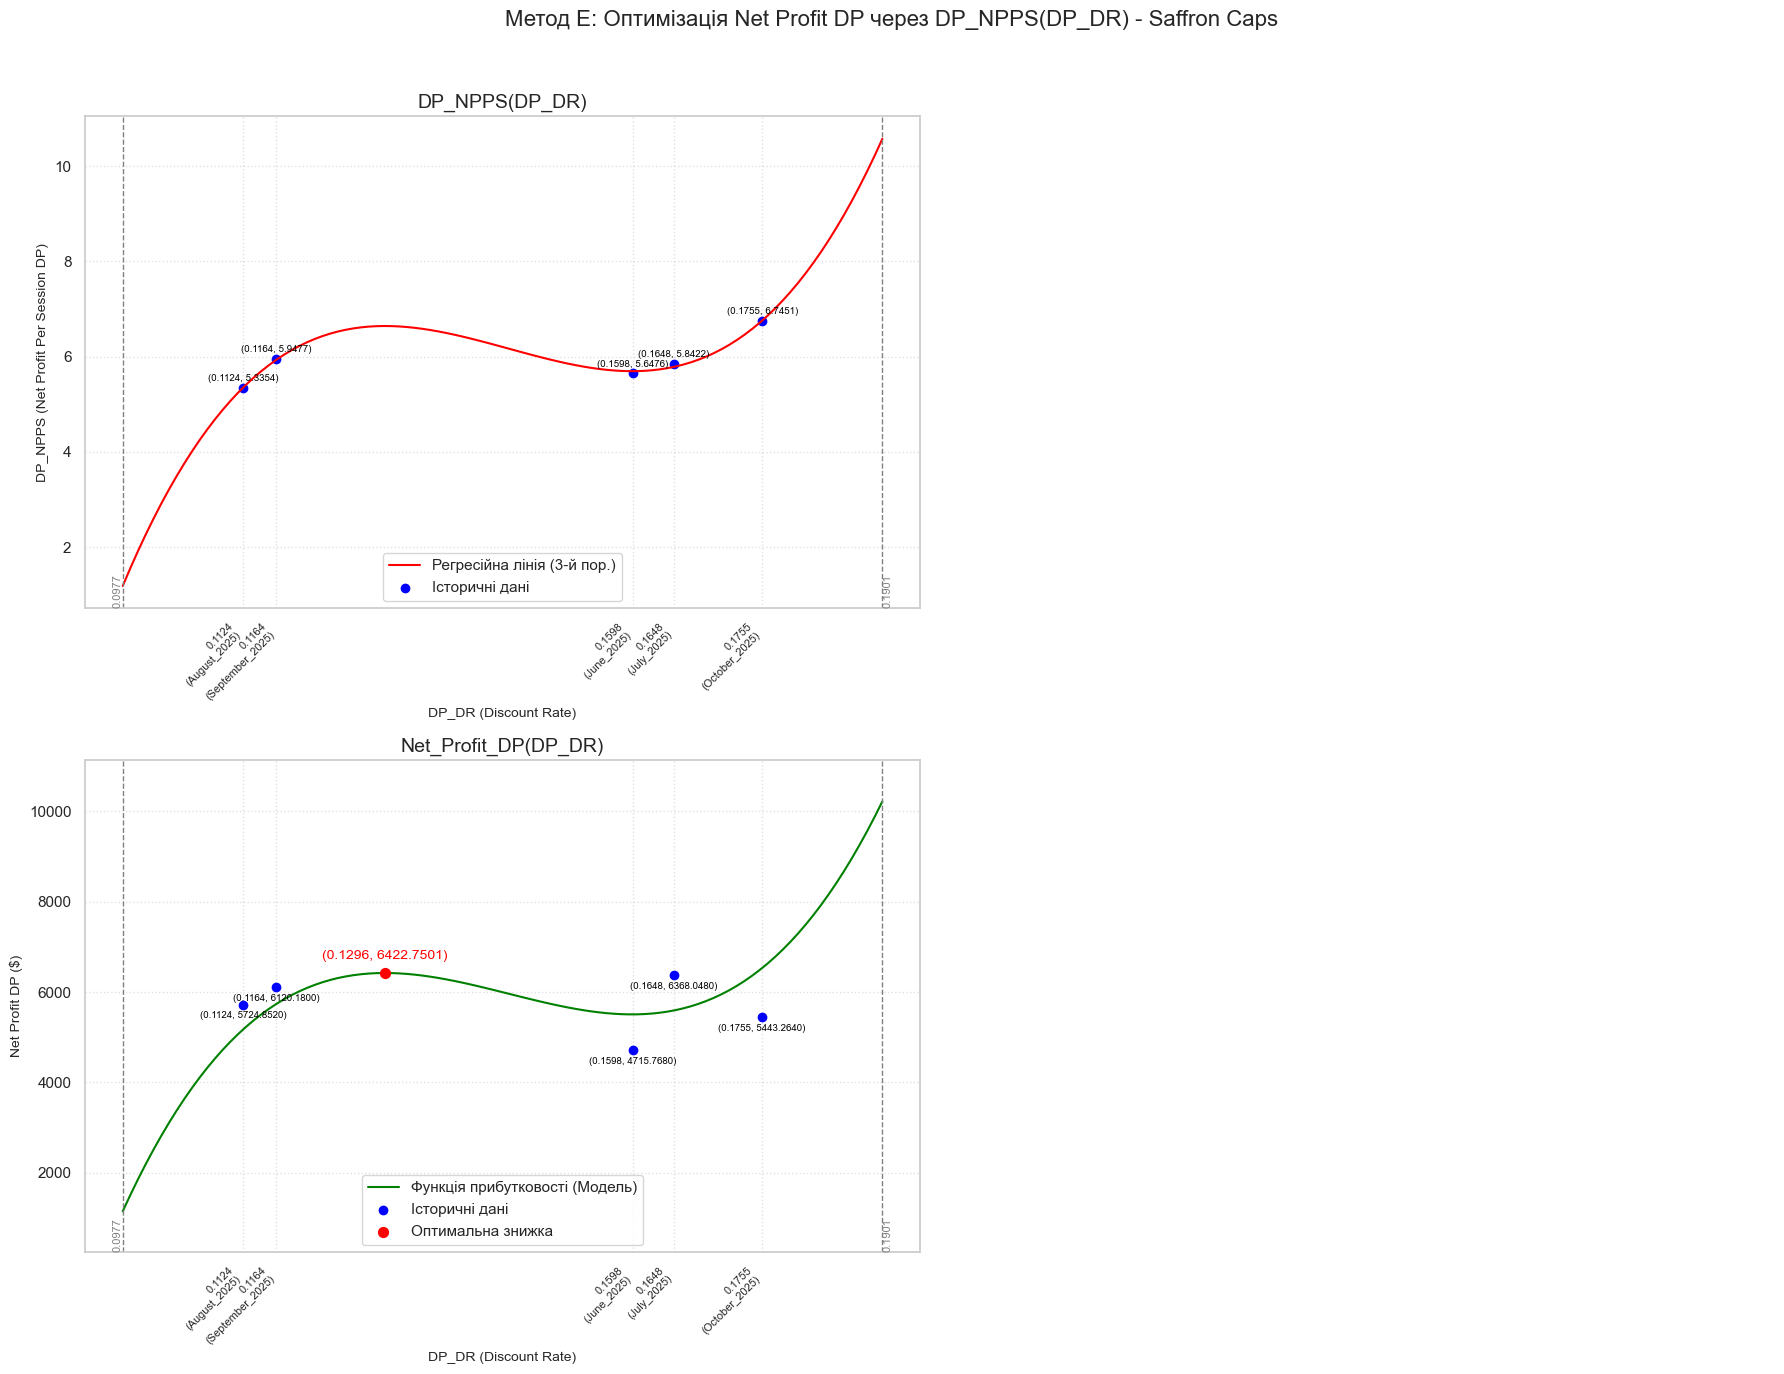

--- 6. СЕРВІСНА ІНФОРМАЦІЯ: РЕЗУЛЬТАТ ОПТИМІЗАЦІЇ ---
Оптимальна координата: (0.1296, 6422.7501)
Рекомендована знижка: 0.1296
Прогнозований профіт: 6422.7501
Похибка методу (MAPE): 0.1299
Похибка методу (RMSE): 757.4744
----------------------------------------------------------------------
--- 7. СЕРВІСНА ІНФОРМАЦІЯ: ЗБЕРЕЖЕННЯ ---
Успішний запис даних в ALL_METHODS_RESULTS:
- Saffron Caps - Method-E-DP_NPPS - DP_DR: 0.1296
- Saffron Caps - Method-E-DP_NPPS - MAPE: 0.1299
----------------------------------------------------------------------


In [8]:
# Встановлення глобальних налаштувань для форматування чисел (4 знаки після коми)
pd.options.display.float_format = '{:.4f}'.format
np.set_printoptions(formatter={'float': '{:.4f}'.format})


# --- 1. ДОПОМІЖНІ ФУНКЦІЇ (ПЕРЕВИКОРИСТАННЯ) ---

def calculate_r_squared(y_true, y_pred):
    """Розрахунок коефіцієнта детермінації R^2."""
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot) if ss_tot != 0 else 0

def format_poly_str(coefs):
    """Форматування коефіцієнтів полінома 3-го порядку у вигляд рядка."""
    power = len(coefs) - 1
    terms = []
    for c in coefs:
        c_fmt = f"{c:.4f}"
        
        if power == 3:
            term = f"{c_fmt}x^3"
        elif power == 2:
            term = f"{c_fmt}x^2"
        elif power == 1:
            term = f"{c_fmt}x"
        elif power == 0:
            term = f"{c_fmt}"
        else:
            term = ""
        
        if c > 0 and terms:
            terms.append("+" + term)
        elif c < 0:
            terms.append(term)
        elif c > 0 and not terms:
             terms.append(term)
        
        power -= 1
    
    return "".join(terms).lstrip('+').replace('+-', ' - ')

def calculate_mape(y_true, y_pred):
    """Розрахунок Середньої абсолютної відсоткової похибки (MAPE).
    Для коректного розрахунку враховуються лише позитивні історичні значення (y_true > 0).
    """
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    non_zero_indices = y_true > 0 
    
    if np.sum(non_zero_indices) == 0:
        return np.nan 

    mape = np.mean(np.abs((y_true[non_zero_indices] - y_pred[non_zero_indices]) / y_true[non_zero_indices]))
    return mape

def calculate_rmse(y_true, y_pred):
    """Розрахунок Кореневої середньоквадратичної похибки (RMSE)."""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

# --- 2. ПІДГОТОВКА ДАНИХ ТА РОЗРАХУНОК КОНСТАНТ ---

metrics_to_use_E = ['Net Profit_DP', 'Sessions_DP', 'DP_DR'] # Необхідні дані
df_method_E_temp = df_raw.loc[:, [col for col in metrics_to_use_E if col in df_raw.columns]].T.copy() 

# 2.1. Розрахунок DP_NPPS (Net Profit Per Session DP)
df_method_E_temp.loc['DP_NPPS'] = np.where(
    df_method_E_temp.loc['Sessions_DP'] > 0,
    df_method_E_temp.loc['Net Profit_DP'] / df_method_E_temp.loc['Sessions_DP'],
    0.0
)

# Перейменування рядків та реіндексація
df_method_E = df_method_E_temp.rename(index={
    'Net Profit_DP': 'Net_Profit_DP', 
    'Sessions_DP': 'Sessions_DP',
    'DP_DR': 'DP_DR'
}).reindex(index=['Net_Profit_DP', 'Sessions_DP', 'DP_DR', 'DP_NPPS'])


# 2.2. Розрахунок Констант та Меж
dp_dr_series = df_method_E.loc['DP_DR'] # Незалежна змінна для меж
month_count = len(df_method_E.columns)

# Головна константа: Середня кількість сесій DP
Sessions_DP_Avg = df_method_E.loc['Sessions_DP'].mean()

# Межі для DP_DR (Min/Max +/- StDev)
St_Dev_DP_DR = 0.5 * dp_dr_series.std()
min_DP_DR = dp_dr_series.min()
max_DP_DR = dp_dr_series.max()

lower_bound_dr = max(0.0, min_DP_DR - St_Dev_DP_DR)
upper_bound_dr = max_DP_DR + St_Dev_DP_DR
def_Bound_DP_DR = [lower_bound_dr, upper_bound_dr]


# 2.3. ВИВІД ДАТАСЕТУ ТА СЕРВІСНОЇ ІНФОРМАЦІЇ
print(f"--- 1. ДАТАСЕТ ДЛЯ АНАЛІЗУ ---")
display(df_method_E.style.format('{:.4f}'))
print("-" * 70)

print("--- 2. СЕРВІСНА ІНФОРМАЦІЯ: РОЗРАХУНОК КОНСТАНТ ТА МЕЖ ---")
print(f"month_count: {month_count}")
# Ключова константа
print(f"Sessions_DP_Avg: {Sessions_DP_Avg:.4f}") 
print(f"St_Dev_DP_DR: {St_Dev_DP_DR:.4f}")
print(f"min_DP_DR: {min_DP_DR:.4f}")
print(f"max_DP_DR: {max_DP_DR:.4f}")
print(f"def_Bound_DP_DR: [{def_Bound_DP_DR[0]:.4f}; {def_Bound_DP_DR[1]:.4f}]")
print("-" * 70)


# --- 3. ПОБУДОВА РЕГРЕСІЇ ---
X = df_method_E.loc['DP_DR'].values # Незалежна змінна - DP_DR
X_month_labels = df_method_E.columns.values
Y_DP_NPPS = df_method_E.loc['DP_NPPS'].values # Залежна змінна - DP_NPPS
Y_Net_Profit_DP_Actual = df_method_E.loc['Net_Profit_DP'].values # Історичний профіт
poly_order = 3 

# 3.1. DP_NPPS(DP_DR)
coefs_npps = np.polyfit(X, Y_DP_NPPS, poly_order); poly_npps = np.poly1d(coefs_npps)
r2_npps = calculate_r_squared(Y_DP_NPPS, poly_npps(X)); poly_npps_str = format_poly_str(coefs_npps)
final_npps_func = poly_npps
npps_text = "DP_NPPS(DP_DR)"

# 3.2. ВИВІД СЕРВІСНОЇ ІНФОРМАЦІЇ: РЕГРЕСІЯ ТА ФОРМУЛА
print("--- 3. СЕРВІСНА ІНФОРМАЦІЯ: РЕГРЕСІЯ 3-ГО ПОРЯДКУ ---")
print(f"Регресійний поліном DP_NPPS(DP_DR) = {poly_npps_str}. Детермінація R_2 = {r2_npps:.4f}")
# ОНОВЛЕНО: Формула профітності
print(f"\nФормула прибутковості Net_Profit_DP = Sessions_DP_Avg * {npps_text}")
print("-" * 70)


# --- 4. ОПТИМІЗАЦІЯ ТА ОЦІНКА ПОХИБКИ ---

# 4.1. Визначення функції прибутковості (МОДЕЛЬ DP_NPPS)
def net_profit_dp_func_E(dp_dr):
    # Net_Profit_DP = Sessions_DP_Avg * DP_NPPS(DP_DR)
    return Sessions_DP_Avg * final_npps_func(dp_dr)

# 4.2. Оцінка похибки (порівняння прогнозу зі складеної моделі з історичним профітом)
Y_Net_Profit_DP_Predicted = net_profit_dp_func_E(X)
mape_error = calculate_mape(Y_Net_Profit_DP_Actual, Y_Net_Profit_DP_Predicted)
rmse_error = calculate_rmse(Y_Net_Profit_DP_Actual, Y_Net_Profit_DP_Predicted)


# 4.3. Оптимізація
optimization_result_E = minimize_scalar(
    lambda x: -net_profit_dp_func_E(x),
    bounds=def_Bound_DP_DR,
    method='bounded'
)

optimal_dp_dr = optimization_result_E.x
max_net_profit = -optimization_result_E.fun 


# --- 5. ГРАФІКИ ---

X_plot = np.linspace(def_Bound_DP_DR[0], def_Bound_DP_DR[1], 100)
Y_historical_np = Y_Net_Profit_DP_Actual
Y_function_np = net_profit_dp_func_E(X_plot) # МОДЕЛЬ DP_NPPS

# Створення сітки 2x2
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle(f'Метод E: Оптимізація Net Profit DP через DP_NPPS(DP_DR) - {product_name}', fontsize=16)
axes_flat = axes.flatten()

# Графіки регресії
plots_data = [
    # Перший графік: DP_NPPS(DP_DR)
    {'ax_index': 0, 'Y_data': Y_DP_NPPS, 'poly': poly_npps, 'title': 'DP_NPPS(DP_DR)', 'y_label': 'DP_NPPS (Net Profit Per Session DP)'},
]

min_bound, max_bound = def_Bound_DP_DR
x_padding = 0.05 * (max_bound - min_bound) 

# ІТЕРАЦІЯ ТА ПОБУДОВА ГРАФІКА DP_NPPS(DP_DR) (0)
for i, plot_info in enumerate([plots_data[0]]): # Тільки перший графік (DP_NPPS)
    ax = axes_flat[plot_info['ax_index']]
    Y_data = plot_info['Y_data']
    poly_func = plot_info['poly']
    
    # 1. Побудова лінії регресії
    ax.plot(X_plot, poly_func(X_plot), color='red', label='Регресійна лінія (3-й пор.)')
    # 2. Побудова історичних точок
    ax.scatter(X, Y_data, color='blue', marker='o', label='Історичні дані')
    
    # 3. Підпис історичних точок та координат
    for x_val, y_val in zip(X, Y_data):
        ax.annotate(f'({x_val:.4f}, {y_val:.4f})', (x_val, y_val), textcoords="offset points", 
                    xytext=(0, 5), ha='center', fontsize=7, color='black')

    # 4. Встановлення міток осі X
    ax.set_xticks(X)
    ax.set_xticklabels([f'{x:.4f}\n({m})' for x, m in zip(X, X_month_labels)], rotation=45, ha='right', fontsize=8)

    # *** Візуалізація меж def_Bound_DP_DR ***
    ax.axvline(x=min_bound, color='gray', linestyle='--', linewidth=1)
    ax.axvline(x=max_bound, color='gray', linestyle='--', linewidth=1)
    ax.set_xlim(min_bound - x_padding, max_bound + x_padding)
    
    y_min, y_max = ax.get_ylim()
    y_range = y_max - y_min
    
    # Числові значення меж
    ax.text(min_bound, y_min, f'{min_bound:.4f}', rotation=90, va='bottom', ha='right', fontsize=8, color='gray')
    ax.text(max_bound, y_min, f'{max_bound:.4f}', rotation=90, va='bottom', ha='left', fontsize=8, color='gray')
    
    ax.set_title(plot_info['title'], fontsize=14)
    ax.set_xlabel('DP_DR (Discount Rate)', fontsize=10)
    ax.set_ylabel(plot_info['y_label'], fontsize=10)
    ax.legend(loc='best')
    ax.grid(True, linestyle=':', alpha=0.6)

# Очищуємо другий (верхній правий) графік, він не потрібен
axes_flat[1].axis('off')

# 4.4. Графік функції прибутковості
ax_profit = axes_flat[2] # Розміщуємо на 3-му місці (нижній лівий)

# Крива функції прибутковості (МОДЕЛЬ DP_NPPS)
ax_profit.plot(X_plot, Y_function_np, color='green', label='Функція прибутковості (Модель)')
# Історичні точки
ax_profit.scatter(X, Y_historical_np, color='blue', marker='o', label='Історичні дані') 
# Точка максимального прибутку
ax_profit.scatter(optimal_dp_dr, max_net_profit, color='red', s=50, zorder=5, label='Оптимальна знижка')

# Підпис оптимальної точки
optimal_coords = (optimal_dp_dr, max_net_profit)
ax_profit.annotate(f'({optimal_dp_dr:.4f}, {max_net_profit:.4f})', 
            optimal_coords, textcoords="offset points", xytext=(0, 10), ha='center', fontsize=10, color='red')

# Підписи історичних точок
for x_val, y_val in zip(X, Y_historical_np):
    ax_profit.annotate(f'({x_val:.4f}, {y_val:.4f})', (x_val, y_val), textcoords="offset points", 
                 xytext=(0, -10), ha='center', fontsize=7, color='black')

# Підпис меж оптимізації
ax_profit.axvline(x=min_bound, color='gray', linestyle='--', linewidth=1)
ax_profit.axvline(x=max_bound, color='gray', linestyle='--', linewidth=1)

# Встановлення меж Y для графіка профіту
y_min_hist = Y_historical_np.min()
y_max_hist = Y_historical_np.max()
y_min_func = Y_function_np.min()
y_max_func = Y_function_np.max()
y_min_plot = min(y_min_hist, y_min_func)
y_max_plot = max(y_max_hist, y_max_func)
y_range_plot = y_max_plot - y_min_plot

ax_profit.set_ylim(y_min_plot - y_range_plot * 0.1, y_max_plot + y_range_plot * 0.1)

# Підписи числових значень меж
y_min_profit, y_max_profit = ax_profit.get_ylim()
y_range_profit = y_max_profit - y_min_profit

ax_profit.text(min_bound, y_min_profit, f'{min_bound:.4f}', rotation=90, va='bottom', ha='right', fontsize=8, color='gray')
ax_profit.text(max_bound, y_min_profit, f'{max_bound:.4f}', rotation=90, va='bottom', ha='left', fontsize=8, color='gray')

# Встановлення міток осі X та меж
ax_profit.set_xticks(X)
ax_profit.set_xticklabels([f'{x:.4f}\n({m})' for x, m in zip(X, X_month_labels)], rotation=45, ha='right', fontsize=8)
ax_profit.set_xlim(min_bound - x_padding, max_bound + x_padding) 

ax_profit.set_title('Net_Profit_DP(DP_DR)', fontsize=14)
ax_profit.set_xlabel('DP_DR (Discount Rate)', fontsize=10)
ax_profit.set_ylabel('Net Profit DP ($)', fontsize=10)
ax_profit.legend(loc='best')
ax_profit.grid(True, linestyle=':', alpha=0.6)

# Очищуємо четвертий (нижній правий) графік
axes_flat[3].axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


# --- 6. ФІНАЛЬНИЙ ВИВІД ТА ЗБЕРЕЖЕННЯ ---
print("--- 6. СЕРВІСНА ІНФОРМАЦІЯ: РЕЗУЛЬТАТ ОПТИМІЗАЦІЇ ---")
print(f"Оптимальна координата: ({optimal_dp_dr:.4f}, {max_net_profit:.4f})")
print(f"Рекомендована знижка: {optimal_dp_dr:.4f}")
print(f"Прогнозований профіт: {max_net_profit:.4f}")
# НОВОВВЕДЕННЯ: Додано вивід похибок
print(f"Похибка методу (MAPE): {mape_error:.4f}")
print(f"Похибка методу (RMSE): {rmse_error:.4f}")
print("-" * 70)

# Збереження результату
method_key = "Method-E-DP_NPPS" 
save_success = False

if 'ALL_METHODS_RESULTS' in globals():
    # НОВОВВЕДЕННЯ: Збереження DP_DR та MAPE
    ALL_METHODS_RESULTS[f"{product_name} - {method_key} - DP_DR"] = optimal_dp_dr
    ALL_METHODS_RESULTS[f"{product_name} - {method_key} - MAPE"] = mape_error
    save_success = True
    
print("--- 7. СЕРВІСНА ІНФОРМАЦІЯ: ЗБЕРЕЖЕННЯ ---")
if save_success:
    print(f"Успішний запис даних в ALL_METHODS_RESULTS:")
    print(f"- {product_name} - {method_key} - DP_DR: {optimal_dp_dr:.4f}")
    print(f"- {product_name} - {method_key} - MAPE: {mape_error:.4f}")
else:
    print(f"Помилка: Словник ALL_METHODS_RESULTS не визначено. Будь ласка, визначте його на початку ноутбука (ALL_METHODS_RESULTS = {{}}) для збереження результатів.")
print("-" * 70)

### КРОК 8: Метод-F-DP_CSPPS

#### Ключові показники та Формула прибутковості

| Змінна/Показник | Розшифровка | Формула / Модель |
| :--- | :--- | :--- |
| **$DP\_CSPPS$** | Cross-Sell Profit Per Session SP (Чистий прибуток DP на одну сесію SP) | $\text{DP\_CSPPS} = \frac{\text{Net\_Profit\_DP}}{\text{Sessions\_SP}}$ |
| **$DP\_DR$** | Discount Rate (Коефіцієнт знижки) | $\text{DP\_DR}$ **(Незалежна змінна)** |
| **$Sessions\_SP\_Avg$**| Середня історична кількість сесій SP | $\text{Sessions\_SP\_Avg} = \text{MEAN}(\text{Sessions\_SP})$ |
| **$Net\_Profit\_DP$** | Чистий прибуток Double Pack (функція оптимізації) | $$\text{Net\_Profit\_DP} = \mathbf{Sessions\_SP\_Avg} \times \mathbf{DP\_CSPPS}(\text{DP\_DR})$$ |

<details>
<summary><b>Алгоритм виконання розрахунків (Стисло)</b></summary>
<br>

Алгоритм виконує оптимізацію знижки ($DP\_DR$) для максимізації чистого прибутку ($Net\_Profit\_DP$) на основі моделювання ефективності крос-продажів:

1.  **Розрахунок Констант:** Обчислюється ключова константа $\text{Sessions\_SP\_Avg}$ та межі оптимізації $\text{def\_Bound\_DP\_DR}$.
2.  **Побудова Регресії:** Будується поліноміальна регресія **3-го порядку** для $\mathbf{DP\_CSPPS}(\text{DP\_DR})$.
3.  **Складена Функція Профіту:** Використовується наведена вище формула, де $\mathbf{DP\_CSPPS}(\text{DP\_DR})$ є регресійною функцією, а $\text{Sessions\_SP\_Avg}$ — константа.
4.  **Оптимізація:** За допомогою функції $\text{minimize\_scalar}$ шукається $\text{optimal\_dp\_dr}$, який максимізує $\text{Net\_Profit\_DP}$ у межах $\text{def\_Bound\_DP\_DR}$.
5.  **Оцінка Якості:** Розраховується **$\text{MAPE}$** та **$\text{RMSE}$** шляхом порівняння значень $\text{Net\_Profit\_DP}$ моделі з історичними даними.
6.  **Звітність:** Виводяться графіки та кінцевий результат ($\text{optimal\_dp\_dr}$) та метрики якості моделі ($\text{MAPE}, \text{RMSE}$).

</details>

--- 1. ДАТАСЕТ ДЛЯ АНАЛІЗУ ---


Month_Year,June_2025,July_2025,August_2025,September_2025,October_2025
Metric,,,,,
Net_Profit_DP,4715.7680,6368.0480,5724.8520,6120.1800,5443.2640
Sessions_SP,13303.0000,16320.0000,19604.0000,17071.0000,8783.0000
DP_DR,0.1598,0.1648,0.1124,0.1164,0.1755
DP_CSPPS,0.3545,0.3902,0.2920,0.3585,0.6197


----------------------------------------------------------------------
--- 2. СЕРВІСНА ІНФОРМАЦІЯ: РОЗРАХУНОК КОНСТАНТ ТА МЕЖ ---
month_count: 5
Sessions_SP_Avg: 15016.2000
St_Dev_DP_DR: 0.0146
min_DP_DR: 0.1124
max_DP_DR: 0.1755
def_Bound_DP_DR: [0.0977; 0.1901]
----------------------------------------------------------------------
--- 3. СЕРВІСНА ІНФОРМАЦІЯ: РЕГРЕСІЯ 3-ГО ПОРЯДКУ ---
Регресійний поліном DP_CSPPS(DP_DR) = 10319.0442x^3-4369.8097x^2+611.4969x-27.8866. Детермінація R_2 = 0.9996

Формула прибутковості Net_Profit_DP = Sessions_SP_Avg * DP_CSPPS(DP_DR)
----------------------------------------------------------------------


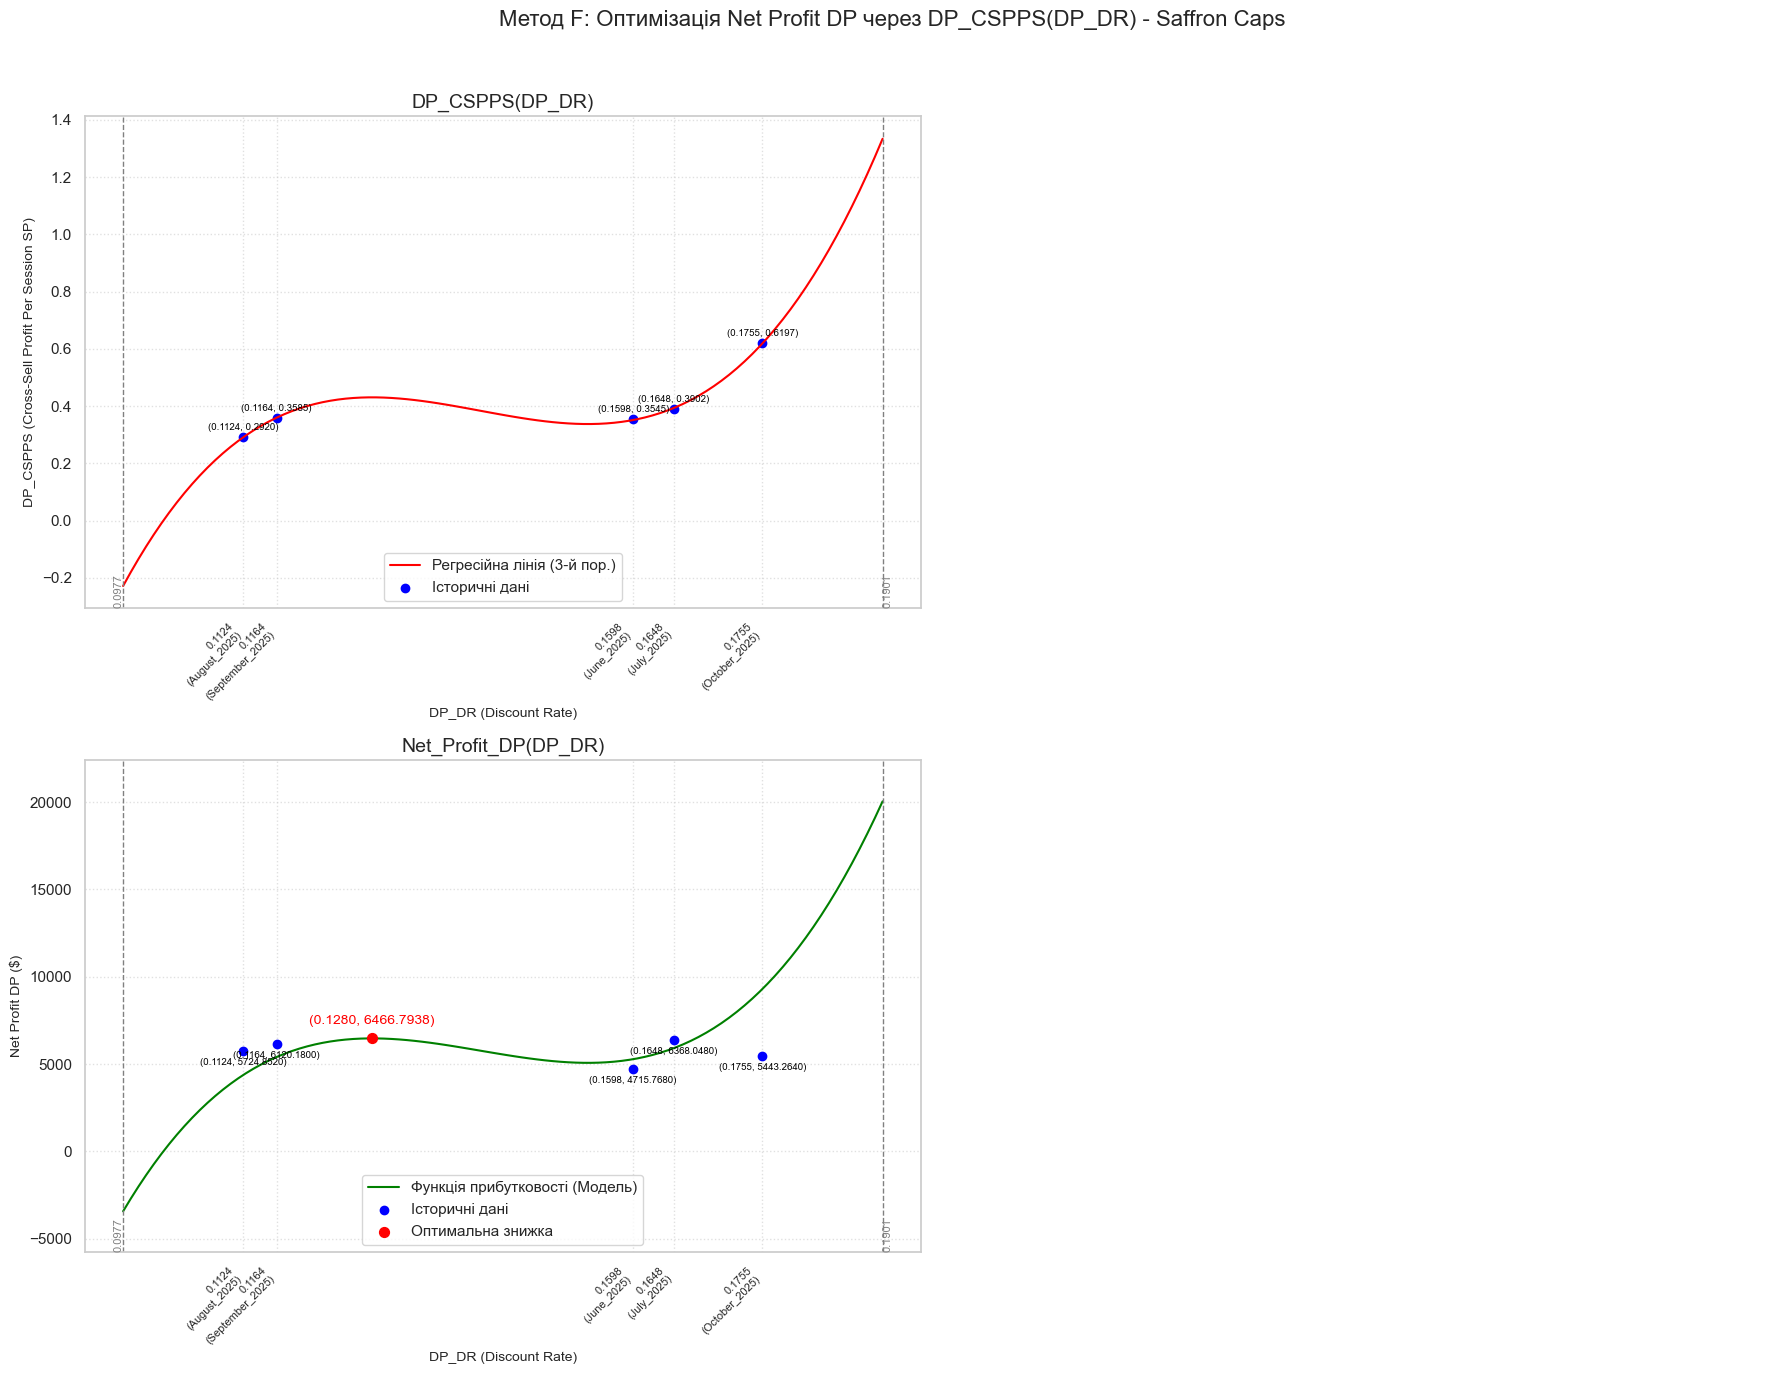

--- 6. СЕРВІСНА ІНФОРМАЦІЯ: РЕЗУЛЬТАТ ОПТИМІЗАЦІЇ ---
Оптимальна координата: (0.1280, 6466.7938)
Рекомендована знижка: 0.1280
Прогнозований профіт: 6466.7938
Похибка методу (MAPE): 0.2504
Похибка методу (RMSE): 1881.5048
----------------------------------------------------------------------
--- 7. СЕРВІСНА ІНФОРМАЦІЯ: ЗБЕРЕЖЕННЯ ---
Успішний запис даних в ALL_METHODS_RESULTS:
- Saffron Caps - Method-F-DP_CSPPS - DP_DR: 0.1280
- Saffron Caps - Method-F-DP_CSPPS - MAPE: 0.2504
----------------------------------------------------------------------


In [9]:
# Встановлення глобальних налаштувань для форматування чисел (4 знаки після коми)
pd.options.display.float_format = '{:.4f}'.format
np.set_printoptions(formatter={'float': '{:.4f}'.format})


# --- 1. ДОПОМІЖНІ ФУНКЦІЇ (ПЕРЕВИКОРИСТАННЯ) ---

def calculate_r_squared(y_true, y_pred):
    """Розрахунок коефіцієнта детермінації R^2."""
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot) if ss_tot != 0 else 0

def format_poly_str(coefs):
    """Форматування коефіцієнтів полінома 3-го порядку у вигляд рядка."""
    power = len(coefs) - 1
    terms = []
    for c in coefs:
        c_fmt = f"{c:.4f}"
        
        if power == 3:
            term = f"{c_fmt}x^3"
        elif power == 2:
            term = f"{c_fmt}x^2"
        elif power == 1:
            term = f"{c_fmt}x"
        elif power == 0:
            term = f"{c_fmt}"
        else:
            term = ""
        
        if c > 0 and terms:
            terms.append("+" + term)
        elif c < 0:
            terms.append(term)
        elif c > 0 and not terms:
             terms.append(term)
        
        power -= 1
    
    return "".join(terms).lstrip('+').replace('+-', ' - ')

def calculate_mape(y_true, y_pred):
    """Розрахунок Середньої абсолютної відсоткової похибки (MAPE).
    Для коректного розрахунку враховуються лише позитивні історичні значення (y_true > 0).
    """
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    non_zero_indices = y_true > 0 
    
    if np.sum(non_zero_indices) == 0:
        return np.nan 

    mape = np.mean(np.abs((y_true[non_zero_indices] - y_pred[non_zero_indices]) / y_true[non_zero_indices]))
    return mape

def calculate_rmse(y_true, y_pred):
    """Розрахунок Кореневої середньоквадратичної похибки (RMSE)."""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

# --- 2. ПІДГОТОВКА ДАНИХ ТА РОЗРАХУНОК КОНСТАНТ ---

metrics_to_use_F = ['Net Profit_DP', 'Sessions_SP', 'DP_DR'] # Необхідні дані
df_method_F_temp = df_raw.loc[:, [col for col in metrics_to_use_F if col in df_raw.columns]].T.copy() 

# 2.1. Розрахунок DP_CSPPS (Cross-Sell Profit Per Session SP)
df_method_F_temp.loc['DP_CSPPS'] = np.where(
    df_method_F_temp.loc['Sessions_SP'] > 0,
    df_method_F_temp.loc['Net Profit_DP'] / df_method_F_temp.loc['Sessions_SP'],
    0.0
)

# Перейменування рядків та реіндексація
df_method_F = df_method_F_temp.rename(index={
    'Net Profit_DP': 'Net_Profit_DP', 
    'Sessions_SP': 'Sessions_SP',
    'DP_DR': 'DP_DR'
}).reindex(index=['Net_Profit_DP', 'Sessions_SP', 'DP_DR', 'DP_CSPPS'])


# 2.2. Розрахунок Констант та Меж
dp_dr_series = df_method_F.loc['DP_DR'] # Незалежна змінна для меж
month_count = len(df_method_F.columns)

# Головна константа: Середня кількість сесій SP
Sessions_SP_Avg = df_method_F.loc['Sessions_SP'].mean()

# Межі для DP_DR (Min/Max +/- StDev)
St_Dev_DP_DR = 0.5 * dp_dr_series.std()
min_DP_DR = dp_dr_series.min()
max_DP_DR = dp_dr_series.max()

lower_bound_dr = max(0.0, min_DP_DR - St_Dev_DP_DR)
upper_bound_dr = max_DP_DR + St_Dev_DP_DR
def_Bound_DP_DR = [lower_bound_dr, upper_bound_dr]


# 2.3. ВИВІД ДАТАСЕТУ ТА СЕРВІСНОЇ ІНФОРМАЦІЇ
print(f"--- 1. ДАТАСЕТ ДЛЯ АНАЛІЗУ ---")
display(df_method_F.style.format('{:.4f}'))
print("-" * 70)

print("--- 2. СЕРВІСНА ІНФОРМАЦІЯ: РОЗРАХУНОК КОНСТАНТ ТА МЕЖ ---")
print(f"month_count: {month_count}")
# Ключова константа
print(f"Sessions_SP_Avg: {Sessions_SP_Avg:.4f}") 
print(f"St_Dev_DP_DR: {St_Dev_DP_DR:.4f}")
print(f"min_DP_DR: {min_DP_DR:.4f}")
print(f"max_DP_DR: {max_DP_DR:.4f}")
print(f"def_Bound_DP_DR: [{def_Bound_DP_DR[0]:.4f}; {def_Bound_DP_DR[1]:.4f}]")
print("-" * 70)


# --- 3. ПОБУДОВА РЕГРЕСІЇ ---
X = df_method_F.loc['DP_DR'].values # Незалежна змінна - DP_DR
X_month_labels = df_method_F.columns.values
Y_DP_CSPPS = df_method_F.loc['DP_CSPPS'].values # Залежна змінна - DP_CSPPS
Y_Net_Profit_DP_Actual = df_method_F.loc['Net_Profit_DP'].values # Історичний профіт
poly_order = 3 

# 3.1. DP_CSPPS(DP_DR)
coefs_cspps = np.polyfit(X, Y_DP_CSPPS, poly_order); poly_cspps = np.poly1d(coefs_cspps)
r2_cspps = calculate_r_squared(Y_DP_CSPPS, poly_cspps(X)); poly_cspps_str = format_poly_str(coefs_cspps)
final_cspps_func = poly_cspps
cspps_text = "DP_CSPPS(DP_DR)"

# 3.2. ВИВІД СЕРВІСНОЇ ІНФОРМАЦІЇ: РЕГРЕСІЯ ТА ФОРМУЛА
print("--- 3. СЕРВІСНА ІНФОРМАЦІЯ: РЕГРЕСІЯ 3-ГО ПОРЯДКУ ---")
print(f"Регресійний поліном DP_CSPPS(DP_DR) = {poly_cspps_str}. Детермінація R_2 = {r2_cspps:.4f}")
# ОНОВЛЕНО: Формула профітності
print(f"\nФормула прибутковості Net_Profit_DP = Sessions_SP_Avg * {cspps_text}")
print("-" * 70)


# --- 4. ОПТИМІЗАЦІЯ ТА ОЦІНКА ПОХИБКИ ---

# 4.1. Визначення функції прибутковості (МОДЕЛЬ DP_CSPPS)
def net_profit_dp_func_F(dp_dr):
    # Net_Profit_DP = Sessions_SP_Avg * DP_CSPPS(DP_DR)
    return Sessions_SP_Avg * final_cspps_func(dp_dr)

# 4.2. Оцінка похибки (порівняння прогнозу зі складеної моделі з історичним профітом)
Y_Net_Profit_DP_Predicted = net_profit_dp_func_F(X)
mape_error = calculate_mape(Y_Net_Profit_DP_Actual, Y_Net_Profit_DP_Predicted)
rmse_error = calculate_rmse(Y_Net_Profit_DP_Actual, Y_Net_Profit_DP_Predicted)


# 4.3. Оптимізація
optimization_result_F = minimize_scalar(
    lambda x: -net_profit_dp_func_F(x),
    bounds=def_Bound_DP_DR,
    method='bounded'
)

optimal_dp_dr = optimization_result_F.x
max_net_profit = -optimization_result_F.fun 


# --- 5. ГРАФІКИ ---

X_plot = np.linspace(def_Bound_DP_DR[0], def_Bound_DP_DR[1], 100)
Y_historical_np = Y_Net_Profit_DP_Actual
Y_function_np = net_profit_dp_func_F(X_plot) # МОДЕЛЬ DP_CSPPS

# Створення сітки 2x2
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle(f'Метод F: Оптимізація Net Profit DP через DP_CSPPS(DP_DR) - {product_name}', fontsize=16)
axes_flat = axes.flatten()

# Графіки регресії
plots_data = [
    # Перший графік: DP_CSPPS(DP_DR)
    {'ax_index': 0, 'Y_data': Y_DP_CSPPS, 'poly': poly_cspps, 'title': 'DP_CSPPS(DP_DR)', 'y_label': 'DP_CSPPS (Cross-Sell Profit Per Session SP)'},
]

min_bound, max_bound = def_Bound_DP_DR
x_padding = 0.05 * (max_bound - min_bound) 

# ІТЕРАЦІЯ ТА ПОБУДОВА ГРАФІКА DP_CSPPS(DP_DR) (0)
for i, plot_info in enumerate([plots_data[0]]): # Тільки перший графік (DP_CSPPS)
    ax = axes_flat[plot_info['ax_index']]
    Y_data = plot_info['Y_data']
    poly_func = plot_info['poly']
    
    # 1. Побудова лінії регресії
    ax.plot(X_plot, poly_func(X_plot), color='red', label='Регресійна лінія (3-й пор.)')
    # 2. Побудова історичних точок
    ax.scatter(X, Y_data, color='blue', marker='o', label='Історичні дані')
    
    # 3. Підпис історичних точок та координат
    for x_val, y_val in zip(X, Y_data):
        ax.annotate(f'({x_val:.4f}, {y_val:.4f})', (x_val, y_val), textcoords="offset points", 
                    xytext=(0, 5), ha='center', fontsize=7, color='black')

    # 4. Встановлення міток осі X
    ax.set_xticks(X)
    ax.set_xticklabels([f'{x:.4f}\n({m})' for x, m in zip(X, X_month_labels)], rotation=45, ha='right', fontsize=8)

    # *** Візуалізація меж def_Bound_DP_DR ***
    ax.axvline(x=min_bound, color='gray', linestyle='--', linewidth=1)
    ax.axvline(x=max_bound, color='gray', linestyle='--', linewidth=1)
    ax.set_xlim(min_bound - x_padding, max_bound + x_padding)
    
    y_min, y_max = ax.get_ylim()
    y_range = y_max - y_min
    
    # Числові значення меж
    ax.text(min_bound, y_min, f'{min_bound:.4f}', rotation=90, va='bottom', ha='right', fontsize=8, color='gray')
    ax.text(max_bound, y_min, f'{max_bound:.4f}', rotation=90, va='bottom', ha='left', fontsize=8, color='gray')
    
    ax.set_title(plot_info['title'], fontsize=14)
    ax.set_xlabel('DP_DR (Discount Rate)', fontsize=10)
    ax.set_ylabel(plot_info['y_label'], fontsize=10)
    ax.legend(loc='best')
    ax.grid(True, linestyle=':', alpha=0.6)

# Очищуємо другий (верхній правий) графік, він не потрібен
axes_flat[1].axis('off')

# 4.4. Графік функції прибутковості
ax_profit = axes_flat[2] # Розміщуємо на 3-му місці (нижній лівий)

# Крива функції прибутковості (МОДЕЛЬ DP_CSPPS)
ax_profit.plot(X_plot, Y_function_np, color='green', label='Функція прибутковості (Модель)')
# Історичні точки
ax_profit.scatter(X, Y_historical_np, color='blue', marker='o', label='Історичні дані') 
# Точка максимального прибутку
ax_profit.scatter(optimal_dp_dr, max_net_profit, color='red', s=50, zorder=5, label='Оптимальна знижка')

# Підпис оптимальної точки
optimal_coords = (optimal_dp_dr, max_net_profit)
ax_profit.annotate(f'({optimal_dp_dr:.4f}, {max_net_profit:.4f})', 
            optimal_coords, textcoords="offset points", xytext=(0, 10), ha='center', fontsize=10, color='red')

# Підписи історичних точок
for x_val, y_val in zip(X, Y_historical_np):
    ax_profit.annotate(f'({x_val:.4f}, {y_val:.4f})', (x_val, y_val), textcoords="offset points", 
                 xytext=(0, -10), ha='center', fontsize=7, color='black')

# Підпис меж оптимізації
ax_profit.axvline(x=min_bound, color='gray', linestyle='--', linewidth=1)
ax_profit.axvline(x=max_bound, color='gray', linestyle='--', linewidth=1)

# Встановлення меж Y для графіка профіту
y_min_hist = Y_historical_np.min()
y_max_hist = Y_historical_np.max()
y_min_func = Y_function_np.min()
y_max_func = Y_function_np.max()
y_min_plot = min(y_min_hist, y_min_func)
y_max_plot = max(y_max_hist, y_max_func)
y_range_plot = y_max_plot - y_min_plot

ax_profit.set_ylim(y_min_plot - y_range_plot * 0.1, y_max_plot + y_range_plot * 0.1)

# Підписи числових значень меж
y_min_profit, y_max_profit = ax_profit.get_ylim()
y_range_profit = y_max_profit - y_min_profit

ax_profit.text(min_bound, y_min_profit, f'{min_bound:.4f}', rotation=90, va='bottom', ha='right', fontsize=8, color='gray')
ax_profit.text(max_bound, y_min_profit, f'{max_bound:.4f}', rotation=90, va='bottom', ha='left', fontsize=8, color='gray')

# Встановлення міток осі X та меж
ax_profit.set_xticks(X)
ax_profit.set_xticklabels([f'{x:.4f}\n({m})' for x, m in zip(X, X_month_labels)], rotation=45, ha='right', fontsize=8)
ax_profit.set_xlim(min_bound - x_padding, max_bound + x_padding) 

ax_profit.set_title('Net_Profit_DP(DP_DR)', fontsize=14)
ax_profit.set_xlabel('DP_DR (Discount Rate)', fontsize=10)
ax_profit.set_ylabel('Net Profit DP ($)', fontsize=10)
ax_profit.legend(loc='best')
ax_profit.grid(True, linestyle=':', alpha=0.6)

# Очищуємо четвертий (нижній правий) графік
axes_flat[3].axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


# --- 6. ФІНАЛЬНИЙ ВИВІД ТА ЗБЕРЕЖЕННЯ ---
print("--- 6. СЕРВІСНА ІНФОРМАЦІЯ: РЕЗУЛЬТАТ ОПТИМІЗАЦІЇ ---")
print(f"Оптимальна координата: ({optimal_dp_dr:.4f}, {max_net_profit:.4f})")
print(f"Рекомендована знижка: {optimal_dp_dr:.4f}")
print(f"Прогнозований профіт: {max_net_profit:.4f}")
# НОВОВВЕДЕННЯ: Додано вивід похибок
print(f"Похибка методу (MAPE): {mape_error:.4f}")
print(f"Похибка методу (RMSE): {rmse_error:.4f}")
print("-" * 70)

# Збереження результату
method_key = "Method-F-DP_CSPPS" 
save_success = False

if 'ALL_METHODS_RESULTS' in globals():
    # НОВОВВЕДЕННЯ: Збереження DP_DR та MAPE
    ALL_METHODS_RESULTS[f"{product_name} - {method_key} - DP_DR"] = optimal_dp_dr
    ALL_METHODS_RESULTS[f"{product_name} - {method_key} - MAPE"] = mape_error
    save_success = True
    
print("--- 7. СЕРВІСНА ІНФОРМАЦІЯ: ЗБЕРЕЖЕННЯ ---")
if save_success:
    print(f"Успішний запис даних в ALL_METHODS_RESULTS:")
    print(f"- {product_name} - {method_key} - DP_DR: {optimal_dp_dr:.4f}")
    print(f"- {product_name} - {method_key} - MAPE: {mape_error:.4f}")
else:
    print(f"Помилка: Словник ALL_METHODS_RESULTS не визначено. Будь ласка, визначте його на початку ноутбука (ALL_METHODS_RESULTS = {{}}) для збереження результатів.")
print("-" * 70)

### КРОК 9: Метод-G-Net_Profit_DP_Reg

#### Ключові показники та Формула прибутковості

| Змінна/Показник | Розшифровка | Модель / Призначення |
| :--- | :--- | :--- |
| **$Net\_Profit\_DP$** | Чистий прибуток Double Pack | $\text{Net\_Profit\_DP}$ **(Залежна змінна)** |
| **$DP\_DR$** | Discount Rate (Коефіцієнт знижки) | $\text{DP\_DR}$ **(Незалежна змінна)** |
| **$Net\_Profit\_DP_{\text{Reg}}$** | Регресійна функція прибутковості (оптимізації) | $$\text{Net\_Profit\_DP}_{\text{Reg}}(\text{DP\_DR}) = a \cdot \text{DP\_DR}^3 + b \cdot \text{DP\_DR}^2 + c \cdot \text{DP\_DR} + d$$ |

<details>
<summary><b>Алгоритм виконання розрахунків (Стисло)</b></summary>
<br>

Алгоритм виконує пряму оптимізацію знижки ($DP\_DR$) на основі моделювання історичного чистого прибутку, без використання проміжних показників:

1.  **Підготовка даних:** Витягуються історичні значення $\text{Net\_Profit\_DP}$ та $\text{DP\_DR}$.
2.  **Розрахунок меж:** Обчислюються межі оптимізації $\text{def\_Bound\_DP\_DR}$.
3.  **Побудова Регресії:** Будується **пряма поліноміальна регресія 3-го порядку** $\text{Net\_Profit\_DP}_{\text{Reg}}(\text{DP\_DR})$. Ця функція одразу виступає функцією прибутковості.
4.  **Оптимізація:** За допомогою функції $\text{minimize\_scalar}$ шукається $\text{optimal\_dp\_dr}$, який максимізує $\text{Net\_Profit\_DP}_{\text{Reg}}$ у межах $\text{def\_Bound\_DP\_DR}$.
5.  **Оцінка Якості:** Розраховується **$\text{MAPE}$** та **$\text{RMSE}$** шляхом порівняння значень $\text{Net\_Profit\_DP}_{\text{Reg}}$ з історичними даними $\text{Net\_Profit\_DP}$.
6.  **Звітність:** Виводяться графіки та кінцевий результат ($\text{optimal\_dp\_dr}$) та метрики якості моделі ($\text{MAPE}, \text{RMSE}$).

</details>

--- 1. ДАТАСЕТ ДЛЯ АНАЛІЗУ ---


Month_Year,June_2025,July_2025,August_2025,September_2025,October_2025
Metric,,,,,
Net_Profit_DP,4715.7680,6368.0480,5724.8520,6120.1800,5443.2640
DP_DR,0.1598,0.1648,0.1124,0.1164,0.1755


----------------------------------------------------------------------
--- 2. СЕРВІСНА ІНФОРМАЦІЯ: РОЗРАХУНОК КОНСТАНТ ТА МЕЖ ---
month_count: 5
St_Dev_DP_DR: 0.0146
min_DP_DR: 0.1124
max_DP_DR: 0.1755
def_Bound_DP_DR: [0.0977; 0.1901]
----------------------------------------------------------------------
--- 3. СЕРВІСНА ІНФОРМАЦІЯ: РЕГРЕСІЯ 3-ГО ПОРЯДКУ ---
Регресійний поліном Net_Profit_DP(DP_DR) = 5990702.4247x^3-2357383.8915x^2+295875.1801x-6066.9137. Детермінація R_2 = 0.1112

Функція прибутковості Net_Profit_DP(DP_DR) = 5990702.4247x^3-2357383.8915x^2+295875.1801x-6066.9137
----------------------------------------------------------------------


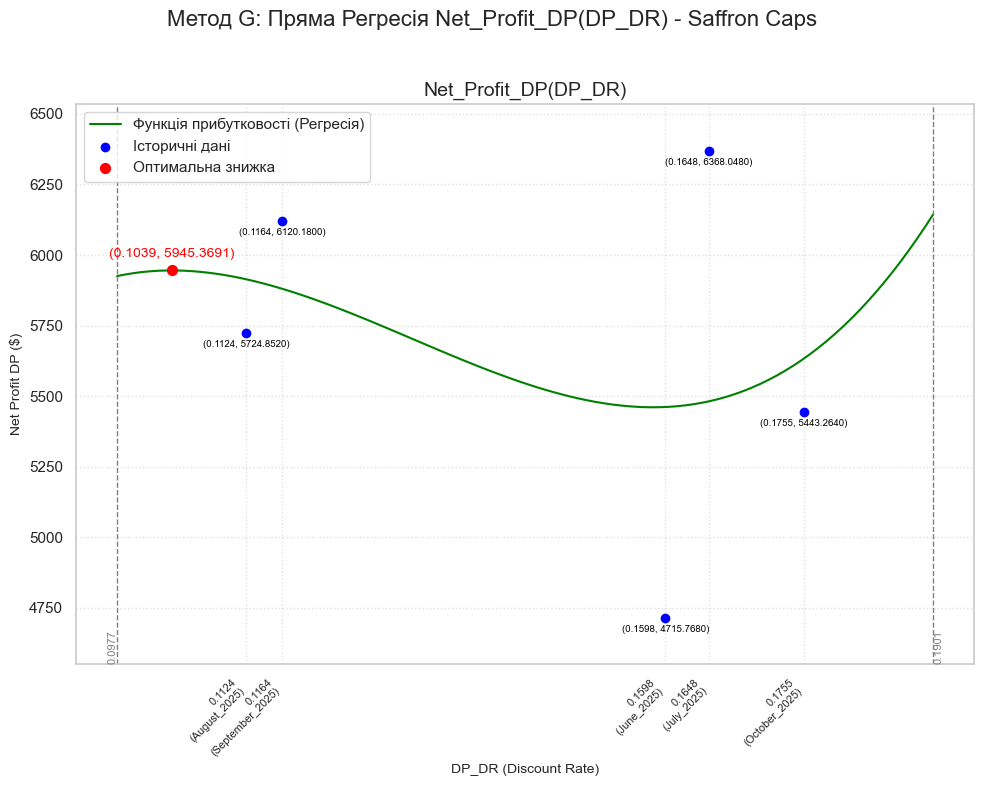

--- 6. СЕРВІСНА ІНФОРМАЦІЯ: РЕЗУЛЬТАТ ОПТИМІЗАЦІЇ ---
Оптимальна координата: (0.1039, 5945.3691)
Рекомендована знижка: 0.1039
Прогнозований профіт: 5945.3691
Похибка методу (MAPE): 0.0809
Похибка методу (RMSE): 542.3769
----------------------------------------------------------------------
--- 7. СЕРВІСНА ІНФОРМАЦІЯ: ЗБЕРЕЖЕННЯ ---
Успішний запис даних в ALL_METHODS_RESULTS:
- Saffron Caps - Method-G-Net_Profit_DP_Reg - DP_DR: 0.1039
- Saffron Caps - Method-G-Net_Profit_DP_Reg - MAPE: 0.0809
----------------------------------------------------------------------


In [10]:
# Встановлення глобальних налаштувань для форматування чисел (4 знаки після коми)
pd.options.display.float_format = '{:.4f}'.format
np.set_printoptions(formatter={'float': '{:.4f}'.format})


# --- 1. ДОПОМІЖНІ ФУНКЦІЇ (ПЕРЕВИКОРИСТАННЯ) ---

def calculate_r_squared(y_true, y_pred):
    """Розрахунок коефіцієнта детермінації R^2."""
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot) if ss_tot != 0 else 0

def format_poly_str(coefs):
    """Форматування коефіцієнтів полінома 3-го порядку у вигляд рядка."""
    power = len(coefs) - 1
    terms = []
    for c in coefs:
        c_fmt = f"{c:.4f}"
        
        if power == 3:
            term = f"{c_fmt}x^3"
        elif power == 2:
            term = f"{c_fmt}x^2"
        elif power == 1:
            term = f"{c_fmt}x"
        elif power == 0:
            term = f"{c_fmt}"
        else:
            term = ""
        
        if c > 0 and terms:
            terms.append("+" + term)
        elif c < 0:
            terms.append(term)
        elif c > 0 and not terms:
             terms.append(term)
        
        power -= 1
    
    return "".join(terms).lstrip('+').replace('+-', ' - ')

def calculate_mape(y_true, y_pred):
    """Розрахунок Середньої абсолютної відсоткової похибки (MAPE).
    Для коректного розрахунку враховуються лише позитивні історичні значення (y_true > 0).
    """
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    non_zero_indices = y_true > 0 
    
    if np.sum(non_zero_indices) == 0:
        return np.nan 

    mape = np.mean(np.abs((y_true[non_zero_indices] - y_pred[non_zero_indices]) / y_true[non_zero_indices]))
    return mape

def calculate_rmse(y_true, y_pred):
    """Розрахунок Кореневої середньоквадратичної похибки (RMSE)."""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

# --- 2. ПІДГОТОВКА ДАНИХ ТА РОЗРАХУНОК КОНСТАНТ ---

metrics_to_use_G = ['Net Profit_DP', 'DP_DR'] # Необхідні дані
df_method_G_temp = df_raw.loc[:, [col for col in metrics_to_use_G if col in df_raw.columns]].T.copy() 

# Перейменування рядків та реіндексація
df_method_G = df_method_G_temp.rename(index={
    'Net Profit_DP': 'Net_Profit_DP', 
    'DP_DR': 'DP_DR'
}).reindex(index=['Net_Profit_DP', 'DP_DR'])


# 2.2. Розрахунок Констант та Меж
dp_dr_series = df_method_G.loc['DP_DR'] # Незалежна змінна для меж
month_count = len(df_method_G.columns)

# Межі для DP_DR (Min/Max +/- StDev)
St_Dev_DP_DR = 0.5 * dp_dr_series.std()
min_DP_DR = dp_dr_series.min()
max_DP_DR = dp_dr_series.max()

lower_bound_dr = max(0.0, min_DP_DR - St_Dev_DP_DR)
upper_bound_dr = max_DP_DR + St_Dev_DP_DR
def_Bound_DP_DR = [lower_bound_dr, upper_bound_dr]


# 2.3. ВИВІД ДАТАСЕТУ ТА СЕРВІСНОЇ ІНФОРМАЦІЇ
print(f"--- 1. ДАТАСЕТ ДЛЯ АНАЛІЗУ ---")
display(df_method_G.style.format('{:.4f}'))
print("-" * 70)

print("--- 2. СЕРВІСНА ІНФОРМАЦІЯ: РОЗРАХУНОК КОНСТАНТ ТА МЕЖ ---")
print(f"month_count: {month_count}")
print(f"St_Dev_DP_DR: {St_Dev_DP_DR:.4f}")
print(f"min_DP_DR: {min_DP_DR:.4f}")
print(f"max_DP_DR: {max_DP_DR:.4f}")
print(f"def_Bound_DP_DR: [{def_Bound_DP_DR[0]:.4f}; {def_Bound_DP_DR[1]:.4f}]")
print("-" * 70)


# --- 3. ПОБУДОВА РЕГРЕСІЇ ---
X = df_method_G.loc['DP_DR'].values # Незалежна змінна - DP_DR
X_month_labels = df_method_G.columns.values
Y_Net_Profit_DP_Actual = df_method_G.loc['Net_Profit_DP'].values # Залежна змінна - Net_Profit_DP (історичні дані)
poly_order = 3 

# 3.1. Net_Profit_DP(DP_DR)
coefs_profit = np.polyfit(X, Y_Net_Profit_DP_Actual, poly_order); poly_profit = np.poly1d(coefs_profit)
r2_profit = calculate_r_squared(Y_Net_Profit_DP_Actual, poly_profit(X)); poly_profit_str = format_poly_str(coefs_profit)
final_profit_func = poly_profit
profit_text = "Net_Profit_DP(DP_DR)"

# 3.2. ВИВІД СЕРВІСНОЇ ІНФОРМАЦІЇ: РЕГРЕСІЯ ТА ФОРМУЛА
print("--- 3. СЕРВІСНА ІНФОРМАЦІЯ: РЕГРЕСІЯ 3-ГО ПОРЯДКУ ---")
print(f"Регресійний поліном {profit_text} = {poly_profit_str}. Детермінація R_2 = {r2_profit:.4f}")
# ОНОВЛЕНО: Формула профітності - тут це сама регресія
print(f"\nФункція прибутковості Net_Profit_DP(DP_DR) = {poly_profit_str}")
print("-" * 70)


# --- 4. ОПТИМІЗАЦІЯ ТА ОЦІНКА ПОХИБКИ ---

# 4.1. Визначення функції прибутковості (МОДЕЛЬ ПРЯМОЇ РЕГРЕСІЇ)
def net_profit_dp_func_G(dp_dr):
    # Функція прибутковості - це сама поліноміальна регресія
    return final_profit_func(dp_dr)

# 4.2. Оцінка похибки (порівняння прогнозу з історичним профітом)
Y_Net_Profit_DP_Predicted = net_profit_dp_func_G(X)
mape_error = calculate_mape(Y_Net_Profit_DP_Actual, Y_Net_Profit_DP_Predicted)
rmse_error = calculate_rmse(Y_Net_Profit_DP_Actual, Y_Net_Profit_DP_Predicted)


# 4.3. Оптимізація
optimization_result_G = minimize_scalar(
    lambda x: -net_profit_dp_func_G(x),
    bounds=def_Bound_DP_DR,
    method='bounded'
)

optimal_dp_dr = optimization_result_G.x
max_net_profit = -optimization_result_G.fun 


# --- 5. ГРАФІКИ ---

X_plot = np.linspace(def_Bound_DP_DR[0], def_Bound_DP_DR[1], 100)
Y_historical_np = Y_Net_Profit_DP_Actual
Y_function_np = net_profit_dp_func_G(X_plot) # МОДЕЛЬ ПРЯМОЇ РЕГРЕСІЇ

# Створення фігури для графіків
fig, ax = plt.subplots(1, 1, figsize=(10, 8))
fig.suptitle(f'Метод G: Пряма Регресія Net_Profit_DP(DP_DR) - {product_name}', fontsize=16)

min_bound, max_bound = def_Bound_DP_DR
x_padding = 0.05 * (max_bound - min_bound) 

# Графік функції прибутковості (яка є регресією)
ax.plot(X_plot, Y_function_np, color='green', label='Функція прибутковості (Регресія)')
# Історичні точки
ax.scatter(X, Y_historical_np, color='blue', marker='o', label='Історичні дані') 
# Точка максимального прибутку
ax.scatter(optimal_dp_dr, max_net_profit, color='red', s=50, zorder=5, label='Оптимальна знижка')

# Підпис оптимальної точки
optimal_coords = (optimal_dp_dr, max_net_profit)
ax.annotate(f'({optimal_dp_dr:.4f}, {max_net_profit:.4f})', 
            optimal_coords, textcoords="offset points", xytext=(0, 10), ha='center', fontsize=10, color='red')

# Підписи історичних точок
for x_val, y_val in zip(X, Y_historical_np):
    ax.annotate(f'({x_val:.4f}, {y_val:.4f})', (x_val, y_val), textcoords="offset points", 
                 xytext=(0, -10), ha='center', fontsize=7, color='black')

# Підпис меж оптимізації
ax.axvline(x=min_bound, color='gray', linestyle='--', linewidth=1)
ax.axvline(x=max_bound, color='gray', linestyle='--', linewidth=1)

# Встановлення меж Y для графіка профіту
y_min_hist = Y_historical_np.min()
y_max_hist = Y_historical_np.max()
y_min_func = Y_function_np.min()
y_max_func = Y_function_np.max()
y_min_plot = min(y_min_hist, y_min_func)
y_max_plot = max(y_max_hist, y_max_func)
y_range_plot = y_max_plot - y_min_plot

ax.set_ylim(y_min_plot - y_range_plot * 0.1, y_max_plot + y_range_plot * 0.1)

# Підписи числових значень меж
y_min_profit, y_max_profit = ax.get_ylim()
y_range_profit = y_max_profit - y_min_profit

ax.text(min_bound, y_min_profit, f'{min_bound:.4f}', rotation=90, va='bottom', ha='right', fontsize=8, color='gray')
ax.text(max_bound, y_min_profit, f'{max_bound:.4f}', rotation=90, va='bottom', ha='left', fontsize=8, color='gray')

# Встановлення міток осі X та меж
ax.set_xticks(X)
ax.set_xticklabels([f'{x:.4f}\n({m})' for x, m in zip(X, X_month_labels)], rotation=45, ha='right', fontsize=8)
ax.set_xlim(min_bound - x_padding, max_bound + x_padding) 

ax.set_title(f'{profit_text}', fontsize=14)
ax.set_xlabel('DP_DR (Discount Rate)', fontsize=10)
ax.set_ylabel('Net Profit DP ($)', fontsize=10)
ax.legend(loc='best')
ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


# --- 6. ФІНАЛЬНИЙ ВИВІД ТА ЗБЕРЕЖЕННЯ ---
print("--- 6. СЕРВІСНА ІНФОРМАЦІЯ: РЕЗУЛЬТАТ ОПТИМІЗАЦІЇ ---")
print(f"Оптимальна координата: ({optimal_dp_dr:.4f}, {max_net_profit:.4f})")
print(f"Рекомендована знижка: {optimal_dp_dr:.4f}")
print(f"Прогнозований профіт: {max_net_profit:.4f}")
# НОВОВВЕДЕННЯ: Додано вивід похибок
print(f"Похибка методу (MAPE): {mape_error:.4f}")
print(f"Похибка методу (RMSE): {rmse_error:.4f}")
print("-" * 70)

# Збереження результату
method_key = "Method-G-Net_Profit_DP_Reg" 
save_success = False

if 'ALL_METHODS_RESULTS' in globals():
    # НОВОВВЕДЕННЯ: Збереження DP_DR та MAPE
    ALL_METHODS_RESULTS[f"{product_name} - {method_key} - DP_DR"] = optimal_dp_dr
    ALL_METHODS_RESULTS[f"{product_name} - {method_key} - MAPE"] = mape_error
    save_success = True
    
print("--- 7. СЕРВІСНА ІНФОРМАЦІЯ: ЗБЕРЕЖЕННЯ ---")
if save_success:
    print(f"Успішний запис даних в ALL_METHODS_RESULTS:")
    print(f"- {product_name} - {method_key} - DP_DR: {optimal_dp_dr:.4f}")
    print(f"- {product_name} - {method_key} - MAPE: {mape_error:.4f}")
else:
    print(f"Помилка: Словник ALL_METHODS_RESULTS не визначено. Будь ласка, визначте його на початку ноутбука (ALL_METHODS_RESULTS = {{}}) для збереження результатів.")
print("-" * 70)